# 1. Importing Libraries

In [7]:
import pandas as pd

# 2. Loading Dataset

In [8]:
bus_stop = pd.read_csv(r"C:\Users\Pradeep Loganathan\Documents\PROJECTS\chennai-bus-stop-audit\data\chennai_bus_stop_audit_2026.csv")

# 3. Exploration

In [9]:
bus_stop.shape

(210, 85)

In [10]:
bus_stop.columns

Index(['start', 'end', 'Date and Time',
       'Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)',
       'Survey Location', '_Survey Location_latitude',
       '_Survey Location_longitude', '_Survey Location_altitude',
       '_Survey Location_precision',
       'If Location field is not working, please enter coordinates from google maps or paste the location URL',
       'Type of Bus Stop', 'Condition of Bus Shelter',
       'How is the bus stop positioned relative to the road?',
       'How is the bus stop positioned relative to the road?/Set back from the road – against a wall, compound, or building edge',
       'How is the bus stop positioned relative to the road?/On the road edge / footpath edge – directly adjacent to traffic',
       'How is the bus stop positioned relative to the road?/The road/footpath is too narrow ',
       'Relationship between Bus Stop and Pedestrians',
       'Is there space behind the bus shelter 

In [11]:
bus_stop.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 85 columns):
 #   Column                                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                                              --------------  -----  
 0   start                                                                                                                                               210 non-null    str    
 1   end                                                                                                                                                 210 non-null    str    
 2   Date and Time                                                                                                                                       210 non-null    str    
 3   Name of the Bus 

In [12]:
# Check missing values
bus_stop.isnull().sum()

start                                                                                                         0
end                                                                                                           0
Date and Time                                                                                                 0
Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)     0
Survey Location                                                                                              56
                                                                                                             ..
source_form                                                                                                   0
latitude                                                                                                      1
longitude                                                                                               

In [13]:
# Find latitude/longitude columns.
location = bus_stop.columns[bus_stop.columns.str.contains('lat|lon', case=False)]
print(location)

Index(['_Survey Location_latitude', '_Survey Location_longitude',
       'How is the bus stop positioned relative to the road?',
       'How is the bus stop positioned relative to the road?/Set back from the road – against a wall, compound, or building edge',
       'How is the bus stop positioned relative to the road?/On the road edge / footpath edge – directly adjacent to traffic',
       'How is the bus stop positioned relative to the road?/The road/footpath is too narrow ',
       'Relationship between Bus Stop and Pedestrians',
       'How far away from the kerb/Bus stop platform does the bus stop?',
       'latitude', 'longitude'],
      dtype='str')


# 4. Understanding Accessiblity Columns

In [14]:
# Total audited stops
total_stops = len(bus_stop)

print("Total audited bus stops:", total_stops)


# ==========================================
# 1. SELECT ACCESSIBILITY COLUMNS
# ==========================================

accessibility_cols = {
    "Space behind shelter": 
        'Is there space behind the bus shelter for pedestrians to walk/wheelchair to move freely?',

    "Space between shelter and road": 
        'Is there space between the bus shelter and the road for pedestrians to walk/wheelchair to move freely?\xa0',

    "Pass without stepping onto road": 
        'Can pedestrians/wheelchair users move past the bus stop on the footpath, without having to step down on the road?\xa0',

    "Footpath from both directions": 
        'Tick all access features present at this bus stop/Footpath available to reach the bus stop from both directions',

    "Footpath free of encroachment": 
        'Tick all access features present at this bus stop/Footpath is walkable and free of encroachment like parking, vendors, utility boxes, garbage, etc',

    "Wheelchair ramp": 
        'Tick all access features present at this bus stop/Ramp for wheelchair users to access the bus stop',

    "Ramp usable": 
        'Tick all access features present at this bus stop/Ramp is in usable condition (not too steep, not broken, nor blocked)',

    "Tactile paving": 
        'Tick all access features present at this bus stop/Tactile paving for visually impaired users',

    "Pedestrian crossing": 
        'Tick all access features present at this bus stop/Pedestrian crossing at/close to the bus stop to cross the road?',

    "High kerb / steps": 
        "Check this box if the bus stop's kerb is higher than 15cms or has steps to access "
}


# 2. COUNT YES / NO FOR EACH ISSUE

for name, col in accessibility_cols.items():

    print("\n" + "=" * 70)
    print(name)

    print(
        bus_stop[col]
        .value_counts(dropna=False)
    )

Total audited bus stops: 210

Space behind shelter
Is there space behind the bus shelter for pedestrians to walk/wheelchair to move freely?
No     157
Yes     53
Name: count, dtype: int64

Space between shelter and road
Is there space between the bus shelter and the road for pedestrians to walk/wheelchair to move freely? 
No     150
Yes     60
Name: count, dtype: int64

Pass without stepping onto road
Can pedestrians/wheelchair users move past the bus stop on the footpath, without having to step down on the road? 
No     155
Yes     55
Name: count, dtype: int64

Footpath from both directions
Tick all access features present at this bus stop/Footpath available to reach the bus stop from both directions
0    107
1    103
Name: count, dtype: int64

Footpath free of encroachment
Tick all access features present at this bus stop/Footpath is walkable and free of encroachment like parking, vendors, utility boxes, garbage, etc
0    144
1     66
Name: count, dtype: int64

Wheelchair ramp
Tick a

In [15]:
# Convert Yes/No columns into 1/0
yes_no_cols = [
    accessibility_cols["Space behind shelter"],
    accessibility_cols["Space between shelter and road"],
    accessibility_cols["Pass without stepping onto road"]
]

for col in yes_no_cols:
    bus_stop[col] = bus_stop[col].map({
        "Yes": 1,
        "No": 0
    })

# Recalculate summary
summary = []

for name, col in accessibility_cols.items():

    counts = bus_stop[col].value_counts()

    yes = counts.get(1, 0)
    no = counts.get(0, 0)

    if yes + no == 0:
        continue

    summary.append({
        "Issue": name,
        "Yes": yes,
        "No": no,
        "Yes %": round(yes / (yes + no) * 100, 1),
        "No %": round(no / (yes + no) * 100, 1)
    })

accessibility_summary = pd.DataFrame(summary)

accessibility_summary

,Issue,Yes,No,Yes %,No %
0,Space behind shelter,53,157,25.2,74.8
1,Space between shelter and road,60,150,28.6,71.4
2,Pass without stepping onto road,55,155,26.2,73.8
3,Footpath from both directions,103,107,49.0,51.0
4,Footpath free of encroachment,66,144,31.4,68.6
5,Wheelchair ramp,32,178,15.2,84.8
6,Ramp usable,20,190,9.5,90.5
7,Tactile paving,10,200,4.8,95.2
8,Pedestrian crossing,54,156,25.7,74.3


### Ramp exists?

In [16]:
ramp = accessibility_cols["Wheelchair ramp"]
ramp_usable = accessibility_cols["Ramp usable"]

print("Wheelchair ramp:")
print(bus_stop[ramp].value_counts())

Wheelchair ramp:
Tick all access features present at this bus stop/Ramp for wheelchair users to access the bus stop
0    178
1     32
Name: count, dtype: int64


In [17]:
ramp_stops = bus_stop[ramp] == 1

print("Stops with ramp:", ramp_stops.sum())

print(
    "Stops with usable ramp among ramp stops:",
    ((bus_stop[ramp] == 1) & (bus_stop[ramp_usable] == 1)).sum()
)

Stops with ramp: 32
Stops with usable ramp among ramp stops: 14


In [18]:
pd.crosstab(
    bus_stop[accessibility_cols['Wheelchair ramp']],
    bus_stop[accessibility_cols["Ramp usable"]],
    margins=True
)


"Tick all access features present at this bus stop/Ramp is in usable condition (not too steep, not broken, nor blocked)",0,1,All
Tick all access features present at this bus stop/Ramp for wheelchair users to access the bus stop,,,
0,172,6,178
1,18,14,32
All,190,20,210


In [19]:
cols = [accessibility_cols['Wheelchair ramp'], accessibility_cols['Ramp usable']]

bus_stop.loc[
    (bus_stop[accessibility_cols['Wheelchair ramp']] == 0) &
    (bus_stop[accessibility_cols['Ramp usable']] == 1),
    ["Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)", *cols]
]

,"Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)",Tick all access features present at this bus stop/Ramp for wheelchair users to access the bus stop,"Tick all access features present at this bus stop/Ramp is in usable condition (not too steep, not broken, nor blocked)"
2,Ambedkar play ground,0,1
18,Moolakadai bus stand,0,1
36,ஆடுத்தொட்டி,0,1
104,Perungudi IGP,0,1
132,Shastri Nagar bus stop,0,1
147,பெல்ஸ் ரோடு,0,1


In [20]:
# Having all accessibility features is a good indicator of practical accessibility. Let's check how many stops have all the features.
conditions = [
    accessibility_cols["Footpath from both directions"],
    accessibility_cols["Footpath free of encroachment"],
    accessibility_cols["Wheelchair ramp"],
    accessibility_cols["Ramp usable"],
    accessibility_cols["Space behind shelter"],
    accessibility_cols["Space between shelter and road"],
    accessibility_cols["Pass without stepping onto road"]
]

accessible = bus_stop[conditions].eq(1).all(axis=1)

print("Practically accessible stops:", accessible.sum())
print("Percentage:", round(accessible.mean() * 100, 1), "%")

Practically accessible stops: 0
Percentage: 0.0 %


# 5.  PEDESTRIAN ENVIRONMENT

In [21]:
cols_37_47 = [
    'Is the bus stop area free of encroachments?',
    'Is there evidence of water-logging or poor drainage around the stop?',
    ' How safe does this bus stop feel, particularly at night?',
    ' Is the bus stop big enough for the number of people who typically wait here?',
    'Does the bus stop have a roof that shelters people from rain?',
    'Is there adequate shade during the day for people waiting?',
    'Is there adequate lighting at the bus stop during the night?',
    'If seated at the bus stop, can you clearly see an approaching bus?',
    'Is the seating provided comfortable?',
    'Is the name of the bus stop clearly displayed?',
    'Is bus route information displayed at the stop?'
]

# Check every column
for i, col in enumerate(cols_37_47, start=37):
    
    print("\n" + "=" * 100)
    print(f"COLUMN {i}")
    print(col)
    print("-" * 100)
    
    counts = bus_stop[col].value_counts(dropna=False)
    percentages = (
        bus_stop[col]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(1)
    )
    
    result = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages
    })
    
    print(result)


COLUMN 37
Is the bus stop area free of encroachments?
----------------------------------------------------------------------------------------------------
                                                    Count  Percentage
Is the bus stop area free of encroachments?                          
Partially encroached – e.g., vendors, parked tw...    100        47.6
 Yes – fully accessible, no obstructions               86        41.0
Heavily encroached – the stop is largely unusab...     24        11.4

COLUMN 38
Is there evidence of water-logging or poor drainage around the stop?
----------------------------------------------------------------------------------------------------
                                                    Count  Percentage
Is there evidence of water-logging or poor drai...                   
No – area appears well-drained                        120        57.1
Yes – signs of standing water, algae, or draina...     57        27.1
Unsure                           

| Main issue                                  | Columns                                    | Verdict                               |
| ------------------------------------------- | ------------------------------------------ | ------------------------------------- |
|  **Pedestrian environment / obstruction** | **37** Encroachments, **38** Waterlogging  | Keep as separate indicators           |
|  **Safety**                              | **39** Night safety, **43** Lighting       | **Strong overlap** — analyze together |
|  **Shelter & waiting capacity**           | **40** Size, **41** Roof, **42** Shade     | Related, but separate indicators      |
|  **Visibility**                          | **44** See approaching bus                 | Keep separately                       |
|  **Seating comfort**                      | **45** Seating                             | Keep separately                       |
|  **Passenger information**                | **46** Stop name, **47** Route information | **Strong overlap** — analyze together |


In [22]:
encroachment_issues = bus_stop[
    bus_stop[col].astype(str).str.contains(
        'Partially|Heavily',
        case=False,
        na=False
    )
]

print(encroachment_issues[
    [
        'Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)',
        col
    ]
])

    Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)  \
2                                 Ambedkar play ground                                                          
10                                Pallikarnai Bus Stop                                                          
16                                  MKB POLICE STATION                                                          
49              Panchayat Union Office Shollinganallur                                                          
97                     Thirunagar (towards Arumbakkam)                                                          
154                                         R R Colony                                                          
168                                           Sakhi JV                                                          
192                                            T.Nagar                                          

In [23]:
col48 = 'Tick all amenities present at this bus stop'

amenities = [
    'Seating / bench',
    'Sufficient seating for the number of people typically waiting',
    'Dustbin / waste bin',
    'Drinking water (tap or dispenser)',
    'Public toilet nearby (within eyesight)',
    'CCTV camera',
    'Digital information boards with real time arrival information and service alerts'
]

amenity_summary = pd.DataFrame({
    'Count': [
        bus_stop[col48].fillna('').str.contains(amenity, regex=False).sum()
        for amenity in amenities
    ]
})

amenity_summary['Percentage'] = (
    amenity_summary['Count'] / len(bus_stop) * 100
).round(1)

amenity_summary.index = amenities

amenity_summary.sort_values('Count', ascending=False)

,Count,Percentage
Seating / bench,167,79.5
Dustbin / waste bin,70,33.3
Sufficient seating for the number of people typically waiting,60,28.6
Digital information boards with real time arrival information and service alerts,37,17.6
Drinking water (tap or dispenser),9,4.3
CCTV camera,5,2.4
Public toilet nearby (within eyesight),3,1.4


In [24]:
col50 = 'Tick all amenities present at this bus stop/Sufficient seating for the number of people typically waiting'

print(bus_stop[col50].value_counts(dropna=False))
print()
print((bus_stop[col50].value_counts(normalize=True, dropna=False) * 100).round(1))

Tick all amenities present at this bus stop/Sufficient seating for the number of people typically waiting
0    150
1     60
Name: count, dtype: int64

Tick all amenities present at this bus stop/Sufficient seating for the number of people typically waiting
0    71.4
1    28.6
Name: proportion, dtype: float64


In [25]:
# ==========================================
# SHELTER & PHYSICAL INFRASTRUCTURE
# ==========================================

shelter_cols = {
    "Waiting capacity": 
        ' Is the bus stop big enough for the number of people who typically wait here?',
    
    "Roof": 
        'Does the bus stop have a roof that shelters people from rain?',
    
    "Shade": 
        'Is there adequate shade during the day for people waiting?'
}

for name, col in shelter_cols.items():

    print("\n" + "=" * 90)
    print(name)
    print(col)
    print("-" * 90)

    counts = bus_stop[col].value_counts(dropna=False)

    percentages = (
        bus_stop[col]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(1)
    )

    result = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages
    })

    print(result)


Waiting capacity
 Is the bus stop big enough for the number of people who typically wait here?
------------------------------------------------------------------------------------------
                                                    Count  Percentage
 Is the bus stop big enough for the number of p...                   
Yes – adequate space for passengers                    96        45.7
 No – overcrowded or high number of people stan...     73        34.8
NaN                                                    31        14.8
Unsure                                                 10         4.8

Roof
Does the bus stop have a roof that shelters people from rain?
------------------------------------------------------------------------------------------
                                                    Count  Percentage
Does the bus stop have a roof that shelters peo...                   
Yes – roof is intact and effective                     95        45.2
Yes – but the roof is in

In [26]:
waiting_col = 'Is the bus stop big enough for the number of people who typically wait here?'

In [27]:
# ==========================================
# SHELTER ANALYSIS — CLEANING
# ==========================================

waiting_col = ' Is the bus stop big enough for the number of people who typically wait here?'
roof_col = 'Does the bus stop have a roof that shelters people from rain?'
shade_col = 'Is there adequate shade during the day for people waiting?'

# Remove accidental leading/trailing spaces from responses
for col in [waiting_col, roof_col, shade_col]:
    bus_stop[col] = bus_stop[col].astype('string').str.strip()

print("Waiting capacity:")
print(bus_stop[waiting_col].value_counts(dropna=False))

print("\nRoof:")
print(bus_stop[roof_col].value_counts(dropna=False))

print("\nShade:")
print(bus_stop[shade_col].value_counts(dropna=False))

Waiting capacity:
 Is the bus stop big enough for the number of people who typically wait here?
Yes – adequate space for passengers                               96
No – overcrowded or high number of people standing on the road    73
<NA>                                                              31
Unsure                                                            10
Name: count, dtype: Int64

Roof:
Does the bus stop have a roof that shelters people from rain?
Yes – roof is intact and effective                                                   95
Yes – but the roof is inadequate (too tall, too small, gaps, or partial coverage)    62
<NA>                                                                                 31
No – The roof is too damaged or broken to provide shelter                            22
Name: count, dtype: Int64

Shade:
Is there adequate shade during the day for people waiting?
Partial – some shade but insufficient            71
Yes – sufficient shade from the bus 

In [28]:
print(bus_stop.loc[
    bus_stop[waiting_col].notna(),
    waiting_col
].unique())

print("\nROOF:")
print(bus_stop.loc[
    bus_stop[roof_col].notna(),
    roof_col
].unique())

print("\nSHADE:")
print(bus_stop.loc[
    bus_stop[shade_col].notna(),
    shade_col
].unique())

<StringArray>
[                                                        'Unsure',
                            'Yes – adequate space for passengers',
 'No – overcrowded or high number of people standing on the road']
Length: 3, dtype: string

ROOF:
<StringArray>
['Yes – but the roof is inadequate (too tall, too small, gaps, or partial coverage)',
                                                'Yes – roof is intact and effective',
                         'No – The roof is too damaged or broken to provide shelter']
Length: 3, dtype: string

SHADE:
<StringArray>
[        'Partial – some shade but insufficient',
                      'No – exposed to full sun',
 'Yes - sufficient shade from surrounding trees',
         'Yes - from both bus shelter AND trees',
   'Yes – sufficient shade from the bus shelter']
Length: 5, dtype: string


In [29]:
# ==========================================
# SHELTER PROBLEM INDICATORS
# ==========================================

bus_stop['waiting_capacity_problem'] = bus_stop[waiting_col].isin([
    'No – overcrowded or high number of people standing'
])

bus_stop['roof_problem'] = bus_stop[roof_col].isin([
    'Yes – but the roof is inadequate (too tall, too narrow, etc.)',
    'No – The roof is too damaged or broken to provide shelter'
])

bus_stop['shade_problem'] = bus_stop[shade_col].isin([
    'Partial – some shade but insufficient',
    'No – exposed to full sun'
])

print("Waiting capacity problems:", bus_stop['waiting_capacity_problem'].sum())
print("Roof problems:", bus_stop['roof_problem'].sum())
print("Shade problems:", bus_stop['shade_problem'].sum())

Waiting capacity problems: 0
Roof problems: 22
Shade problems: 101


In [30]:
# ==========================================
# SHELTER PROBLEM SCORE
# ==========================================

bus_stop['shelter_problem_score'] = (
    bus_stop['waiting_capacity_problem'].astype(int)
    + bus_stop['roof_problem'].astype(int)
    + bus_stop['shade_problem'].astype(int)
)

print(
    bus_stop['shelter_problem_score']
    .value_counts()
    .sort_index()
)

shelter_problem_score
0    104
1     89
2     17
Name: count, dtype: int64


In [31]:
shelter_score_summary = (
    bus_stop['shelter_problem_score']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(1)
)

print(shelter_score_summary)

shelter_problem_score
0    49.5
1    42.4
2     8.1
Name: proportion, dtype: float64


In [32]:
bus_stop_name_col = 'Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)'

critical_shelter_stops = bus_stop[
    bus_stop['shelter_problem_score'] == 3
].sort_values(
    'shelter_problem_score',
    ascending=False
)

print("Critical shelter stops:", len(critical_shelter_stops))

critical_shelter_stops[
    [
        bus_stop_name_col,
        waiting_col,
        roof_col,
        shade_col,
        'shelter_problem_score'
    ]
]

Critical shelter stops: 0


,"Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)",Is the bus stop big enough for the number of people who typically wait here?,Does the bus stop have a roof that shelters people from rain?,Is there adequate shade during the day for people waiting?,shelter_problem_score


In [33]:
high_priority_shelter = bus_stop[
    bus_stop['shelter_problem_score'] >= 2
].sort_values(
    'shelter_problem_score',
    ascending=False
)

print("High-priority shelter stops:", len(high_priority_shelter))

high_priority_shelter[
    [
        bus_stop_name_col,
        waiting_col,
        roof_col,
        shade_col,
        'shelter_problem_score'
    ]
]

High-priority shelter stops: 17


,"Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)",Is the bus stop big enough for the number of people who typically wait here?,Does the bus stop have a roof that shelters people from rain?,Is there adequate shade during the day for people waiting?,shelter_problem_score
14,M.P. தேவதாஸ் உயர்நிலைப்பள்ளி,Yes – adequate space for passengers,No – The roof is too damaged or broken to prov...,Partial – some shade but insufficient,2
16,MKB POLICE STATION,No – overcrowded or high number of people stan...,No – The roof is too damaged or broken to prov...,Partial – some shade but insufficient,2
25,Brindha theater,No – overcrowded or high number of people stan...,No – The roof is too damaged or broken to prov...,Partial – some shade but insufficient,2
26,Brindha theatre moolakadai,No – overcrowded or high number of people stan...,No – The roof is too damaged or broken to prov...,Partial – some shade but insufficient,2
30,Vadivudaiamman Kovil Perambur,Yes – adequate space for passengers,No – The roof is too damaged or broken to prov...,Partial – some shade but insufficient,2
33,Fire station Bus stand Vysarpadi,No – overcrowded or high number of people stan...,No – The roof is too damaged or broken to prov...,Partial – some shade but insufficient,2
36,ஆடுத்தொட்டி,No – overcrowded or high number of people stan...,No – The roof is too damaged or broken to prov...,Partial – some shade but insufficient,2
38,கணேசபுரம்,No – overcrowded or high number of people stan...,No – The roof is too damaged or broken to prov...,Partial – some shade but insufficient,2
63,Massodhi,No – overcrowded or high number of people stan...,No – The roof is too damaged or broken to prov...,Partial – some shade but insufficient,2
133,Ottiyambakkam Main Road towards Medavakkam,Unsure,No – The roof is too damaged or broken to prov...,Partial – some shade but insufficient,2


In [34]:
shelter_priority_table = high_priority_shelter[
    [
        bus_stop_name_col,
        waiting_col,
        roof_col,
        shade_col,
        'shelter_problem_score'
    ]
].copy()

shelter_priority_table = shelter_priority_table.rename(columns={
    bus_stop_name_col: 'Bus Stop',
    waiting_col: 'Waiting Capacity',
    roof_col: 'Roof',
    shade_col: 'Shade',
    'shelter_problem_score': 'Shelter Problem Score'
})

shelter_priority_table

,Bus Stop,Waiting Capacity,Roof,Shade,Shelter Problem Score
14,M.P. தேவதாஸ் உயர்நிலைப்பள்ளி,Yes – adequate space for passengers,No – The roof is too damaged or broken to prov...,Partial – some shade but insufficient,2
16,MKB POLICE STATION,No – overcrowded or high number of people stan...,No – The roof is too damaged or broken to prov...,Partial – some shade but insufficient,2
25,Brindha theater,No – overcrowded or high number of people stan...,No – The roof is too damaged or broken to prov...,Partial – some shade but insufficient,2
26,Brindha theatre moolakadai,No – overcrowded or high number of people stan...,No – The roof is too damaged or broken to prov...,Partial – some shade but insufficient,2
30,Vadivudaiamman Kovil Perambur,Yes – adequate space for passengers,No – The roof is too damaged or broken to prov...,Partial – some shade but insufficient,2
33,Fire station Bus stand Vysarpadi,No – overcrowded or high number of people stan...,No – The roof is too damaged or broken to prov...,Partial – some shade but insufficient,2
36,ஆடுத்தொட்டி,No – overcrowded or high number of people stan...,No – The roof is too damaged or broken to prov...,Partial – some shade but insufficient,2
38,கணேசபுரம்,No – overcrowded or high number of people stan...,No – The roof is too damaged or broken to prov...,Partial – some shade but insufficient,2
63,Massodhi,No – overcrowded or high number of people stan...,No – The roof is too damaged or broken to prov...,Partial – some shade but insufficient,2
133,Ottiyambakkam Main Road towards Medavakkam,Unsure,No – The roof is too damaged or broken to prov...,Partial – some shade but insufficient,2


In [35]:
# ==========================================
# SHELTER PROBLEM COMBINATIONS
# ==========================================

shelter_combinations = (
    bus_stop.groupby([
        'waiting_capacity_problem',
        'roof_problem',
        'shade_problem'
    ])
    .size()
    .reset_index(name='Stops')
    .sort_values('Stops', ascending=False)
)

shelter_combinations

,waiting_capacity_problem,roof_problem,shade_problem,Stops
0,False,False,False,104
1,False,False,True,84
3,False,True,True,17
2,False,True,False,5


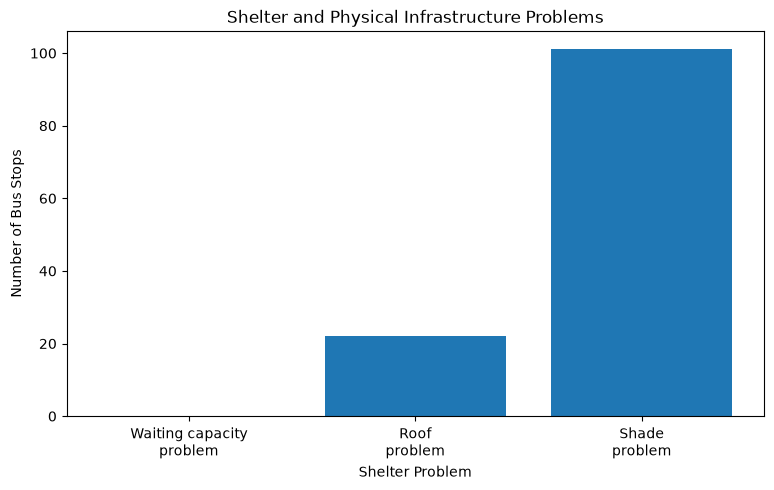

In [36]:
import matplotlib.pyplot as plt

shelter_problem_counts = {
    'Waiting capacity\nproblem': bus_stop['waiting_capacity_problem'].sum(),
    'Roof\nproblem': bus_stop['roof_problem'].sum(),
    'Shade\nproblem': bus_stop['shade_problem'].sum()
}

plt.figure(figsize=(9, 5))

plt.bar(
    shelter_problem_counts.keys(),
    shelter_problem_counts.values()
)

plt.ylabel("Number of Bus Stops")
plt.xlabel("Shelter Problem")
plt.title("Shelter and Physical Infrastructure Problems")

plt.show()

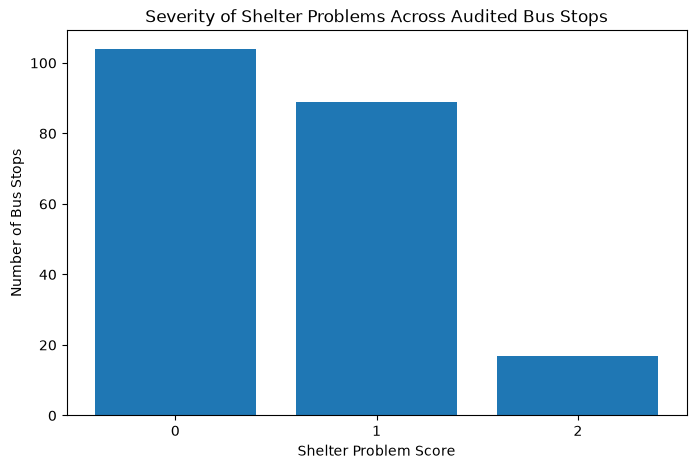

In [37]:
score_counts = (
    bus_stop['shelter_problem_score']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    score_counts.index.astype(str),
    score_counts.values
)

plt.xlabel("Shelter Problem Score")
plt.ylabel("Number of Bus Stops")
plt.title("Severity of Shelter Problems Across Audited Bus Stops")

plt.show()

In [38]:
print("========== SHELTER FINDINGS ==========")

print(
    "Waiting capacity problems:",
    bus_stop['waiting_capacity_problem'].sum()
)

print(
    "Roof problems:",
    bus_stop['roof_problem'].sum()
)

print(
    "Shade problems:",
    bus_stop['shade_problem'].sum()
)

print(
    "Stops with 2+ shelter problems:",
    (bus_stop['shelter_problem_score'] >= 2).sum()
)

print(
    "Stops with all 3 shelter problems:",
    (bus_stop['shelter_problem_score'] == 3).sum()
)

========== SHELTER FINDINGS ==========
Waiting capacity problems: 0
Roof problems: 22
Shade problems: 101
Stops with 2+ shelter problems: 17
Stops with all 3 shelter problems: 0


In [39]:
def problem_percentage(col, problem_col):
    valid = bus_stop[col].notna()
    return round(
        bus_stop.loc[valid, problem_col].mean() * 100,
        1
    )

print(
    "Waiting capacity problem %:",
    problem_percentage(waiting_col, 'waiting_capacity_problem')
)

print(
    "Roof problem %:",
    problem_percentage(roof_col, 'roof_problem')
)

print(
    "Shade problem %:",
    problem_percentage(shade_col, 'shade_problem')
)

Waiting capacity problem %: 0.0
Roof problem %: 12.3
Shade problem %: 48.1


## Shelter & Physical Infrastructure

Waiting capacity distribution
Roof condition distribution
Shade distribution
Waiting-capacity problem indicator
Roof problem indicator
Shade problem indicator
Shelter Problem Score
Critical stops
High-priority stops
Problem combinations
Two visualizations
Final project finding

done!

In [40]:
# ==========================================
# SAFETY & SECURITY
# ==========================================

safety_col = ' How safe does this bus stop feel, particularly at night?'
lighting_col = 'Is there adequate lighting at the bus stop during the night?'

# Clean response text
for col in [safety_col, lighting_col]:
    bus_stop[col] = bus_stop[col].astype('string').str.strip()

print("NIGHT SAFETY")
print(bus_stop[safety_col].value_counts(dropna=False))

print("\nLIGHTING")
print(bus_stop[lighting_col].value_counts(dropna=False))

NIGHT SAFETY
 How safe does this bus stop feel, particularly at night?
Safe – well-lit, visible, and active surroundings                           85
Somewhat safe – some concerns (e.g., poor visibility, isolated location)    73
Unsafe – poorly lit, isolated, or has a history of feeling threatening      35
Unable to assess (audit done only in daytime)                               17
Name: count, dtype: Int64

LIGHTING
Is there adequate lighting at the bus stop during the night?
Yes – lit by nearby street lights, shop fronts, or advertisement boards    66
Yes – the bus shelter itself has a working light                           42
No – inadequate or no lighting at all                                      37
Unsure / Not observed                                                      33
Partially – some light but insufficient                                    32
Name: count, dtype: Int64


In [41]:
print("========== NIGHT SAFETY ==========")

night_safety_summary = pd.DataFrame({
    'Count': bus_stop[safety_col].value_counts(dropna=False),
    'Percentage': (
        bus_stop[safety_col]
        .value_counts(normalize=True, dropna=False)
        * 100
    ).round(1)
})

night_safety_summary

========== NIGHT SAFETY ==========


,Count,Percentage
"How safe does this bus stop feel, particularly at night?",,
"Safe – well-lit, visible, and active surroundings",85,40.5
"Somewhat safe – some concerns (e.g., poor visibility, isolated location)",73,34.8
"Unsafe – poorly lit, isolated, or has a history of feeling threatening",35,16.7
Unable to assess (audit done only in daytime),17,8.1


In [42]:
print("========== LIGHTING ==========")

lighting_summary = pd.DataFrame({
    'Count': bus_stop[lighting_col].value_counts(dropna=False),
    'Percentage': (
        bus_stop[lighting_col]
        .value_counts(normalize=True, dropna=False)
        * 100
    ).round(1)
})

lighting_summary

========== LIGHTING ==========


,Count,Percentage
Is there adequate lighting at the bus stop during the night?,,
"Yes – lit by nearby street lights, shop fronts, or advertisement boards",66,31.4
Yes – the bus shelter itself has a working light,42,20.0
No – inadequate or no lighting at all,37,17.6
Unsure / Not observed,33,15.7
Partially – some light but insufficient,32,15.2


In [43]:
print("Night safety categories:")
print(bus_stop[safety_col].dropna().unique())

print("\nLighting categories:")
print(bus_stop[lighting_col].dropna().unique())

Night safety categories:
<StringArray>
[                           'Unable to assess (audit done only in daytime)',
                        'Safe – well-lit, visible, and active surroundings',
 'Somewhat safe – some concerns (e.g., poor visibility, isolated location)',
   'Unsafe – poorly lit, isolated, or has a history of feeling threatening']
Length: 4, dtype: string

Lighting categories:
<StringArray>
[                                                  'Unsure / Not observed',
 'Yes – lit by nearby street lights, shop fronts, or advertisement boards',
                                 'Partially – some light but insufficient',
                                   'No – inadequate or no lighting at all',
                        'Yes – the bus shelter itself has a working light']
Length: 5, dtype: string


In [44]:
# ==========================================
# SAFETY PROBLEM SCORE
# ==========================================

bus_stop['night_safety_problem'] = bus_stop[safety_col].isin([
    'No – feels unsafe',
    'Yes – feels unsafe'
])
bus_stop['lighting_problem'] = bus_stop[lighting_col].isin([
    'No',
    'Yes – insufficient'
])

bus_stop['safety_problem_score'] = (
    bus_stop['night_safety_problem'].astype(int)
    + bus_stop['lighting_problem'].astype(int)
)

print(
    bus_stop['safety_problem_score']
    .value_counts()
    .sort_index()
)

safety_problem_score
0    210
Name: count, dtype: int64


In [45]:
critical_safety_stops = bus_stop[
    bus_stop['safety_problem_score'] == 2
].copy()

print(
    "Stops with both night-safety and lighting problems:",
    len(critical_safety_stops)
)

critical_safety_stops[
    [
        bus_stop_name_col,
        safety_col,
        lighting_col,
        'safety_problem_score'
    ]
]

Stops with both night-safety and lighting problems: 0


,"Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)","How safe does this bus stop feel, particularly at night?",Is there adequate lighting at the bus stop during the night?,safety_problem_score


In [46]:
high_priority_safety = bus_stop[
    bus_stop['safety_problem_score'] >= 1
].copy()

print(
    "Stops with at least one safety problem:",
    len(high_priority_safety)
)

high_priority_safety[
    [
        bus_stop_name_col,
        safety_col,
        lighting_col,
        'safety_problem_score'
    ]
].sort_values(
    'safety_problem_score',
    ascending=False
)

Stops with at least one safety problem: 0


,"Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)","How safe does this bus stop feel, particularly at night?",Is there adequate lighting at the bus stop during the night?,safety_problem_score


In [47]:
safety_combinations = (
    bus_stop.groupby([
        'night_safety_problem',
        'lighting_problem'
    ])
    .size()
    .reset_index(name='Stops')
    .sort_values('Stops', ascending=False)
)

safety_combinations

,night_safety_problem,lighting_problem,Stops
0,False,False,210


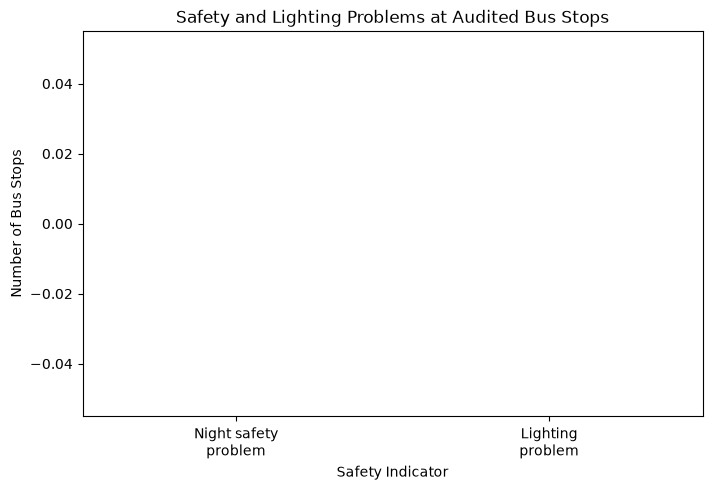

In [48]:
import matplotlib.pyplot as plt

safety_problem_counts = {
    'Night safety\nproblem': bus_stop['night_safety_problem'].sum(),
    'Lighting\nproblem': bus_stop['lighting_problem'].sum()
}

plt.figure(figsize=(8, 5))

plt.bar(
    safety_problem_counts.keys(),
    safety_problem_counts.values()
)

plt.xlabel("Safety Indicator")
plt.ylabel("Number of Bus Stops")
plt.title("Safety and Lighting Problems at Audited Bus Stops")

plt.show()

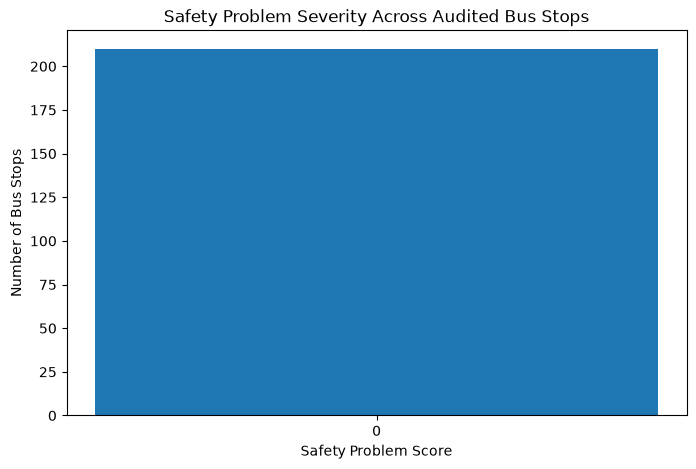

In [49]:
score_counts = (
    bus_stop['safety_problem_score']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    score_counts.index.astype(str),
    score_counts.values
)

plt.xlabel("Safety Problem Score")
plt.ylabel("Number of Bus Stops")
plt.title("Safety Problem Severity Across Audited Bus Stops")

plt.show()

In [50]:
cctv_col = 'Tick all amenities present at this bus stop/CCTV camera'

print("========== CCTV ==========")

cctv_summary = pd.DataFrame({
    'Count': bus_stop[cctv_col].value_counts(dropna=False),
    'Percentage': (
        bus_stop[cctv_col]
        .value_counts(normalize=True, dropna=False)
        * 100
    ).round(1)
})

cctv_summary

========== CCTV ==========


,Count,Percentage
Tick all amenities present at this bus stop/CCTV camera,,
0,205,97.6
1,5,2.4


In [51]:
print(
    "Stops with CCTV:",
    (bus_stop[cctv_col] == 1).sum()
)

Stops with CCTV: 5


In [52]:
print(bus_stop[cctv_col].unique())

[0 1]


In [53]:
# ==========================================
# 7. PASSENGER COMFORT
# ==========================================

comfort_cols = {
    "Seating available":
        'Tick all amenities present at this bus stop/Seating / bench',

    "Sufficient seating":
        'Tick all amenities present at this bus stop/Sufficient seating for the number of people typically waiting',

    "Seating comfort":
        'Is the seating provided comfortable?',

    "Bus visibility":
        'If seated at the bus stop, can you clearly see an approaching bus?'
}

for name, col in comfort_cols.items():

    print("\n" + "=" * 90)
    print(name)
    print(col)
    print("-" * 90)

    counts = bus_stop[col].value_counts(dropna=False)

    percentages = (
        bus_stop[col]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(1)
    )

    result = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages
    })

    print(result)


Seating available
Tick all amenities present at this bus stop/Seating / bench
------------------------------------------------------------------------------------------
                                                    Count  Percentage
Tick all amenities present at this bus stop/Sea...                   
1                                                     167        79.5
0                                                      43        20.5

Sufficient seating
Tick all amenities present at this bus stop/Sufficient seating for the number of people typically waiting
------------------------------------------------------------------------------------------
                                                    Count  Percentage
Tick all amenities present at this bus stop/Suf...                   
0                                                     150        71.4
1                                                      60        28.6

Seating comfort
Is the seating provided comfortable?

In [54]:
seating_col = comfort_cols["Seating available"]
sufficient_seating_col = comfort_cols["Sufficient seating"]
comfort_col = comfort_cols["Seating comfort"]

print("Seating values:")
print(bus_stop[seating_col].value_counts(dropna=False))

print("\nStops with seating:",
      (bus_stop[seating_col] == 1).sum())

print("Stops without seating:",
      (bus_stop[seating_col] == 0).sum())

Seating values:
Tick all amenities present at this bus stop/Seating / bench
1    167
0     43
Name: count, dtype: int64

Stops with seating: 167
Stops without seating: 43


In [55]:
print(
    bus_stop[sufficient_seating_col]
    .value_counts(dropna=False)
)

Tick all amenities present at this bus stop/Sufficient seating for the number of people typically waiting
0    150
1     60
Name: count, dtype: int64


In [56]:
print(
    bus_stop[comfort_col]
    .value_counts(dropna=False)
)

Is the seating provided comfortable?
Yes - the seating is of the right height, width, and depth to sit comfortably while waiting for the bus    120
No - the seating is too small to sit comfortably                                                            42
NaN                                                                                                         31
No - the seating is too high                                                                                 7
No - poor back support / posture                                                                             5
No seating available                                                                                         3
No - the seating is too slippery                                                                             2
Name: count, dtype: int64


In [57]:
comfort_problem_stops = bus_stop[
    (
        bus_stop[sufficient_seating_col]
        .astype(str)
        .str.contains("No", case=False, na=False)
    )
    |
    (
        bus_stop[comfort_col]
        .astype(str)
        .str.contains("No|uncomfortable|poor", case=False, na=False)
    )
]

print("Passenger comfort problem stops:",
      len(comfort_problem_stops))

comfort_problem_stops[
    [
        'Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)',
        seating_col,
        sufficient_seating_col,
        comfort_col
    ]
]

Passenger comfort problem stops: 59


,"Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)",Tick all amenities present at this bus stop/Seating / bench,Tick all amenities present at this bus stop/Sufficient seating for the number of people typically waiting,Is the seating provided comfortable?
0,KAMARAJAR SALAI BUS STOP,0,0,No seating available
2,Ambedkar play ground,1,1,No - poor back support / posture
3,[surveyor name removed],1,0,No - the seating is too small to sit comfortably
4,[surveyor name removed],0,1,No - the seating is too small to sit comfortably
15,MKB Nagar,1,0,No - the seating is too small to sit comfortably
16,MKB POLICE STATION,1,0,No - the seating is too small to sit comfortably
17,Erkenchery toll gate,1,1,No - the seating is too small to sit comfortably
18,Moolakadai bus stand,0,0,No - the seating is too small to sit comfortably
19,Moolakadai bus stand,1,0,No - the seating is too slippery
20,Moolakadai bus stand 2,1,0,No - the seating is too high


In [58]:
# ==========================================
# PASSENGER COMFORT SUMMARY
# ==========================================

seating_col = comfort_cols["Seating available"]
sufficient_seating_col = comfort_cols["Sufficient seating"]
comfort_col = comfort_cols["Seating comfort"]

# Check data types first
print("DATA TYPES")
print(bus_stop[[seating_col, sufficient_seating_col, comfort_col]].dtypes)


# Seating available
seating_count = (bus_stop[seating_col] == 1).sum()

# Sufficient seating
sufficient_count = (bus_stop[sufficient_seating_col] == 1).sum()

# Comfortable seating
comfortable_count = (bus_stop[comfort_col] == 1).sum()


comfort_summary = pd.DataFrame({
    "Indicator": [
        "Seating available",
        "Sufficient seating",
        "Comfortable seating"
    ],
    "Count": [
        seating_count,
        sufficient_count,
        comfortable_count
    ]
})

comfort_summary["Percentage"] = (
    comfort_summary["Count"] / len(bus_stop) * 100
).round(1)

comfort_summary

DATA TYPES
Tick all amenities present at this bus stop/Seating / bench                                                  int64
Tick all amenities present at this bus stop/Sufficient seating for the number of people typically waiting    int64
Is the seating provided comfortable?                                                                           str
dtype: object


,Indicator,Count,Percentage
0,Seating available,167,79.5
1,Sufficient seating,60,28.6
2,Comfortable seating,0,0.0


In [59]:
print(bus_stop[seating_col].value_counts(dropna=False))
print(bus_stop[sufficient_seating_col].value_counts(dropna=False))
print(bus_stop[comfort_col].value_counts(dropna=False))

Tick all amenities present at this bus stop/Seating / bench
1    167
0     43
Name: count, dtype: int64
Tick all amenities present at this bus stop/Sufficient seating for the number of people typically waiting
0    150
1     60
Name: count, dtype: int64
Is the seating provided comfortable?
Yes - the seating is of the right height, width, and depth to sit comfortably while waiting for the bus    120
No - the seating is too small to sit comfortably                                                            42
NaN                                                                                                         31
No - the seating is too high                                                                                 7
No - poor back support / posture                                                                             5
No seating available                                                                                         3
No - the seating is too slippery           

DATA TYPES
Tick all amenities present at this bus stop/Seating / bench                                                  int64
Tick all amenities present at this bus stop/Sufficient seating for the number of people typically waiting    int64
Is the seating provided comfortable?                                                                           str
If seated at the bus stop, can you clearly see an approaching bus?                                             str
dtype: object
PASSENGER COMFORT — SEATING
            Indicator  Count  Percentage
0   Seating available    167        79.5
1  Sufficient seating     60        28.6

SEATING COMFORT
                                                    Count  Percentage
Is the seating provided comfortable?                                 
Yes - the seating is of the right height, width...    120        57.1
No - the seating is too small to sit comfortably       42        20.0
NaN                                                    31        14

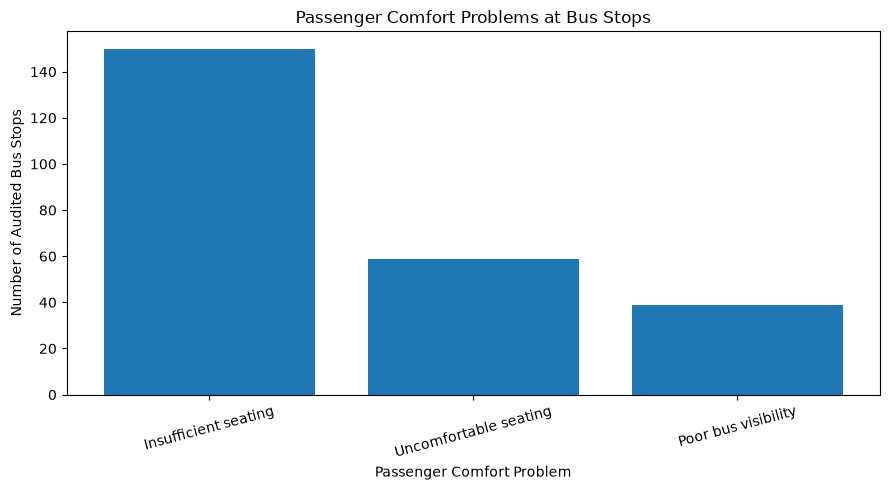

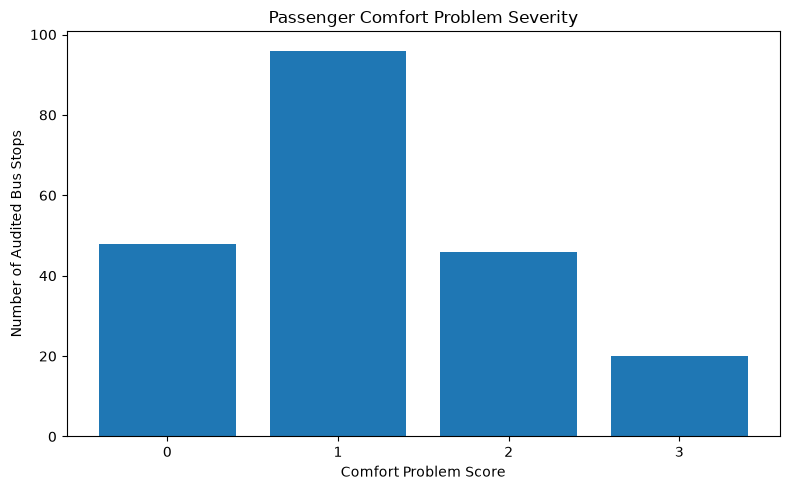


PASSENGER COMFORT — KEY FINDINGS
Insufficient seating: 150 stops (71.4%)
Uncomfortable seating: 59 stops (28.1%)
Poor bus visibility: 39 stops (18.6%)

Stops with 2+ comfort problems: 66 (31.4%)
Stops with all 3 comfort problems: 20 (9.5%)


In [60]:
# ============================================================
# 5. PASSENGER COMFORT — FINAL ANALYSIS
# ============================================================

seating_col = comfort_cols["Seating available"]
sufficient_seating_col = comfort_cols["Sufficient seating"]
comfort_col = comfort_cols["Seating comfort"]
visibility_col = comfort_cols["Bus visibility"]

# ------------------------------------------------------------
# 5.1 CHECK DATA TYPES
# ------------------------------------------------------------

print("DATA TYPES")
print(
    bus_stop[
        [seating_col, sufficient_seating_col, comfort_col, visibility_col]
    ].dtypes
)


# ------------------------------------------------------------
# 5.2 STANDARDIZE NUMERIC BINARY COLUMNS
# ------------------------------------------------------------

# Seating availability and sufficient seating are amenity
# checkbox fields and should be treated as 0/1.

for col in [seating_col, sufficient_seating_col]:
    bus_stop[col] = pd.to_numeric(
        bus_stop[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# 5.3 BASIC COMFORT INDICATORS
# ------------------------------------------------------------

comfort_summary = pd.DataFrame({
    "Indicator": [
        "Seating available",
        "Sufficient seating"
    ],
    "Count": [
        bus_stop[seating_col].eq(1).sum(),
        bus_stop[sufficient_seating_col].eq(1).sum()
    ]
})

comfort_summary["Percentage"] = (
    comfort_summary["Count"] / len(bus_stop) * 100
).round(1)

print("=" * 80)
print("PASSENGER COMFORT — SEATING")
print("=" * 80)

print(comfort_summary)


# ------------------------------------------------------------
# 5.4 SEATING COMFORT DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SEATING COMFORT")
print("=" * 80)

seating_comfort_summary = pd.DataFrame({
    "Count": bus_stop[comfort_col].value_counts(dropna=False),
    "Percentage": (
        bus_stop[comfort_col]
        .value_counts(normalize=True, dropna=False)
        * 100
    ).round(1)
})

print(seating_comfort_summary)


# ------------------------------------------------------------
# 5.5 BUS VISIBILITY DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("BUS VISIBILITY")
print("=" * 80)

visibility_summary = pd.DataFrame({
    "Count": bus_stop[visibility_col].value_counts(dropna=False),
    "Percentage": (
        bus_stop[visibility_col]
        .value_counts(normalize=True, dropna=False)
        * 100
    ).round(1)
})

print(visibility_summary)


# ------------------------------------------------------------
# 5.6 CREATE COMFORT PROBLEM INDICATORS
# ------------------------------------------------------------

# No sufficient seating
bus_stop["insufficient_seating_problem"] = (
    bus_stop[sufficient_seating_col].eq(0)
)

# Uncomfortable seating
bus_stop["uncomfortable_seating_problem"] = (
    bus_stop[comfort_col]
    .astype("string")
    .str.lower()
    .str.contains(
        r"no|uncomfortable|poor",
        regex=True,
        na=False
    )
)

# Poor visibility of approaching bus
bus_stop["bus_visibility_problem"] = (
    bus_stop[visibility_col]
    .astype("string")
    .str.lower()
    .str.contains(
        r"no|cannot|can't|poor",
        regex=True,
        na=False
    )
)


# ------------------------------------------------------------
# 5.7 COMFORT PROBLEM SUMMARY
# ------------------------------------------------------------

comfort_problem_summary = pd.DataFrame({
    "Problem": [
        "Insufficient seating",
        "Uncomfortable seating",
        "Poor bus visibility"
    ],
    "Stops": [
        bus_stop["insufficient_seating_problem"].sum(),
        bus_stop["uncomfortable_seating_problem"].sum(),
        bus_stop["bus_visibility_problem"].sum()
    ]
})

comfort_problem_summary["Percentage"] = (
    comfort_problem_summary["Stops"]
    / len(bus_stop)
    * 100
).round(1)

print("\n" + "=" * 80)
print("PASSENGER COMFORT — PROBLEMS")
print("=" * 80)

print(comfort_problem_summary)


# ------------------------------------------------------------
# 5.8 COMFORT PROBLEM SCORE
# ------------------------------------------------------------

bus_stop["comfort_problem_score"] = (
    bus_stop["insufficient_seating_problem"].astype(int)
    + bus_stop["uncomfortable_seating_problem"].astype(int)
    + bus_stop["bus_visibility_problem"].astype(int)
)

print("\n" + "=" * 80)
print("COMFORT PROBLEM SCORE")
print("=" * 80)

print(
    bus_stop["comfort_problem_score"]
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 5.9 HIGH-PRIORITY COMFORT STOPS
# ------------------------------------------------------------

comfort_priority_stops = bus_stop[
    bus_stop["comfort_problem_score"] >= 2
].sort_values(
    "comfort_problem_score",
    ascending=False
)

print("\nHigh-priority comfort stops:",
      len(comfort_priority_stops))

comfort_priority_stops[
    [
        bus_stop_name_col,
        seating_col,
        sufficient_seating_col,
        comfort_col,
        visibility_col,
        "comfort_problem_score"
    ]
]


# ------------------------------------------------------------
# 5.10 CRITICAL COMFORT STOPS
# ------------------------------------------------------------

critical_comfort_stops = bus_stop[
    bus_stop["comfort_problem_score"] == 3
]

print("\nCritical comfort stops:",
      len(critical_comfort_stops))

critical_comfort_stops[
    [
        bus_stop_name_col,
        seating_col,
        sufficient_seating_col,
        comfort_col,
        visibility_col,
        "comfort_problem_score"
    ]
]


# ------------------------------------------------------------
# 5.11 PROBLEM COMBINATIONS
# ------------------------------------------------------------

comfort_combinations = (
    bus_stop[
        [
            "insufficient_seating_problem",
            "uncomfortable_seating_problem",
            "bus_visibility_problem"
        ]
    ]
    .value_counts()
    .reset_index(name="Stops")
    .sort_values("Stops", ascending=False)
)

comfort_combinations["Percentage"] = (
    comfort_combinations["Stops"]
    / len(bus_stop) * 100
).round(1)

print("\n" + "=" * 80)
print("COMFORT PROBLEM COMBINATIONS")
print("=" * 80)

print(comfort_combinations)


# ------------------------------------------------------------
# 5.12 VISUALIZATION — INDIVIDUAL PROBLEMS
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    comfort_problem_summary["Problem"],
    comfort_problem_summary["Stops"]
)

plt.xlabel("Passenger Comfort Problem")
plt.ylabel("Number of Audited Bus Stops")
plt.title("Passenger Comfort Problems at Bus Stops")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5.13 VISUALIZATION — PROBLEM SCORE
# ------------------------------------------------------------

comfort_score_counts = (
    bus_stop["comfort_problem_score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    comfort_score_counts.index.astype(str),
    comfort_score_counts.values
)

plt.xlabel("Comfort Problem Score")
plt.ylabel("Number of Audited Bus Stops")
plt.title("Passenger Comfort Problem Severity")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5.14 FINAL COMFORT TABLE
# ------------------------------------------------------------

comfort_priority_table = bus_stop[
    [
        bus_stop_name_col,
        seating_col,
        sufficient_seating_col,
        comfort_col,
        visibility_col,
        "insufficient_seating_problem",
        "uncomfortable_seating_problem",
        "bus_visibility_problem",
        "comfort_problem_score"
    ]
].copy()

comfort_priority_table = comfort_priority_table.rename(columns={
    bus_stop_name_col: "Bus Stop",
    seating_col: "Seating Available",
    sufficient_seating_col: "Sufficient Seating",
    comfort_col: "Seating Comfort",
    visibility_col: "Bus Visibility",
    "insufficient_seating_problem": "Insufficient Seating Problem",
    "uncomfortable_seating_problem": "Uncomfortable Seating Problem",
    "bus_visibility_problem": "Bus Visibility Problem",
    "comfort_problem_score": "Comfort Problem Score"
})

comfort_priority_table = comfort_priority_table.sort_values(
    "Comfort Problem Score",
    ascending=False
)

comfort_priority_table


# ------------------------------------------------------------
# 5.15 KEY FINDINGS
# ------------------------------------------------------------

total = len(bus_stop)

print("\n" + "=" * 80)
print("PASSENGER COMFORT — KEY FINDINGS")
print("=" * 80)

for _, row in comfort_problem_summary.iterrows():

    print(
        f"{row['Problem']}: "
        f"{row['Stops']} stops "
        f"({row['Percentage']}%)"
    )

print()

print(
    "Stops with 2+ comfort problems:",
    (bus_stop["comfort_problem_score"] >= 2).sum(),
    f"({(bus_stop['comfort_problem_score'] >= 2).mean() * 100:.1f}%)"
)

print(
    "Stops with all 3 comfort problems:",
    (bus_stop["comfort_problem_score"] == 3).sum(),
    f"({(bus_stop['comfort_problem_score'] == 3).mean() * 100:.1f}%)"
)

In [61]:
# ------------------------------------------------------------
# 7 IDENTIFY RELEVANT ROAD-INTERFACE COLUMNS
# ------------------------------------------------------------

road_keywords = [
    "road",
    "kerb",
    "kerb",
    "cross",
    "step",
    "traffic",
    "vehicle",
    "footpath"
]

road_columns = [
    col for col in bus_stop.columns
    if any(keyword.lower() in col.lower() for keyword in road_keywords)
]

print("Potential BUS STOP–ROAD INTERFACE columns:")
for i, col in enumerate(road_columns, start=1):
    print(f"{i}. {col}")

Potential BUS STOP–ROAD INTERFACE columns:
1. How is the bus stop positioned relative to the road?
2. How is the bus stop positioned relative to the road?/Set back from the road – against a wall, compound, or building edge
3. How is the bus stop positioned relative to the road?/On the road edge / footpath edge – directly adjacent to traffic
4. How is the bus stop positioned relative to the road?/The road/footpath is too narrow 
5. Is there space between the bus shelter and the road for pedestrians to walk/wheelchair to move freely? 
6. Can pedestrians/wheelchair users move past the bus stop on the footpath, without having to step down on the road? 
7. How far away from the kerb/Bus stop platform does the bus stop?
8. Tick all access features present at this bus stop/Footpath available to reach the bus stop from both directions
9. Tick all access features present at this bus stop/Footpath is walkable and free of encroachment like parking, vendors, utility boxes, garbage, etc
10. Tick al

In [62]:
# ------------------------------------------------------------
# 7.2 UNDERSTAND RESPONSE CATEGORIES
# ------------------------------------------------------------

for col in road_columns:

    print("\n" + "=" * 100)
    print(col)
    print("-" * 100)

    counts = bus_stop[col].value_counts(dropna=False)

    percentages = (
        bus_stop[col]
        .value_counts(dropna=False, normalize=True)
        .mul(100)
        .round(1)
    )

    result = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages
    })

    print(result)


How is the bus stop positioned relative to the road?
----------------------------------------------------------------------------------------------------
                                                    Count  Percentage
How is the bus stop positioned relative to the ...                   
Set back from the road – against a wall, compou...    103        49.0
On the road edge / footpath edge – directly adj...     73        34.8
Set back from the road – against a wall, compou...     15         7.1
The road/footpath is too narrow                         7         3.3
Set back from the road – against a wall, compou...      7         3.3
On the road edge / footpath edge – directly adj...      5         2.4

How is the bus stop positioned relative to the road?/Set back from the road – against a wall, compound, or building edge
----------------------------------------------------------------------------------------------------
                                                    Count  Per

In [63]:
# ------------------------------------------------------------
# 7.3 CORE BUS STOP–ROAD INTERFACE VARIABLES
# ------------------------------------------------------------

road_interface_cols = {
    "Pass without stepping onto road":
        'Can pedestrians/wheelchair users move past the bus stop on the footpath, without having to step down on the road?\xa0',

    "Space between shelter and road":
        'Is there space between the bus shelter and the road for pedestrians to walk/wheelchair to move freely?\xa0',

    "High kerb / steps":
        "Check this box if the bus stop's kerb is higher than 15cms or has steps to access "
}

for name, col in road_interface_cols.items():

    print("\n" + "=" * 90)
    print(name)
    print("-" * 90)

    print(bus_stop[col].value_counts(dropna=False))


Pass without stepping onto road
------------------------------------------------------------------------------------------
Can pedestrians/wheelchair users move past the bus stop on the footpath, without having to step down on the road? 
0    155
1     55
Name: count, dtype: int64

Space between shelter and road
------------------------------------------------------------------------------------------
Is there space between the bus shelter and the road for pedestrians to walk/wheelchair to move freely? 
0    150
1     60
Name: count, dtype: int64

High kerb / steps
------------------------------------------------------------------------------------------
Check this box if the bus stop's kerb is higher than 15cms or has steps to access 
NaN    210
Name: count, dtype: int64


In [64]:
# ------------------------------------------------------------
# 7.4 CREATE ROAD-INTERFACE PROBLEM INDICATORS
# ------------------------------------------------------------

pass_road_col = road_interface_cols["Pass without stepping onto road"]
space_road_col = road_interface_cols["Space between shelter and road"]
kerb_col = road_interface_cols["High kerb / steps"]


# IMPORTANT:
# Your first three accessibility columns were already converted
# from Yes/No to 1/0 earlier in the notebook.
# So we can use them directly.

bus_stop["road_access_problem"] = (
    bus_stop[pass_road_col] == 0
)

bus_stop["road_space_problem"] = (
    bus_stop[space_road_col] == 0
)


# Inspect kerb values before creating its indicator
print("High kerb / steps responses:")
print(bus_stop[kerb_col].value_counts(dropna=False))

High kerb / steps responses:
Check this box if the bus stop's kerb is higher than 15cms or has steps to access 
NaN    210
Name: count, dtype: int64


In [65]:
# ------------------------------------------------------------
# 7.5 CHECK HIGH KERB / STEPS VALUES
# ------------------------------------------------------------

print(bus_stop[kerb_col].value_counts(dropna=False))

Check this box if the bus stop's kerb is higher than 15cms or has steps to access 
NaN    210
Name: count, dtype: int64


In [66]:
bus_stop["high_kerb_problem"] = bus_stop[kerb_col].eq(1)

In [67]:
bus_stop["high_kerb_problem"] = (
    bus_stop[kerb_col]
    .astype("string")
    .str.strip()
    .str.lower()
    .eq("yes")
)

In [68]:
# ------------------------------------------------------------
# 7.6 ROAD-INTERFACE PROBLEM SUMMARY
# ------------------------------------------------------------

road_problem_summary = pd.DataFrame({
    "Problem": [
        "Pedestrians must step onto road",
        "Insufficient space between shelter and road",
        "High kerb / steps"
    ],
    "Stops": [
        bus_stop["road_access_problem"].sum(),
        bus_stop["road_space_problem"].sum(),
        bus_stop["high_kerb_problem"].sum()
    ]
})

road_problem_summary["Percentage"] = (
    road_problem_summary["Stops"]
    / len(bus_stop)
    * 100
).round(1)

road_problem_summary

,Problem,Stops,Percentage
0,Pedestrians must step onto road,155,73.8
1,Insufficient space between shelter and road,150,71.4
2,High kerb / steps,0,0.0


In [69]:
# ------------------------------------------------------------
# 7.7 ROAD INTERFACE RISK SCORE
# ------------------------------------------------------------

bus_stop["road_interface_score"] = (
    bus_stop["road_access_problem"].astype(int)
    + bus_stop["road_space_problem"].astype(int)
)

print(
    bus_stop["road_interface_score"]
    .value_counts()
    .sort_index()
)

road_interface_score
0     39
1     37
2    134
Name: count, dtype: int64


In [70]:
# ------------------------------------------------------------
# 7.8 HIGH-PRIORITY ROAD-INTERFACE STOPS
# ------------------------------------------------------------

stop_name_col = (
    'Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)'
)

road_priority_stops = bus_stop[
    bus_stop["road_interface_score"] >= 2
].sort_values(
    "road_interface_score",
    ascending=False
)

print("High-priority road-interface stops:",
      len(road_priority_stops))

road_priority_stops[
    [
        stop_name_col,
        pass_road_col,
        space_road_col,
        kerb_col,
        "road_interface_score"
    ]
]

High-priority road-interface stops: 134


,"Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)","Can pedestrians/wheelchair users move past the bus stop on the footpath, without having to step down on the road?",Is there space between the bus shelter and the road for pedestrians to walk/wheelchair to move freely?,Check this box if the bus stop's kerb is higher than 15cms or has steps to access,road_interface_score
0,KAMARAJAR SALAI BUS STOP,0,0,NaN,2
2,Ambedkar play ground,0,0,NaN,2
3,[surveyor name removed],0,0,NaN,2
4,[surveyor name removed],0,0,NaN,2
5,Billroth Hospital Bus stop,0,0,NaN,2
...,...,...,...,...,...
200,Srinivasa Theatre ( towards guindy),0,0,NaN,2
201,Aranganadhar subway (towards ashoknagar),0,0,NaN,2
202,T.N.H.B Flats (towards ashok nager),0,0,NaN,2
203,New Boag road bus stop ( towards T.nagar),0,0,NaN,2


In [71]:
# ------------------------------------------------------------
# 7.9 CRITICAL ROAD-INTERFACE STOPS
# ------------------------------------------------------------

critical_road_stops = bus_stop[
    bus_stop["road_interface_score"] == 3
]

print("Critical road-interface stops:",
      len(critical_road_stops))

critical_road_stops[
    [
        stop_name_col,
        pass_road_col,
        space_road_col,
        kerb_col,
        "road_interface_score"
    ]
]

Critical road-interface stops: 0


,"Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)","Can pedestrians/wheelchair users move past the bus stop on the footpath, without having to step down on the road?",Is there space between the bus shelter and the road for pedestrians to walk/wheelchair to move freely?,Check this box if the bus stop's kerb is higher than 15cms or has steps to access,road_interface_score


In [72]:
# ------------------------------------------------------------
# 7.10 DIRECT ROAD-ENTRY PROBLEM
# ------------------------------------------------------------

road_entry_stops = bus_stop[
    bus_stop["road_access_problem"]
]

print(
    "Stops where pedestrians/wheelchair users cannot pass "
    "without stepping onto the road:",
    len(road_entry_stops)
)

road_entry_stops[
    [
        stop_name_col,
        pass_road_col,
        space_road_col,
        kerb_col,
        "road_interface_score"
    ]
]

Stops where pedestrians/wheelchair users cannot pass without stepping onto the road: 155


,"Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)","Can pedestrians/wheelchair users move past the bus stop on the footpath, without having to step down on the road?",Is there space between the bus shelter and the road for pedestrians to walk/wheelchair to move freely?,Check this box if the bus stop's kerb is higher than 15cms or has steps to access,road_interface_score
0,KAMARAJAR SALAI BUS STOP,0,0,NaN,2
2,Ambedkar play ground,0,0,NaN,2
3,[surveyor name removed],0,0,NaN,2
4,[surveyor name removed],0,0,NaN,2
5,Billroth Hospital Bus stop,0,0,NaN,2
...,...,...,...,...,...
202,T.N.H.B Flats (towards ashok nager),0,0,NaN,2
203,New Boag road bus stop ( towards T.nagar),0,0,NaN,2
206,Saidapet court,0,1,NaN,1
207,Thiruvanmiyur ( towards Guindy),0,0,NaN,2


In [73]:
# ------------------------------------------------------------
# 7.11 PROBLEM COMBINATIONS
# ------------------------------------------------------------

combination_summary = (
    bus_stop[
        [
            "road_access_problem",
            "road_space_problem",
            "high_kerb_problem"
        ]
    ]
    .value_counts()
    .reset_index(name="Stops")
)

combination_summary["Percentage"] = (
    combination_summary["Stops"]
    / len(bus_stop)
    * 100
).round(1)

combination_summary

,road_access_problem,road_space_problem,high_kerb_problem,Stops,Percentage


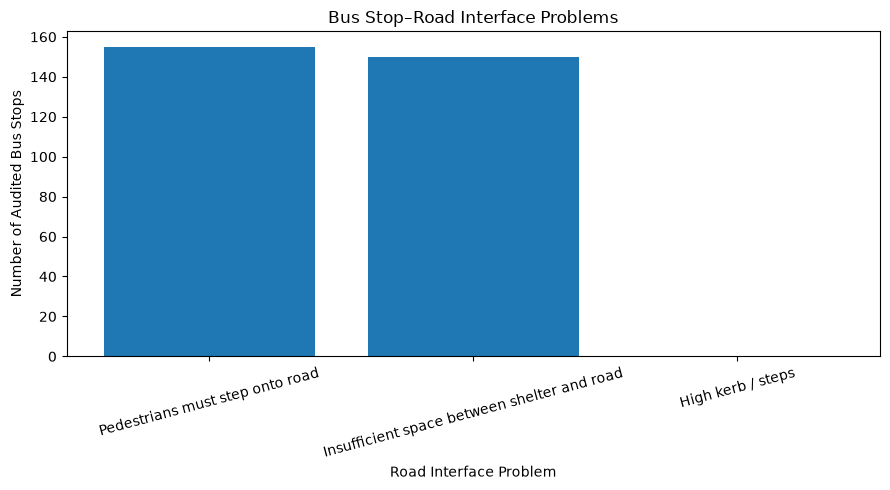

In [74]:
# ------------------------------------------------------------
# 7.12 VISUALIZATION — INDIVIDUAL PROBLEMS
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    road_problem_summary["Problem"],
    road_problem_summary["Stops"]
)

plt.ylabel("Number of Audited Bus Stops")
plt.xlabel("Road Interface Problem")
plt.title("Bus Stop–Road Interface Problems")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

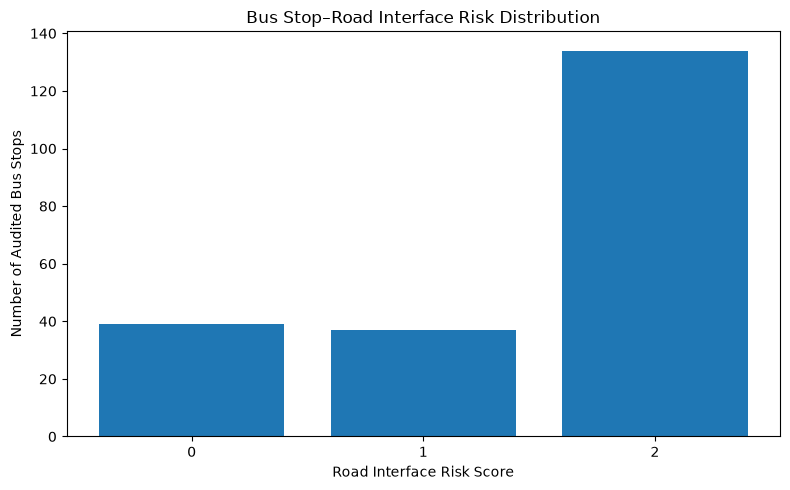

In [75]:
# ------------------------------------------------------------
# 7.13 VISUALIZATION — RISK SCORE
# ------------------------------------------------------------

score_counts = (
    bus_stop["road_interface_score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    score_counts.index.astype(str),
    score_counts.values
)

plt.xlabel("Road Interface Risk Score")
plt.ylabel("Number of Audited Bus Stops")
plt.title("Bus Stop–Road Interface Risk Distribution")

plt.tight_layout()
plt.show()

In [76]:
# ------------------------------------------------------------
# 7.14 FINAL ROAD-INTERFACE TABLE
# ------------------------------------------------------------

road_interface_table = bus_stop[
    [
        stop_name_col,
        pass_road_col,
        space_road_col,
        kerb_col,
        "road_access_problem",
        "road_space_problem",
        "high_kerb_problem",
        "road_interface_score"
    ]
].copy()

road_interface_table = road_interface_table.rename(columns={
    stop_name_col: "Bus Stop",
    pass_road_col: "Pass Without Entering Road",
    space_road_col: "Space Between Shelter & Road",
    kerb_col: "High Kerb / Steps",
    "road_access_problem": "Road Entry Problem",
    "road_space_problem": "Road Space Problem",
    "high_kerb_problem": "High Kerb Problem",
    "road_interface_score": "Road Interface Score"
})

road_interface_table.sort_values(
    "Road Interface Score",
    ascending=False
)

,Bus Stop,Pass Without Entering Road,Space Between Shelter & Road,High Kerb / Steps,Road Entry Problem,Road Space Problem,High Kerb Problem,Road Interface Score
0,KAMARAJAR SALAI BUS STOP,0,0,NaN,True,True,<NA>,2
2,Ambedkar play ground,0,0,NaN,True,True,<NA>,2
10,Pallikarnai Bus Stop,0,0,NaN,True,True,<NA>,2
3,[surveyor name removed],0,0,NaN,True,True,<NA>,2
4,[surveyor name removed],0,0,NaN,True,True,<NA>,2
...,...,...,...,...,...,...,...,...
188,Church park convent,1,1,NaN,False,False,<NA>,0
194,Saidapet (towards guindy),1,1,NaN,False,False,<NA>,0
196,Vivekanandar House,1,1,NaN,False,False,<NA>,0
205,Venkat Narayana Road,1,1,NaN,False,False,<NA>,0


In [77]:
# ------------------------------------------------------------
# 7.15 KEY FINDINGS
# ------------------------------------------------------------

total = len(bus_stop)

print("=" * 70)
print("BUS STOP–ROAD INTERFACE — KEY FINDINGS")
print("=" * 70)

for _, row in road_problem_summary.iterrows():
    print(
        f"{row['Problem']}: "
        f"{row['Stops']} stops "
        f"({row['Percentage']}%)"
    )

print()

for score in sorted(bus_stop["road_interface_score"].unique()):
    
    count = (
        bus_stop["road_interface_score"] == score
    ).sum()
    
    pct = round(count / total * 100, 1)
    
    print(
        f"Score {score}: {count} stops ({pct}%)"
    )

print()

print(
    "High-priority stops (score >= 2):",
    (bus_stop["road_interface_score"] >= 2).sum()
)

print(
    "Critical stops (score = 3):",
    (bus_stop["road_interface_score"] == 3).sum()
)

BUS STOP–ROAD INTERFACE — KEY FINDINGS
Pedestrians must step onto road: 155 stops (73.8%)
Insufficient space between shelter and road: 150 stops (71.4%)
High kerb / steps: 0 stops (0.0%)

Score 0: 39 stops (18.6%)
Score 1: 37 stops (17.6%)
Score 2: 134 stops (63.8%)

High-priority stops (score >= 2): 134
Critical stops (score = 3): 0


In [78]:
# ============================================================
# 8. DRAINAGE & ENVIRONMENT ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

drainage_environment_cols = [
    'Is there evidence of water-logging or poor drainage around the stop?',
    'Is the bus stop area free of encroachments?'
]

for col in drainage_environment_cols:
    print("\n" + "=" * 100)
    print(col)
    print("-" * 100)

    print(bus_stop[col].value_counts(dropna=False))

    print("\nPercentage:")
    print(
        bus_stop[col]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(1)
    )


Is there evidence of water-logging or poor drainage around the stop?
----------------------------------------------------------------------------------------------------
Is there evidence of water-logging or poor drainage around the stop?
No – area appears well-drained                                      120
Yes – signs of standing water, algae, or drainage issues visible     57
Unsure                                                               33
Name: count, dtype: int64

Percentage:
Is there evidence of water-logging or poor drainage around the stop?
No – area appears well-drained                                      57.1
Yes – signs of standing water, algae, or drainage issues visible    27.1
Unsure                                                              15.7
Name: proportion, dtype: float64

Is the bus stop area free of encroachments?
----------------------------------------------------------------------------------------------------
Is the bus stop area free of encroachm

In [79]:
# ------------------------------------------------------------
# 8.2 WATERLOGGING / DRAINAGE
# ------------------------------------------------------------

water_col = 'Is there evidence of water-logging or poor drainage around the stop?'

print("=" * 80)
print("WATERLOGGING / POOR DRAINAGE")
print("=" * 80)

water_summary = pd.DataFrame({
    "Count": bus_stop[water_col].value_counts(dropna=False),
    "Percentage": (
        bus_stop[water_col]
        .value_counts(normalize=True, dropna=False)
        * 100
    ).round(1)
})

water_summary

WATERLOGGING / POOR DRAINAGE


,Count,Percentage
Is there evidence of water-logging or poor drainage around the stop?,,
No – area appears well-drained,120,57.1
"Yes – signs of standing water, algae, or drainage issues visible",57,27.1
Unsure,33,15.7


In [80]:
# ------------------------------------------------------------
# 8.3 STOPS WITH DRAINAGE PROBLEMS
# ------------------------------------------------------------

water_problem_values = [
    value for value in bus_stop[water_col].dropna().unique()
    if any(
        word in str(value).lower()
        for word in ["yes", "poor", "water", "drain"]
    )
]

print("Detected possible problem responses:")
print(water_problem_values)

Detected possible problem responses:
['No – area appears well-drained', 'Yes – signs of standing water, algae, or drainage issues visible']


In [81]:
# ------------------------------------------------------------
# 8.4 ENCROACHMENT / ENVIRONMENT
# ------------------------------------------------------------

encroach_col = 'Is the bus stop area free of encroachments?'

print("=" * 80)
print("BUS STOP AREA — ENCROACHMENT")
print("=" * 80)

encroach_summary = pd.DataFrame({
    "Count": bus_stop[encroach_col].value_counts(dropna=False),
    "Percentage": (
        bus_stop[encroach_col]
        .value_counts(normalize=True, dropna=False)
        * 100
    ).round(1)
})

encroach_summary

BUS STOP AREA — ENCROACHMENT


,Count,Percentage
Is the bus stop area free of encroachments?,,
"Partially encroached – e.g., vendors, parked two-wheelers, auto-rickshaws, construction material",100,47.6
"Yes – fully accessible, no obstructions",86,41.0
Heavily encroached – the stop is largely unusable because of obstructions,24,11.4


In [82]:
# ------------------------------------------------------------
# 8.5 INSPECT CATEGORIES
# ------------------------------------------------------------

for col in drainage_environment_cols:

    print("\n" + "=" * 100)
    print(col)
    print("-" * 100)

    for value, count in bus_stop[col].value_counts(dropna=False).items():
        print(f"{repr(value)} : {count}")


Is there evidence of water-logging or poor drainage around the stop?
----------------------------------------------------------------------------------------------------
'No – area appears well-drained' : 120
'Yes – signs of standing water, algae, or drainage issues visible' : 57
'Unsure' : 33

Is the bus stop area free of encroachments?
----------------------------------------------------------------------------------------------------
'Partially encroached – e.g., vendors, parked two-wheelers, auto-rickshaws, construction material' : 100
' Yes – fully accessible, no obstructions' : 86
'Heavily encroached – the stop is largely unusable because of obstructions' : 24


In [83]:
# ------------------------------------------------------------
# 8.6 DRAINAGE PROBLEM STOPS
# ------------------------------------------------------------

drainage_problem_mask = (
    bus_stop[water_col]
    .astype("string")
    .str.lower()
    .str.contains(
        r'yes|poor|water|problem|flood|logging',
        regex=True,
        na=False
    )
)

drainage_problem_stops = bus_stop[drainage_problem_mask]

print(
    "Stops with possible drainage/waterlogging problems:",
    len(drainage_problem_stops)
)

drainage_problem_stops[
    [
        'Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)',
        water_col
    ]
]

Stops with possible drainage/waterlogging problems: 57


,"Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)",Is there evidence of water-logging or poor drainage around the stop?
6,Dr ambedkar playground bus stop,"Yes – signs of standing water, algae, or drain..."
9,West balaji nagar bus stop,"Yes – signs of standing water, algae, or drain..."
10,Pallikarnai Bus Stop,"Yes – signs of standing water, algae, or drain..."
14,M.P. தேவதாஸ் உயர்நிலைப்பள்ளி,"Yes – signs of standing water, algae, or drain..."
15,MKB Nagar,"Yes – signs of standing water, algae, or drain..."
16,MKB POLICE STATION,"Yes – signs of standing water, algae, or drain..."
20,Moolakadai bus stand 2,"Yes – signs of standing water, algae, or drain..."
22,Simpson moolakadai,"Yes – signs of standing water, algae, or drain..."
24,Don Bosco school moolakadai,"Yes – signs of standing water, algae, or drain..."
28,Melpatti Ponnappa street Perambur,"Yes – signs of standing water, algae, or drain..."


In [84]:
# ------------------------------------------------------------
# 8.7 DRAINAGE PROBLEM INDICATOR
# ------------------------------------------------------------

bus_stop["drainage_problem"] = (
    bus_stop[water_col]
    .astype("string")
    .str.lower()
    .str.contains(
        r'yes|poor|waterlogging|water-logging',
        regex=True,
        na=False
    )
)

print(
    "Drainage problem stops:",
    bus_stop["drainage_problem"].sum()
)

Drainage problem stops: 57


In [85]:
# ------------------------------------------------------------
# 8.8 ENCROACHMENT PROBLEM INDICATOR
# ------------------------------------------------------------

bus_stop["environment_encroachment_problem"] = (
    bus_stop[encroach_col]
    .astype("string")
    .str.lower()
    .str.contains(
        r'no|partial|heavy|encroach',
        regex=True,
        na=False
    )
)

print(
    "Stops with encroachment problems:",
    bus_stop["environment_encroachment_problem"].sum()
)

Stops with encroachment problems: 210


In [86]:
# ------------------------------------------------------------
# 8.9 ENVIRONMENTAL RISK SCORE
# ------------------------------------------------------------

bus_stop["environment_risk_score"] = (
    bus_stop["drainage_problem"].astype(int)
    + bus_stop["environment_encroachment_problem"].astype(int)
)

print(
    bus_stop["environment_risk_score"]
    .value_counts()
    .sort_index()
)

environment_risk_score
1    153
2     57
Name: count, dtype: int64


In [87]:
# ------------------------------------------------------------
# 8.10 PRIORITY ENVIRONMENTAL STOPS
# ------------------------------------------------------------

stop_name_col = (
    'Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)'
)

environment_priority = bus_stop[
    bus_stop["environment_risk_score"] >= 1
].sort_values(
    "environment_risk_score",
    ascending=False
)

print(
    "Stops with at least one environmental problem:",
    len(environment_priority)
)

environment_priority[
    [
        stop_name_col,
        water_col,
        encroach_col,
        "environment_risk_score"
    ]
]

Stops with at least one environmental problem: 210


,"Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)",Is there evidence of water-logging or poor drainage around the stop?,Is the bus stop area free of encroachments?,environment_risk_score
6,Dr ambedkar playground bus stop,"Yes – signs of standing water, algae, or drain...","Yes – fully accessible, no obstructions",2
9,West balaji nagar bus stop,"Yes – signs of standing water, algae, or drain...","Partially encroached – e.g., vendors, parked t...",2
14,M.P. தேவதாஸ் உயர்நிலைப்பள்ளி,"Yes – signs of standing water, algae, or drain...","Partially encroached – e.g., vendors, parked t...",2
15,MKB Nagar,"Yes – signs of standing water, algae, or drain...","Partially encroached – e.g., vendors, parked t...",2
16,MKB POLICE STATION,"Yes – signs of standing water, algae, or drain...","Partially encroached – e.g., vendors, parked t...",2
...,...,...,...,...
203,New Boag road bus stop ( towards T.nagar),No – area appears well-drained,Heavily encroached – the stop is largely unusa...,1
205,Venkat Narayana Road,No – area appears well-drained,"Yes – fully accessible, no obstructions",1
206,Saidapet court,No – area appears well-drained,"Yes – fully accessible, no obstructions",1
208,Thirivanmiyur depot ( towards Gandhi nagar),No – area appears well-drained,"Partially encroached – e.g., vendors, parked t...",1


In [88]:
# ------------------------------------------------------------
# 8.11 CRITICAL ENVIRONMENTAL STOPS
# ------------------------------------------------------------

critical_environment = bus_stop[
    bus_stop["environment_risk_score"] == 2
]

print(
    "Stops with BOTH drainage and encroachment problems:",
    len(critical_environment)
)

critical_environment[
    [
        stop_name_col,
        water_col,
        encroach_col,
        "environment_risk_score"
    ]
]

Stops with BOTH drainage and encroachment problems: 57


,"Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)",Is there evidence of water-logging or poor drainage around the stop?,Is the bus stop area free of encroachments?,environment_risk_score
6,Dr ambedkar playground bus stop,"Yes – signs of standing water, algae, or drain...","Yes – fully accessible, no obstructions",2
9,West balaji nagar bus stop,"Yes – signs of standing water, algae, or drain...","Partially encroached – e.g., vendors, parked t...",2
10,Pallikarnai Bus Stop,"Yes – signs of standing water, algae, or drain...","Partially encroached – e.g., vendors, parked t...",2
14,M.P. தேவதாஸ் உயர்நிலைப்பள்ளி,"Yes – signs of standing water, algae, or drain...","Partially encroached – e.g., vendors, parked t...",2
15,MKB Nagar,"Yes – signs of standing water, algae, or drain...","Partially encroached – e.g., vendors, parked t...",2
16,MKB POLICE STATION,"Yes – signs of standing water, algae, or drain...","Partially encroached – e.g., vendors, parked t...",2
20,Moolakadai bus stand 2,"Yes – signs of standing water, algae, or drain...","Partially encroached – e.g., vendors, parked t...",2
22,Simpson moolakadai,"Yes – signs of standing water, algae, or drain...","Partially encroached – e.g., vendors, parked t...",2
24,Don Bosco school moolakadai,"Yes – signs of standing water, algae, or drain...",Heavily encroached – the stop is largely unusa...,2
28,Melpatti Ponnappa street Perambur,"Yes – signs of standing water, algae, or drain...","Yes – fully accessible, no obstructions",2


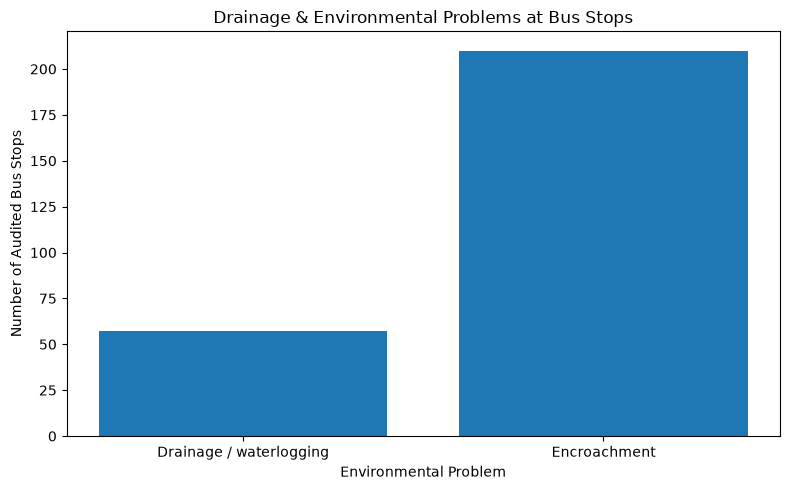

In [89]:
# ------------------------------------------------------------
# 8.12 VISUALIZATION
# ------------------------------------------------------------

environment_counts = {
    "Drainage / waterlogging": bus_stop["drainage_problem"].sum(),
    "Encroachment": bus_stop["environment_encroachment_problem"].sum()
}

plt.figure(figsize=(8, 5))

plt.bar(
    environment_counts.keys(),
    environment_counts.values()
)

plt.ylabel("Number of Audited Bus Stops")
plt.xlabel("Environmental Problem")
plt.title("Drainage & Environmental Problems at Bus Stops")

plt.tight_layout()
plt.show()

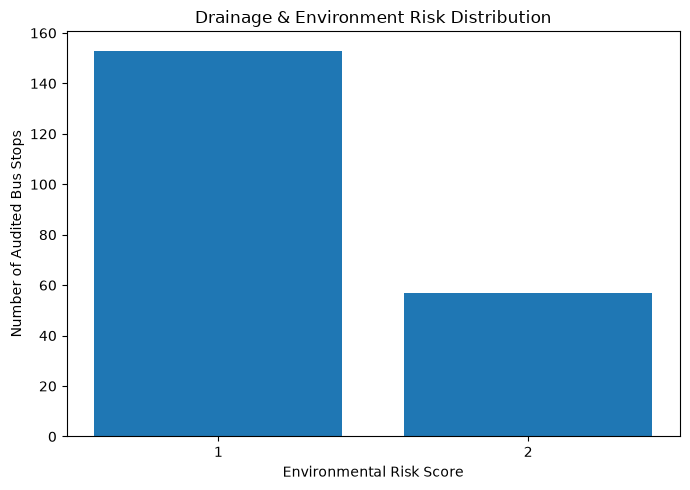

In [90]:
# ------------------------------------------------------------
# 8.13 RISK SCORE VISUALIZATION
# ------------------------------------------------------------

score_counts = (
    bus_stop["environment_risk_score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 5))

plt.bar(
    score_counts.index.astype(str),
    score_counts.values
)

plt.xlabel("Environmental Risk Score")
plt.ylabel("Number of Audited Bus Stops")
plt.title("Drainage & Environment Risk Distribution")

plt.tight_layout()
plt.show()

In [91]:
# ------------------------------------------------------------
# 8.14 FINAL SUMMARY
# ------------------------------------------------------------

total = len(bus_stop)

drainage_count = bus_stop["drainage_problem"].sum()
encroach_count = bus_stop["environment_encroachment_problem"].sum()
critical_count = (bus_stop["environment_risk_score"] == 2).sum()

print("=" * 80)
print("DRAINAGE & ENVIRONMENT — KEY FINDINGS")
print("=" * 80)

print(
    f"Drainage / waterlogging problems: "
    f"{drainage_count} ({drainage_count / total * 100:.1f}%)"
)

print(
    f"Encroachment problems: "
    f"{encroach_count} ({encroach_count / total * 100:.1f}%)"
)

print(
    f"Stops with both problems: "
    f"{critical_count} ({critical_count / total * 100:.1f}%)"
)

DRAINAGE & ENVIRONMENT — KEY FINDINGS
Drainage / waterlogging problems: 57 (27.1%)
Encroachment problems: 210 (100.0%)
Stops with both problems: 57 (27.1%)


In [92]:
# ============================================================
# 6. PASSENGER INFORMATION ANALYSIS
# ============================================================

info_cols = {
    "Bus stop name displayed":
        'Is the name of the bus stop clearly displayed?',

    "Bus route information":
        'Is bus route information displayed at the stop?'
}


# ------------------------------------------------------------
# 6.1 DISTRIBUTION OF PASSENGER INFORMATION
# ------------------------------------------------------------

for name, col in info_cols.items():

    print("\n" + "=" * 90)
    print(name)
    print(col)
    print("-" * 90)

    counts = bus_stop[col].value_counts(dropna=False)

    percentages = (
        bus_stop[col]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(1)
    )

    result = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages
    })

    print(result)


Bus stop name displayed
Is the name of the bus stop clearly displayed?
------------------------------------------------------------------------------------------
                                                Count  Percentage
Is the name of the bus stop clearly displayed?                   
Yes – name is prominently visible and legible      80        38.1
No – name is missing                               58        27.6
Yes – but faded, small, or difficult to read       43        20.5
NaN                                                29        13.8

Bus route information
Is bus route information displayed at the stop?
------------------------------------------------------------------------------------------
                                                    Count  Percentage
Is bus route information displayed at the stop?                      
No information displayed at all                        73        34.8
Yes – route list is prominently displayed and a...     57        27.1

In [93]:
# ------------------------------------------------------------
# 6.2 INSPECT EXACT RESPONSE VALUES
# ------------------------------------------------------------

print("=" * 80)
print("BUS STOP NAME — EXACT VALUES")
print("=" * 80)

print(
    bus_stop[info_cols["Bus stop name displayed"]]
    .dropna()
    .unique()
)

print("\n" + "=" * 80)
print("ROUTE INFORMATION — EXACT VALUES")
print("=" * 80)

print(
    bus_stop[info_cols["Bus route information"]]
    .dropna()
    .unique()
)

BUS STOP NAME — EXACT VALUES
<StringArray>
[ 'Yes – but faded, small, or difficult to read',
 'Yes – name is prominently visible and legible',
                          'No – name is missing']
Length: 3, dtype: str

ROUTE INFORMATION — EXACT VALUES
<StringArray>
[                              'No information displayed at all',
 'Yes – but information is unclear, faded, or partially missing',
 'Yes – route list is prominently displayed and appears current',
            'Yes – but information seems outdated or unreliable']
Length: 4, dtype: str


In [94]:
# ============================================================
# 6.3 PASSENGER INFORMATION — EXACT PROBLEM INDICATORS
# ============================================================

name_col = info_cols["Bus stop name displayed"]
route_col = info_cols["Bus route information"]

# ------------------------------------------------------------
# Stop name problems
# ------------------------------------------------------------

bus_stop["missing_stop_name_problem"] = (
    bus_stop[name_col]
    == "No – name is missing"
)

bus_stop["poor_stop_name_problem"] = (
    bus_stop[name_col]
    == "Yes – but faded, small, or difficult to read"
)


# ------------------------------------------------------------
# Route information problems
# ------------------------------------------------------------

bus_stop["missing_route_information_problem"] = (
    bus_stop[route_col]
    == "No information displayed at all"
)

bus_stop["poor_route_information_problem"] = (
    bus_stop[route_col].isin([
        "Yes – but information is unclear, faded, or partially missing",
        "Yes – but information seems outdated or unreliable"
    ])
)


# ------------------------------------------------------------
# Check counts
# ------------------------------------------------------------

print("=" * 80)
print("PASSENGER INFORMATION PROBLEMS")
print("=" * 80)

print(
    "Missing stop name:",
    bus_stop["missing_stop_name_problem"].sum()
)

print(
    "Poor / difficult-to-read stop name:",
    bus_stop["poor_stop_name_problem"].sum()
)

print(
    "Missing route information:",
    bus_stop["missing_route_information_problem"].sum()
)

print(
    "Poor / unreliable route information:",
    bus_stop["poor_route_information_problem"].sum()
)

PASSENGER INFORMATION PROBLEMS
Missing stop name: 58
Poor / difficult-to-read stop name: 43
Missing route information: 73
Poor / unreliable route information: 51


In [95]:
# ============================================================
# 6.4 PASSENGER INFORMATION PROBLEM SCORE
# ============================================================

bus_stop["passenger_information_score"] = (
    bus_stop["missing_stop_name_problem"].astype(int)
    + bus_stop["poor_stop_name_problem"].astype(int)
    + bus_stop["missing_route_information_problem"].astype(int)
    + bus_stop["poor_route_information_problem"].astype(int)
)

print("=" * 80)
print("PASSENGER INFORMATION PROBLEM SCORE")
print("=" * 80)

print(
    bus_stop["passenger_information_score"]
    .value_counts()
    .sort_index()
)

PASSENGER INFORMATION PROBLEM SCORE
passenger_information_score
0    73
1    49
2    88
Name: count, dtype: int64


In [96]:
# ============================================================
# 6.5 INFORMATION QUALITY CATEGORY
# ============================================================

bus_stop["stop_name_problem"] = (
    bus_stop["missing_stop_name_problem"]
    | bus_stop["poor_stop_name_problem"]
)

bus_stop["route_information_problem"] = (
    bus_stop["missing_route_information_problem"]
    | bus_stop["poor_route_information_problem"]
)

bus_stop["information_problem_count"] = (
    bus_stop["stop_name_problem"].astype(int)
    + bus_stop["route_information_problem"].astype(int)
)

bus_stop["information_quality"] = "Good"

bus_stop.loc[
    bus_stop["information_problem_count"] == 1,
    "information_quality"
] = "Needs improvement"

bus_stop.loc[
    bus_stop["information_problem_count"] == 2,
    "information_quality"
] = "Poor"

print("=" * 80)
print("OVERALL PASSENGER INFORMATION QUALITY")
print("=" * 80)

print(
    bus_stop["information_quality"]
    .value_counts(dropna=False)
)

print("\nPercentage:")
print(
    bus_stop["information_quality"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(1)
)

OVERALL PASSENGER INFORMATION QUALITY
information_quality
Poor                 88
Good                 73
Needs improvement    49
Name: count, dtype: int64

Percentage:
information_quality
Poor                 41.9
Good                 34.8
Needs improvement    23.3
Name: proportion, dtype: float64


In [97]:
# ============================================================
# 6.6 CRITICAL INFORMATION STOPS
# ============================================================

critical_information = bus_stop[
    bus_stop["information_problem_count"] == 2
].copy()

print(
    "Stops with problems in BOTH name and route information:",
    len(critical_information)
)

critical_information[
    [
        bus_stop_name_col,
        name_col,
        route_col,
        "information_problem_count"
    ]
]

Stops with problems in BOTH name and route information: 88


,"Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)",Is the name of the bus stop clearly displayed?,Is bus route information displayed at the stop?,information_problem_count
0,KAMARAJAR SALAI BUS STOP,"Yes – but faded, small, or difficult to read",No information displayed at all,2
3,[surveyor name removed],No – name is missing,No information displayed at all,2
4,[surveyor name removed],No – name is missing,No information displayed at all,2
7,Thalambur Kootu road,No – name is missing,No information displayed at all,2
8,[surveyor name removed],No – name is missing,No information displayed at all,2
...,...,...,...,...
204,Nadasan park,No – name is missing,No information displayed at all,2
205,Venkat Narayana Road,"Yes – but faded, small, or difficult to read",No information displayed at all,2
206,Saidapet court,"Yes – but faded, small, or difficult to read","Yes – but information is unclear, faded, or pa...",2
208,Thirivanmiyur depot ( towards Gandhi nagar),"Yes – but faded, small, or difficult to read",No information displayed at all,2


In [98]:
# ============================================================
# 6.7 HIGH-PRIORITY INFORMATION STOPS
# ============================================================

information_priority = bus_stop[
    bus_stop["information_problem_count"] >= 1
].copy()

information_priority = information_priority.sort_values(
    "information_problem_count",
    ascending=False
)

print(
    "Stops with at least one information problem:",
    len(information_priority)
)

information_priority[
    [
        bus_stop_name_col,
        name_col,
        route_col,
        "information_quality",
        "information_problem_count"
    ]
]

Stops with at least one information problem: 137


,"Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)",Is the name of the bus stop clearly displayed?,Is bus route information displayed at the stop?,information_quality,information_problem_count
0,KAMARAJAR SALAI BUS STOP,"Yes – but faded, small, or difficult to read",No information displayed at all,Poor,2
3,[surveyor name removed],No – name is missing,No information displayed at all,Poor,2
4,[surveyor name removed],No – name is missing,No information displayed at all,Poor,2
8,[surveyor name removed],No – name is missing,No information displayed at all,Poor,2
7,Thalambur Kootu road,No – name is missing,No information displayed at all,Poor,2
...,...,...,...,...,...
176,Arasankazhani,Yes – name is prominently visible and legible,No information displayed at all,Needs improvement,1
198,M.G.Road( towards guindy),"Yes – but faded, small, or difficult to read",Yes – route list is prominently displayed and ...,Needs improvement,1
197,Adyar (towards Besant nagar),"Yes – but faded, small, or difficult to read",Yes – route list is prominently displayed and ...,Needs improvement,1
196,Vivekanandar House,Yes – name is prominently visible and legible,"Yes – but information is unclear, faded, or pa...",Needs improvement,1


In [99]:
# ============================================================
# 6.8 INFORMATION PROBLEM COMBINATIONS
# ============================================================

information_combinations = (
    bus_stop[
        [
            "stop_name_problem",
            "route_information_problem"
        ]
    ]
    .value_counts()
    .reset_index(name="Stops")
)

information_combinations["Percentage"] = (
    information_combinations["Stops"]
    / len(bus_stop) * 100
).round(1)

information_combinations

,stop_name_problem,route_information_problem,Stops,Percentage
0,True,True,88,41.9
1,False,False,73,34.8
2,False,True,36,17.1
3,True,False,13,6.2


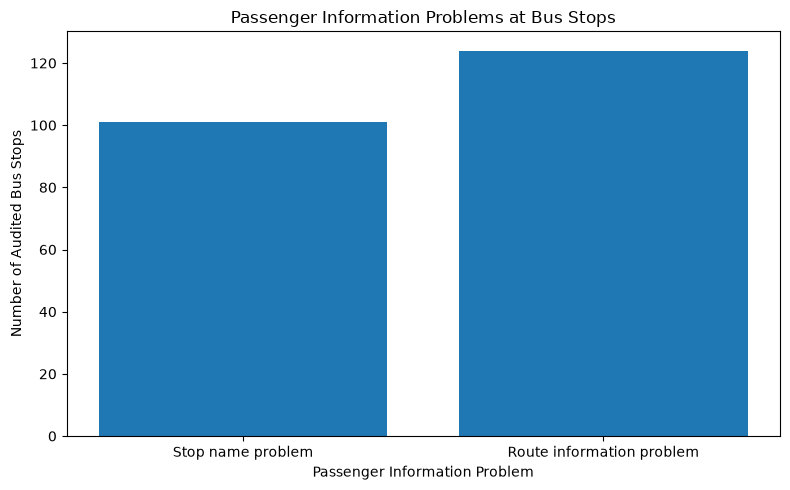

In [100]:
# ============================================================
# 6.9 VISUALIZATION — INFORMATION PROBLEMS
# ============================================================

information_problem_counts = {
    "Stop name problem":
        bus_stop["stop_name_problem"].sum(),

    "Route information problem":
        bus_stop["route_information_problem"].sum()
}

plt.figure(figsize=(8, 5))

plt.bar(
    information_problem_counts.keys(),
    information_problem_counts.values()
)

plt.xlabel("Passenger Information Problem")
plt.ylabel("Number of Audited Bus Stops")
plt.title("Passenger Information Problems at Bus Stops")

plt.tight_layout()
plt.show()

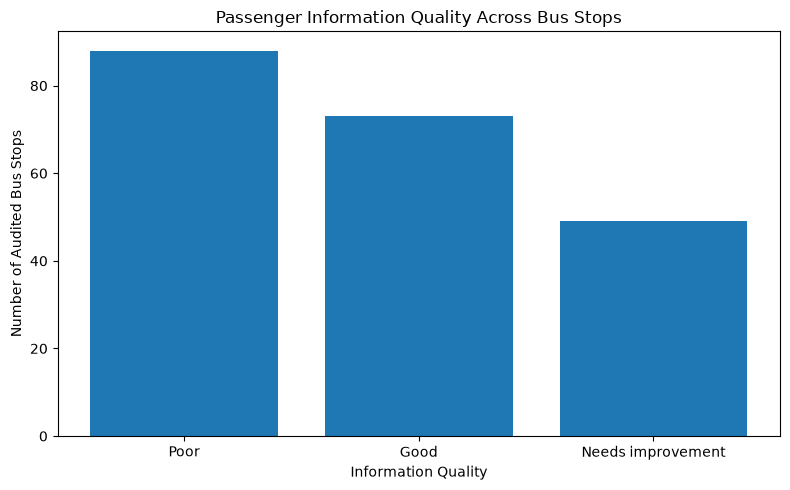

In [101]:
# ============================================================
# 6.10 VISUALIZATION — INFORMATION QUALITY
# ============================================================

quality_counts = (
    bus_stop["information_quality"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

plt.bar(
    quality_counts.index,
    quality_counts.values
)

plt.xlabel("Information Quality")
plt.ylabel("Number of Audited Bus Stops")
plt.title("Passenger Information Quality Across Bus Stops")

plt.tight_layout()
plt.show()

In [102]:
# ============================================================
# 6.11 FINAL PASSENGER INFORMATION TABLE
# ============================================================

passenger_information_table = bus_stop[
    [
        bus_stop_name_col,
        name_col,
        route_col,
        "stop_name_problem",
        "route_information_problem",
        "information_quality",
        "information_problem_count"
    ]
].copy()

passenger_information_table = passenger_information_table.rename(
    columns={
        bus_stop_name_col: "Bus Stop",
        name_col: "Stop Name Displayed",
        route_col: "Route Information",
        "stop_name_problem": "Stop Name Problem",
        "route_information_problem": "Route Information Problem",
        "information_quality": "Information Quality",
        "information_problem_count": "Information Problem Count"
    }
)

passenger_information_table = (
    passenger_information_table
    .sort_values(
        "Information Problem Count",
        ascending=False
    )
)

passenger_information_table

,Bus Stop,Stop Name Displayed,Route Information,Stop Name Problem,Route Information Problem,Information Quality,Information Problem Count
0,KAMARAJAR SALAI BUS STOP,"Yes – but faded, small, or difficult to read",No information displayed at all,True,True,Poor,2
3,[surveyor name removed],No – name is missing,No information displayed at all,True,True,Poor,2
9,West balaji nagar bus stop,"Yes – but faded, small, or difficult to read",No information displayed at all,True,True,Poor,2
4,[surveyor name removed],No – name is missing,No information displayed at all,True,True,Poor,2
8,[surveyor name removed],No – name is missing,No information displayed at all,True,True,Poor,2
...,...,...,...,...,...,...,...
149,ரயில்வே காலனி,Yes – name is prominently visible and legible,Yes – route list is prominently displayed and ...,False,False,Good,0
189,Srinivasa Theatre,Yes – name is prominently visible and legible,Yes – route list is prominently displayed and ...,False,False,Good,0
200,Srinivasa Theatre ( towards guindy),NaN,NaN,False,False,Good,0
201,Aranganadhar subway (towards ashoknagar),NaN,NaN,False,False,Good,0


In [103]:
# ============================================================
# 6.12 KEY FINDINGS
# ============================================================

total = len(bus_stop)

name_problem_count = (
    bus_stop["stop_name_problem"].sum()
)

route_problem_count = (
    bus_stop["route_information_problem"].sum()
)

any_problem_count = (
    bus_stop["information_problem_count"] >= 1
).sum()

critical_count = (
    bus_stop["information_problem_count"] == 2
).sum()

print("=" * 80)
print("PASSENGER INFORMATION — KEY FINDINGS")
print("=" * 80)

print(
    f"Stop-name information problems: "
    f"{name_problem_count} "
    f"({name_problem_count / total * 100:.1f}%)"
)

print(
    f"Route-information problems: "
    f"{route_problem_count} "
    f"({route_problem_count / total * 100:.1f}%)"
)

print(
    f"Stops with at least one information problem: "
    f"{any_problem_count} "
    f"({any_problem_count / total * 100:.1f}%)"
)

print(
    f"Stops with problems in both information fields: "
    f"{critical_count} "
    f"({critical_count / total * 100:.1f}%)"
)

PASSENGER INFORMATION — KEY FINDINGS
Stop-name information problems: 101 (48.1%)
Route-information problems: 124 (59.0%)
Stops with at least one information problem: 137 (65.2%)
Stops with problems in both information fields: 88 (41.9%)


In [104]:
# ============================================================
# 7. AMENITIES & BASIC FACILITIES
# ============================================================

amenities_col = 'Tick all amenities present at this bus stop'

amenities = [
    'Seating / bench',
    'Sufficient seating for the number of people typically waiting',
    'Dustbin / waste bin',
    'Drinking water (tap or dispenser)',
    'Public toilet nearby (within eyesight)',
    'CCTV camera',
    'Digital information boards with real time arrival information and service alerts'
]

# ------------------------------------------------------------
# 7.1 AMENITY AVAILABILITY
# ------------------------------------------------------------

amenity_summary = pd.DataFrame({
    "Amenity": amenities,
    "Count": [
        bus_stop[amenities_col]
        .fillna('')
        .astype(str)
        .str.contains(amenity, regex=False)
        .sum()
        for amenity in amenities
    ]
})

amenity_summary["Percentage"] = (
    amenity_summary["Count"] / len(bus_stop) * 100
).round(1)

amenity_summary = amenity_summary.sort_values(
    "Count",
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("AMENITIES & BASIC FACILITIES")
print("=" * 80)

amenity_summary

AMENITIES & BASIC FACILITIES


,Amenity,Count,Percentage
0,Seating / bench,167,79.5
1,Dustbin / waste bin,70,33.3
2,Sufficient seating for the number of people ty...,60,28.6
3,Digital information boards with real time arri...,37,17.6
4,Drinking water (tap or dispenser),9,4.3
5,CCTV camera,5,2.4
6,Public toilet nearby (within eyesight),3,1.4


In [105]:
# ------------------------------------------------------------
# 7.2 BASIC FACILITIES
# ------------------------------------------------------------

basic_amenities = [
    'Dustbin / waste bin',
    'Drinking water (tap or dispenser)',
    'Public toilet nearby (within eyesight)',
    'CCTV camera',
    'Digital information boards with real time arrival information and service alerts'
]

basic_amenity_summary = amenity_summary[
    amenity_summary["Amenity"].isin(basic_amenities)
].copy()

print("=" * 80)
print("BASIC FACILITIES")
print("=" * 80)

basic_amenity_summary

BASIC FACILITIES


,Amenity,Count,Percentage
1,Dustbin / waste bin,70,33.3
3,Digital information boards with real time arri...,37,17.6
4,Drinking water (tap or dispenser),9,4.3
5,CCTV camera,5,2.4
6,Public toilet nearby (within eyesight),3,1.4


In [106]:
# ------------------------------------------------------------
# 7.3 AMENITY DEFICIENCY SCORE
# ------------------------------------------------------------

for amenity in basic_amenities:

    column_name = (
        amenity.lower()
        .replace(" ", "_")
        .replace("/", "")
        .replace("(", "")
        .replace(")", "")
        .replace(",", "")
    )

    bus_stop[column_name] = ~(
        bus_stop[amenities_col]
        .fillna('')
        .astype(str)
        .str.contains(amenity, regex=False)
    )

amenity_problem_columns = []

for amenity in basic_amenities:

    column_name = (
        amenity.lower()
        .replace(" ", "_")
        .replace("/", "")
        .replace("(", "")
        .replace(")", "")
        .replace(",", "")
    )

    amenity_problem_columns.append(column_name)

bus_stop["amenity_deficiency_score"] = (
    bus_stop[amenity_problem_columns]
    .astype(int)
    .sum(axis=1)
)

print(
    bus_stop["amenity_deficiency_score"]
    .value_counts()
    .sort_index()
)

amenity_deficiency_score
1      1
2      5
3     18
4     69
5    117
Name: count, dtype: int64


Stops lacking 3 or more basic facilities: 204


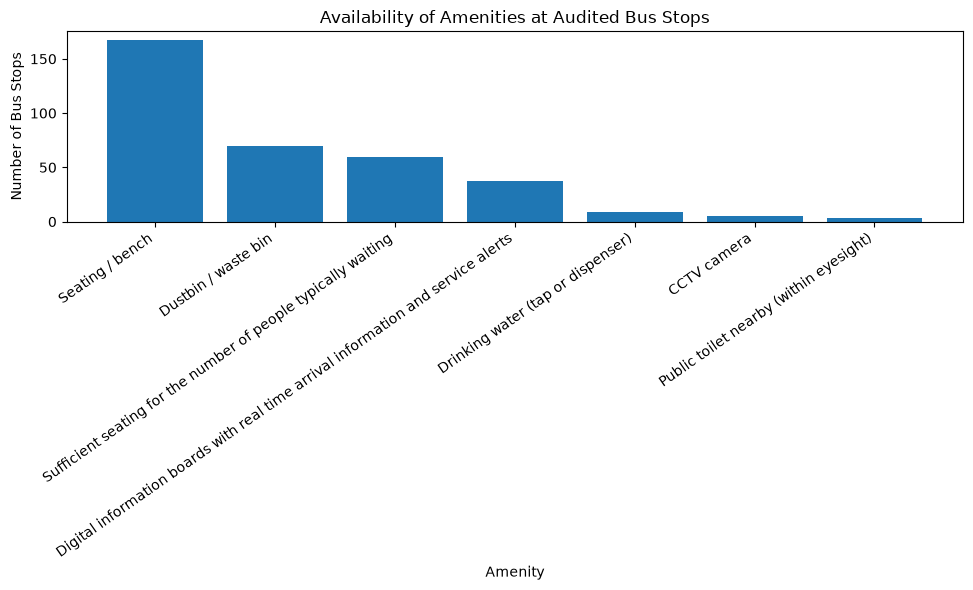

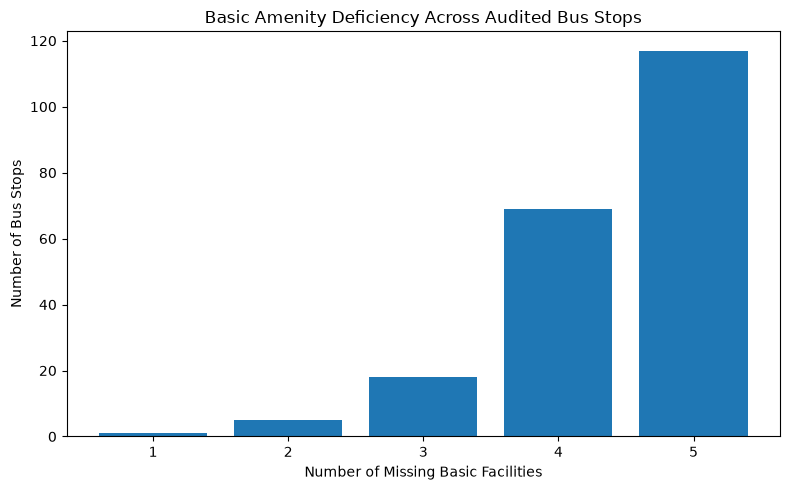

AMENITIES & BASIC FACILITIES — KEY FINDINGS
Seating / bench: 167 stops (79.5%)
Dustbin / waste bin: 70 stops (33.3%)
Sufficient seating for the number of people typically waiting: 60 stops (28.6%)
Digital information boards with real time arrival information and service alerts: 37 stops (17.6%)
Drinking water (tap or dispenser): 9 stops (4.3%)
CCTV camera: 5 stops (2.4%)
Public toilet nearby (within eyesight): 3 stops (1.4%)

Stops lacking 3+ basic facilities: 204
Stops lacking 4+ basic facilities: 186
Stops lacking all 5 basic facilities: 117


In [107]:
# ------------------------------------------------------------
# 7.4 HIGH-PRIORITY AMENITY STOPS
# ------------------------------------------------------------

amenity_priority_stops = bus_stop[
    bus_stop["amenity_deficiency_score"] >= 3
].sort_values(
    "amenity_deficiency_score",
    ascending=False
)

print(
    "Stops lacking 3 or more basic facilities:",
    len(amenity_priority_stops)
)

amenity_priority_stops[
    [
        stop_name_col,
        "amenity_deficiency_score"
    ]
]

# ------------------------------------------------------------
# 7.5 VISUALIZATION — AMENITY AVAILABILITY
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    amenity_summary["Amenity"],
    amenity_summary["Count"]
)

plt.xlabel("Amenity")
plt.ylabel("Number of Bus Stops")
plt.title("Availability of Amenities at Audited Bus Stops")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7.6 VISUALIZATION — AMENITY DEFICIENCY
# ------------------------------------------------------------

score_counts = (
    bus_stop["amenity_deficiency_score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    score_counts.index.astype(str),
    score_counts.values
)

plt.xlabel("Number of Missing Basic Facilities")
plt.ylabel("Number of Bus Stops")
plt.title("Basic Amenity Deficiency Across Audited Bus Stops")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7.7 KEY FINDINGS
# ------------------------------------------------------------

print("=" * 80)
print("AMENITIES & BASIC FACILITIES — KEY FINDINGS")
print("=" * 80)

for _, row in amenity_summary.iterrows():

    print(
        f"{row['Amenity']}: "
        f"{row['Count']} stops "
        f"({row['Percentage']}%)"
    )

print()

print(
    "Stops lacking 3+ basic facilities:",
    (bus_stop["amenity_deficiency_score"] >= 3).sum()
)

print(
    "Stops lacking 4+ basic facilities:",
    (bus_stop["amenity_deficiency_score"] >= 4).sum()
)

print(
    "Stops lacking all 5 basic facilities:",
    (bus_stop["amenity_deficiency_score"] == 5).sum()
)

SURROUNDING LAND USE / ACTIVITY
                                                    Count  Percentage
What is the primary land use or activity near t...                   
Mostly commercial - Retail shops. restaurants, ...     75        35.7
Mixed Use - A mix of commercial/residential/off...     58        27.6
Mostly commercial - Office buildings, malls, la...     28        13.3
Mostly Residential - Housing, Apartments, etc          26        12.4
Mostly Institutional - Schools, Hospitals, Govt...     17         8.1
Other                                                   4         1.9
Compound Wall / Dead Edge - No activity near th...      2         1.0

LAND USE — VALID RESPONSES ONLY
                                                    Count  Percentage
What is the primary land use or activity near t...                   
Mostly commercial - Retail shops. restaurants, ...     75        35.7
Mixed Use - A mix of commercial/residential/off...     58        27.6
Mostly commercial - Offic

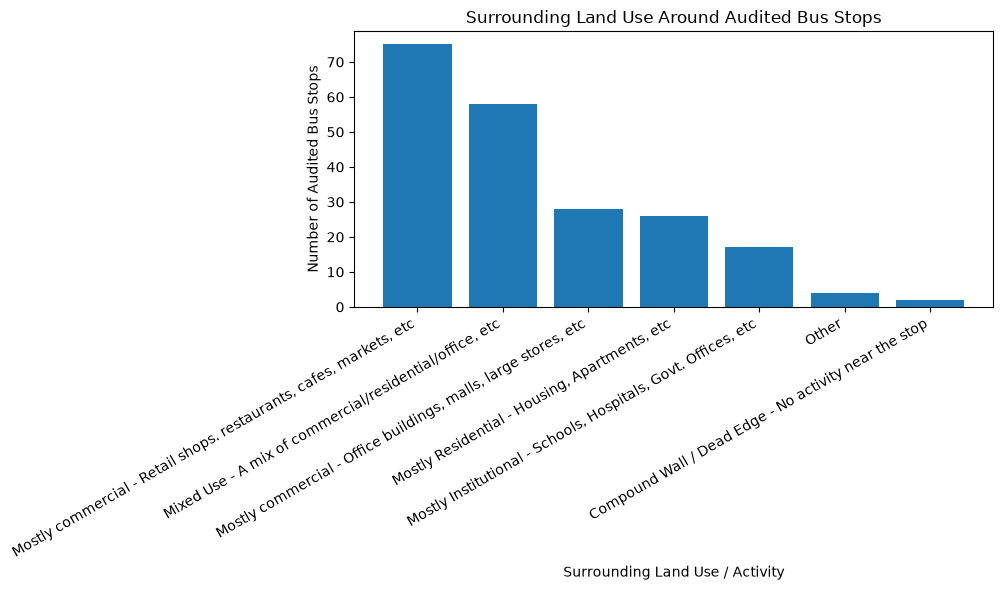

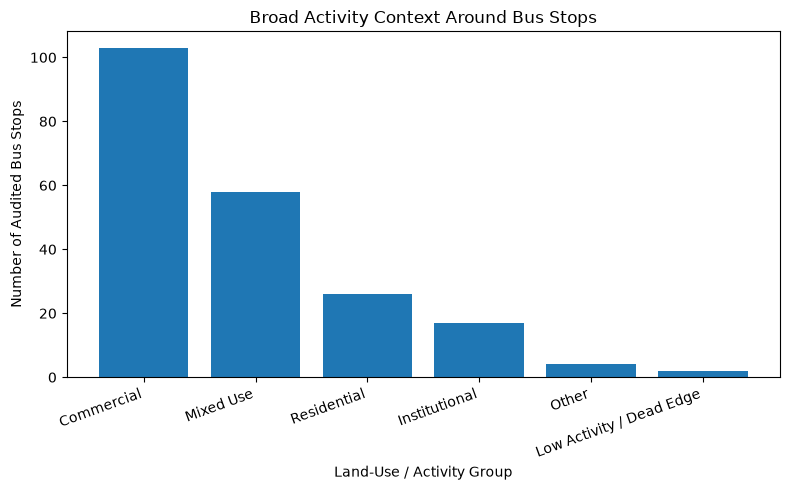


LAND USE × EXISTING INFRASTRUCTURE PROBLEMS
                          Stops  Avg_Road_Interface_Risk  Avg_Safety_Risk  \
land_use_group                                                              
Commercial                  103                     1.42              0.0   
Mixed Use                    58                     1.53              0.0   
Residential                  26                     1.54              0.0   
Institutional                17                     1.41              0.0   
Other                         4                     1.25              0.0   
Low Activity / Dead Edge      2                     0.50              0.0   

                          Avg_Shelter_Risk  Avg_Environment_Risk  
land_use_group                                                    
Commercial                            0.64                  1.41  
Mixed Use                             0.45                  1.19  
Residential                           0.54                  1.12  
Ins

In [108]:
# ============================================================
# 9. SURROUNDING LAND USE / ACTIVITY ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 9.1 LAND-USE COLUMN
# ------------------------------------------------------------

land_use_col = 'What is the primary land use or activity near this bus stop?'


# ------------------------------------------------------------
# 9.2 LAND-USE DISTRIBUTION
# ------------------------------------------------------------

land_use_summary = pd.DataFrame({
    "Count": bus_stop[land_use_col].value_counts(dropna=False),
    "Percentage": (
        bus_stop[land_use_col]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(1)
    )
})

print("=" * 100)
print("SURROUNDING LAND USE / ACTIVITY")
print("=" * 100)

print(land_use_summary)


# ------------------------------------------------------------
# 9.3 VALID RESPONSES ONLY
# ------------------------------------------------------------

valid_land_use = bus_stop[land_use_col].dropna()

land_use_valid_summary = (
    valid_land_use
    .value_counts()
    .to_frame("Count")
)

land_use_valid_summary["Percentage"] = (
    land_use_valid_summary["Count"]
    / len(valid_land_use)
    * 100
).round(1)

print("\n" + "=" * 100)
print("LAND USE — VALID RESPONSES ONLY")
print("=" * 100)

print(land_use_valid_summary)


# ------------------------------------------------------------
# 9.4 MISSING DATA CHECK
# ------------------------------------------------------------

missing_land_use = bus_stop[land_use_col].isna().sum()

print("\nMissing land-use responses:", missing_land_use)
print(
    "Missing percentage:",
    round(missing_land_use / len(bus_stop) * 100, 1),
    "%"
)


# ------------------------------------------------------------
# 9.5 DOMINANT LAND-USE TYPES
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("DOMINANT SURROUNDING LAND USES")
print("=" * 100)

print(
    land_use_valid_summary
    .sort_values("Count", ascending=False)
    .head(5)
)


# ------------------------------------------------------------
# 9.6 CREATE BROAD ACTIVITY GROUPS
# ------------------------------------------------------------
# This makes the analysis easier to interpret.
#
# We keep the original categories and additionally classify
# them into broader activity groups.


def classify_land_use(value):

    if pd.isna(value):
        return "Unknown"

    value = str(value).lower()

    if "mixed" in value:
        return "Mixed Use"

    if "commercial" in value:
        return "Commercial"

    if "residential" in value:
        return "Residential"

    if "institutional" in value:
        return "Institutional"

    if "dead edge" in value or "compound wall" in value:
        return "Low Activity / Dead Edge"

    if "other" in value:
        return "Other"

    return "Other"


bus_stop["land_use_group"] = (
    bus_stop[land_use_col]
    .apply(classify_land_use)
)


# ------------------------------------------------------------
# 9.7 BROAD LAND-USE SUMMARY
# ------------------------------------------------------------

land_use_group_summary = pd.DataFrame({
    "Count": bus_stop["land_use_group"].value_counts(),
    "Percentage": (
        bus_stop["land_use_group"]
        .value_counts(normalize=True)
        .mul(100)
        .round(1)
    )
})

print("\n" + "=" * 100)
print("BROAD SURROUNDING ACTIVITY GROUPS")
print("=" * 100)

print(land_use_group_summary)


# ------------------------------------------------------------
# 9.8 VISUALIZATION — LAND USE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    land_use_valid_summary.index.astype(str),
    land_use_valid_summary["Count"]
)

plt.xlabel("Surrounding Land Use / Activity")
plt.ylabel("Number of Audited Bus Stops")
plt.title("Surrounding Land Use Around Audited Bus Stops")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9.9 VISUALIZATION — BROAD ACTIVITY GROUPS
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

group_counts = (
    bus_stop["land_use_group"]
    .value_counts()
)

plt.bar(
    group_counts.index,
    group_counts.values
)

plt.xlabel("Land-Use / Activity Group")
plt.ylabel("Number of Audited Bus Stops")
plt.title("Broad Activity Context Around Bus Stops")

plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9.10 LAND USE × EXISTING PROBLEMS
# ------------------------------------------------------------
# We now connect land-use context with the problems already
# analysed in the project.
#
# These are EXISTING scores:
#   road_interface_score
#   safety_problem_score
#   shelter_problem_score
#   environment_risk_score
#
# We are NOT creating a new arbitrary land-use risk score.


land_use_problem_summary = (
    bus_stop
    .groupby("land_use_group")
    .agg(
        Stops=("land_use_group", "size"),

        Avg_Road_Interface_Risk=(
            "road_interface_score",
            "mean"
        ),

        Avg_Safety_Risk=(
            "safety_problem_score",
            "mean"
        ),

        Avg_Shelter_Risk=(
            "shelter_problem_score",
            "mean"
        ),

        Avg_Environment_Risk=(
            "environment_risk_score",
            "mean"
        )
    )
)

land_use_problem_summary = (
    land_use_problem_summary
    .round(2)
    .sort_values("Stops", ascending=False)
)

print("\n" + "=" * 100)
print("LAND USE × EXISTING INFRASTRUCTURE PROBLEMS")
print("=" * 100)

print(land_use_problem_summary)


# ------------------------------------------------------------
# 9.11 COMBINE EXISTING PROBLEM SCORES
# ------------------------------------------------------------
# This is only a comparison metric across land-use groups.
# It does NOT represent a scientifically validated risk score.


bus_stop["combined_problem_score"] = (
    bus_stop["road_interface_score"]
    + bus_stop["safety_problem_score"]
    + bus_stop["shelter_problem_score"]
    + bus_stop["environment_risk_score"]
)


land_use_combined = (
    bus_stop
    .groupby("land_use_group")
    .agg(
        Stops=("land_use_group", "size"),
        Average_Problem_Score=(
            "combined_problem_score",
            "mean"
        ),
        High_Problem_Stops=(
            "combined_problem_score",
            lambda x: (x >= 3).sum()
        )
    )
)

land_use_combined["High_Problem_%"] = (
    land_use_combined["High_Problem_Stops"]
    / land_use_combined["Stops"]
    * 100
).round(1)

land_use_combined["Average_Problem_Score"] = (
    land_use_combined["Average_Problem_Score"]
    .round(2)
)

land_use_combined = (
    land_use_combined
    .sort_values(
        "Average_Problem_Score",
        ascending=False
    )
)

print("\n" + "=" * 100)
print("LAND USE × OVERALL EXISTING PROBLEM BURDEN")
print("=" * 100)

print(land_use_combined)


# ------------------------------------------------------------
# 9.12 HIGH-PROBLEM STOPS BY LAND USE
# ------------------------------------------------------------

high_problem_land_use = bus_stop[
    bus_stop["combined_problem_score"] >= 3
].copy()

high_problem_land_use_summary = (
    high_problem_land_use
    .groupby("land_use_group")
    .size()
    .sort_values(ascending=False)
    .to_frame("High-Problem Stops")
)

print("\n" + "=" * 100)
print("HIGH-PROBLEM STOPS BY SURROUNDING LAND USE")
print("=" * 100)

print(high_problem_land_use_summary)


# ------------------------------------------------------------
# 9.13 FINAL LAND-USE TABLE
# ------------------------------------------------------------

land_use_final_table = (
    bus_stop
    .groupby("land_use_group")
    .agg(
        Stops=("land_use_group", "size"),
        Average_Problem_Score=(
            "combined_problem_score",
            "mean"
        )
    )
)

land_use_final_table["Share_of_Audited_Stops_%"] = (
    land_use_final_table["Stops"]
    / len(bus_stop)
    * 100
).round(1)

land_use_final_table["Average_Problem_Score"] = (
    land_use_final_table["Average_Problem_Score"]
    .round(2)
)

land_use_final_table = (
    land_use_final_table
    .sort_values("Stops", ascending=False)
)

print("\n" + "=" * 100)
print("FINAL SURROUNDING LAND-USE TABLE")
print("=" * 100)

print(land_use_final_table)


# ------------------------------------------------------------
# 9.14 KEY FINDINGS
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("SURROUNDING LAND USE — KEY FINDINGS")
print("=" * 100)

dominant = land_use_valid_summary.index[0]
dominant_count = land_use_valid_summary.iloc[0]["Count"]
dominant_pct = land_use_valid_summary.iloc[0]["Percentage"]

print(
    f"Most common surrounding land use: "
    f"{dominant} — {dominant_count} stops ({dominant_pct}%)"
)

print(
    f"Valid land-use observations: "
    f"{len(valid_land_use)} / {len(bus_stop)}"
)

print(
    f"Missing land-use observations: "
    f"{missing_land_use} ({missing_land_use / len(bus_stop) * 100:.1f}%)"
)

print("\nBroad activity distribution:")

for group, row in land_use_group_summary.iterrows():
    print(
        f"{group}: "
        f"{row['Count']} stops "
        f"({row['Percentage']}%)"
    )

print("\nLand-use groups by average existing problem burden:")

print(
    land_use_combined[
        [
            "Stops",
            "Average_Problem_Score",
            "High_Problem_Stops",
            "High_Problem_%"
        ]
    ]
)

GEOGRAPHIC COLUMNS
_Survey Location_latitude
_Survey Location_longitude
How is the bus stop positioned relative to the road?
How is the bus stop positioned relative to the road?/Set back from the road – against a wall, compound, or building edge
How is the bus stop positioned relative to the road?/On the road edge / footpath edge – directly adjacent to traffic
How is the bus stop positioned relative to the road?/The road/footpath is too narrow 
Relationship between Bus Stop and Pedestrians
How far away from the kerb/Bus stop platform does the bus stop?
latitude
longitude

DATA TYPES
_Survey Location_latitude                                                                                                   float64
_Survey Location_longitude                                                                                                  float64
How is the bus stop positioned relative to the road?                                                                            str
How is the bus

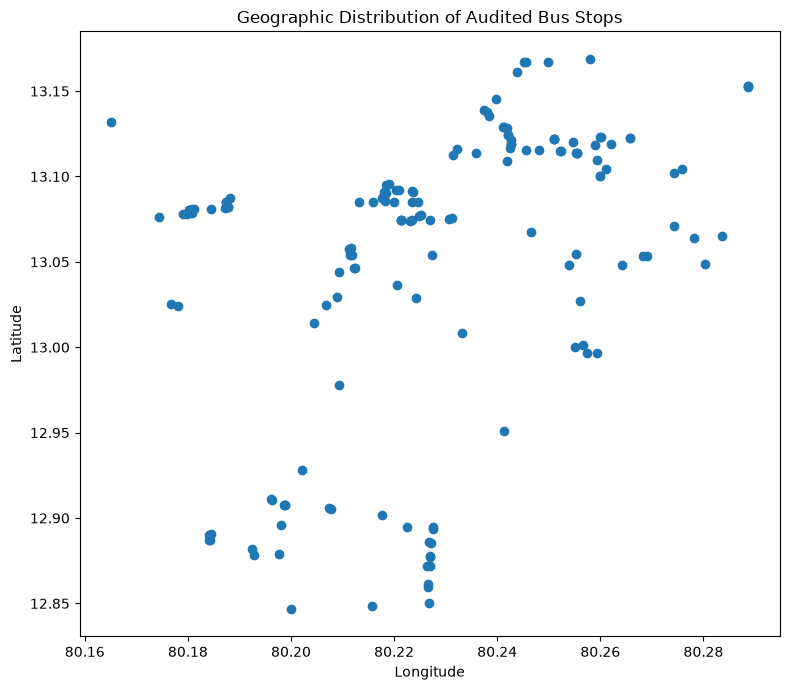


MAP-READY PRIORITY TABLE
                                          Bus Stop   Latitude  Longitude  \
16                              MKB POLICE STATION  13.122954  80.259893   
14                    M.P. தேவதாஸ் உயர்நிலைப்பள்ளி  13.118555  80.259021   
63                                        Massodhi  13.080845  80.180743   
38                                       கணேசபுரம்  13.109741  80.259329   
36                                     ஆடுத்தொட்டி  13.104621  80.261013   
177                         Semmencheri Aazhamaram  12.861523  80.226598   
33                Fire station Bus stand Vysarpadi  13.113862  80.255298   
25                                 Brindha theater  13.119239  80.242673   
151                பேசின் ரோடு இந்திரா காந்தி நகர்  13.152679  80.288633   
15                                      MKB  Nagar  13.122992  80.260177   
78                                Jj east junction  13.087480  80.188145   
150                                   நாய் கோட்ரஸ்  13.152719 

In [109]:
# ============================================================
# 10. GEOGRAPHY / SPATIAL ANALYSIS
# ============================================================


# ------------------------------------------------------------
# 10.1 IDENTIFY LATITUDE / LONGITUDE COLUMNS
# ------------------------------------------------------------

geo_cols = [
    col for col in bus_stop.columns
    if any(keyword in col.lower() for keyword in [
        "latitude",
        "longitude",
        "lat",
        "lon",
        "lng"
    ])
]

print("=" * 100)
print("GEOGRAPHIC COLUMNS")
print("=" * 100)

for col in geo_cols:
    print(col)


# ------------------------------------------------------------
# 10.2 CHECK DATA TYPES
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("DATA TYPES")
print("=" * 100)

print(bus_stop[geo_cols].dtypes)


# ------------------------------------------------------------
# 10.3 CONVERT COORDINATES TO NUMERIC
# ------------------------------------------------------------

for col in geo_cols:
    bus_stop[col] = pd.to_numeric(
        bus_stop[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# 10.4 BASIC GEOGRAPHIC COVERAGE
# ------------------------------------------------------------

# Adjust these two names if your printed column names differ
lat_col = [col for col in geo_cols if "lat" in col.lower()][0]
lon_col = [
    col for col in geo_cols
    if "lon" in col.lower() or "lng" in col.lower()
][0]

valid_coordinates = (
    bus_stop[lat_col].notna()
    & bus_stop[lon_col].notna()
)

print("\n" + "=" * 100)
print("GEOGRAPHIC COVERAGE")
print("=" * 100)

print(
    "Total audited stops:",
    len(bus_stop)
)

print(
    "Stops with valid coordinates:",
    valid_coordinates.sum()
)

print(
    "Stops without coordinates:",
    (~valid_coordinates).sum()
)

print(
    "Coordinate coverage:",
    round(valid_coordinates.mean() * 100, 1),
    "%"
)


# ------------------------------------------------------------
# 10.5 COORDINATE RANGE
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("COORDINATE RANGE")
print("=" * 100)

print("Latitude:")
print(
    "Minimum:",
    bus_stop[lat_col].min()
)

print(
    "Maximum:",
    bus_stop[lat_col].max()
)

print("\nLongitude:")

print(
    "Minimum:",
    bus_stop[lon_col].min()
)

print(
    "Maximum:",
    bus_stop[lon_col].max()
)


# ------------------------------------------------------------
# 10.6 CHECK DUPLICATE COORDINATES
# ------------------------------------------------------------

coordinate_duplicates = (
    bus_stop[
        valid_coordinates
    ]
    .duplicated(
        subset=[lat_col, lon_col],
        keep=False
    )
)

print("\n" + "=" * 100)
print("DUPLICATE COORDINATES")
print("=" * 100)

print(
    "Stops sharing duplicate coordinates:",
    coordinate_duplicates.sum()
)

print(
    "Unique coordinate pairs:",
    bus_stop[
        valid_coordinates
    ][[lat_col, lon_col]]
    .drop_duplicates()
    .shape[0]
)


# ------------------------------------------------------------
# 10.7 CREATE GEOGRAPHIC DATASET
# ------------------------------------------------------------

geography_table = bus_stop[
    valid_coordinates
].copy()

geography_table = geography_table[
    [
        stop_name_col,
        lat_col,
        lon_col
    ]
]

geography_table = geography_table.rename(columns={
    stop_name_col: "Bus Stop",
    lat_col: "Latitude",
    lon_col: "Longitude"
})

print("\n" + "=" * 100)
print("GEOGRAPHY TABLE")
print("=" * 100)

print(
    geography_table.head()
)


# ------------------------------------------------------------
# 10.8 SPATIAL DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8, 7))

plt.scatter(
    geography_table["Longitude"],
    geography_table["Latitude"]
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Audited Bus Stops")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10.9 MAP-READY PRIORITY DATA
# ------------------------------------------------------------

# Combine geography with the problem scores already created.

map_priority_table = bus_stop[
    valid_coordinates
].copy()

map_priority_table = map_priority_table[
    [
        stop_name_col,
        lat_col,
        lon_col,
        "road_interface_score",
        "safety_problem_score",
        "shelter_problem_score",
        "environment_risk_score"
    ]
].copy()

map_priority_table = map_priority_table.rename(columns={
    stop_name_col: "Bus Stop",
    lat_col: "Latitude",
    lon_col: "Longitude",
    "road_interface_score": "Road Interface Risk",
    "safety_problem_score": "Safety Risk",
    "shelter_problem_score": "Shelter Risk",
    "environment_risk_score": "Environment Risk"
})

# Overall existing infrastructure burden
map_priority_table["Overall Problem Score"] = (
    map_priority_table["Road Interface Risk"]
    + map_priority_table["Safety Risk"]
    + map_priority_table["Shelter Risk"]
    + map_priority_table["Environment Risk"]
)

map_priority_table = map_priority_table.sort_values(
    "Overall Problem Score",
    ascending=False
)

print("\n" + "=" * 100)
print("MAP-READY PRIORITY TABLE")
print("=" * 100)

print(
    map_priority_table.head(20)
)


# ------------------------------------------------------------
# 10.10 TOP GEOGRAPHIC PRIORITY STOPS
# ------------------------------------------------------------

top_geographic_priority = map_priority_table.head(20)

print("\n" + "=" * 100)
print("TOP 20 GEOGRAPHICALLY MAPPED PRIORITY STOPS")
print("=" * 100)

print(top_geographic_priority)


# ------------------------------------------------------------
# 10.11 FINAL GEOGRAPHY FINDINGS
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("GEOGRAPHY — KEY FINDINGS")
print("=" * 100)

print(
    f"Audited bus stops: {len(bus_stop)}"
)

print(
    f"Stops with valid coordinates: "
    f"{valid_coordinates.sum()} "
    f"({valid_coordinates.mean() * 100:.1f}%)"
)

print(
    f"Stops without coordinates: "
    f"{(~valid_coordinates).sum()} "
    f"({(~valid_coordinates).mean() * 100:.1f}%)"
)

print(
    f"Unique coordinate pairs: "
    f"{geography_table[['Latitude', 'Longitude']].drop_duplicates().shape[0]}"
)

print(
    f"Geographic latitude range: "
    f"{geography_table['Latitude'].min():.6f} "
    f"to "
    f"{geography_table['Latitude'].max():.6f}"
)

print(
    f"Geographic longitude range: "
    f"{geography_table['Longitude'].min():.6f} "
    f"to "
    f"{geography_table['Longitude'].max():.6f}"
)

In [110]:
# ============================================================
# 11. QUALITATIVE OBSERVATIONS
# ============================================================

# ------------------------------------------------------------
# 11.1 FIND QUALITATIVE / OBSERVATION COLUMNS
# ------------------------------------------------------------

observation_keywords = [
    "observation",
    "comment",
    "remark",
    "describe",
    "note",
    "additional",
    "issue",
    "problem",
    "suggestion"
]

observation_cols = [
    col for col in bus_stop.columns
    if any(keyword in col.lower() for keyword in observation_keywords)
]

print("=" * 100)
print("POTENTIAL QUALITATIVE OBSERVATION COLUMNS")
print("=" * 100)

for i, col in enumerate(observation_cols, start=1):
    print(f"{i}. {col}")

POTENTIAL QUALITATIVE OBSERVATION COLUMNS
1. Any other observations about this bus stop?
2. Photo of any other key observation 1 
3. Photo of any other key observation 1 _URL
4. Photo of any other key observation 2 
5. Photo of any other key observation 2 _URL
6. notes
7. waiting_capacity_problem
8. roof_problem
9. shade_problem
10. shelter_problem_score
11. night_safety_problem
12. lighting_problem
13. safety_problem_score
14. insufficient_seating_problem
15. uncomfortable_seating_problem
16. bus_visibility_problem
17. comfort_problem_score
18. road_access_problem
19. road_space_problem
20. high_kerb_problem
21. drainage_problem
22. environment_encroachment_problem
23. missing_stop_name_problem
24. poor_stop_name_problem
25. missing_route_information_problem
26. poor_route_information_problem
27. stop_name_problem
28. route_information_problem
29. information_problem_count
30. combined_problem_score


In [111]:
# ------------------------------------------------------------
# 11.2 CHECK RESPONSE COUNTS
# ------------------------------------------------------------

for col in observation_cols:

    print("\n" + "=" * 100)
    print(col)
    print("-" * 100)

    print("Non-null observations:",
          bus_stop[col].notna().sum())

    print("Unique responses:",
          bus_stop[col].nunique())

    print("\nSample observations:")

    print(
        bus_stop[col]
        .dropna()
        .astype(str)
        .head(10)
        .to_string(index=False)
    )


Any other observations about this bus stop?
----------------------------------------------------------------------------------------------------
Non-null observations: 173
Unique responses: 123

Sample observations:
        The footpath is in a really bad condition.
Bus shelters not provided in spite of repeated ...
                      People lying on the bus stop
                                           Unclean
                Poor seating space, no information
             Completely blocks pedestrian movement
A big garbage dump at the back side. Too stingy...
Nearby auto stand literally parks the autos in ...
                              Lot of encroachments
Bus bay barrigadebto be placed  and to be clean...

Photo of any other key observation 1 
----------------------------------------------------------------------------------------------------
Non-null observations: 121
Unique responses: 121

Sample observations:
                      1001087210-13_28_39.jpg
                

In [112]:
# ------------------------------------------------------------
# 11.3 SELECT THE MAIN QUALITATIVE OBSERVATION COLUMN
# ------------------------------------------------------------

# After running the previous block, replace this with the
# actual observation column from your dataset.

# Example:
# observation_col = 'Additional observations'

print("Available observation columns:")
for col in observation_cols:
    print(col)

Available observation columns:
Any other observations about this bus stop?
Photo of any other key observation 1 
Photo of any other key observation 1 _URL
Photo of any other key observation 2 
Photo of any other key observation 2 _URL
notes
waiting_capacity_problem
roof_problem
shade_problem
shelter_problem_score
night_safety_problem
lighting_problem
safety_problem_score
insufficient_seating_problem
uncomfortable_seating_problem
bus_visibility_problem
comfort_problem_score
road_access_problem
road_space_problem
high_kerb_problem
drainage_problem
environment_encroachment_problem
missing_stop_name_problem
poor_stop_name_problem
missing_route_information_problem
poor_route_information_problem
stop_name_problem
route_information_problem
information_problem_count
combined_problem_score


QUALITATIVE OBSERVATIONS — OVERVIEW
Total audited stops: 210
Stops with observations: 173
Stops without observations: 37
Observation coverage: 82.4 %
Unique observations: 123

OBSERVATION LENGTH
Average characters: 64.4
Median characters: 35.0
Longest observation: 362

ALL QUALITATIVE OBSERVATIONS


,Observation
0,The footpath is in a really bad condition.
1,Bus shelters not provided in spite of repeated...
2,People lying on the bus stop
3,Unclean
4,"Poor seating space, no information"
...,...
201,No bus stop
202,The bus stop is not used. People stand nearby ...
203,Bus stop is not used by people. People stand n...
206,The busua stop very forward from the bus stop....



QUALITATIVE THEMES


,Theme,Observations,Percentage of observations
0,Bus Stop Operations,72,41.6
1,Passenger Information,31,17.9
2,Shelter / Roof,24,13.9
3,Encroachment / Parking,23,13.3
4,Safety / Security,23,13.3
5,Pedestrian / Footpath,20,11.6
6,General Maintenance / Damage,6,3.5
7,Garbage / Cleanliness,5,2.9
8,Seating,5,2.9
9,Drainage / Waterlogging,5,2.9



OBSERVATIONS WITH MULTIPLE ISSUES
Observations mentioning 2+ issue themes: 66


,Observation,Theme Count,Pedestrian / Footpath,Encroachment / Parking,Garbage / Cleanliness,Shelter / Roof,Seating,Drainage / Waterlogging,Bus Stop Operations,Passenger Information,Safety / Security,Accessibility,General Maintenance / Damage
168,The bus stand is overall in good condition. Bu...,5,True,False,False,True,False,True,True,False,False,False,True
100,1. No proper name and sign board. 2. No shade ...,5,False,True,False,True,False,False,True,True,True,False,False
95,There is no proper signage for the bus stop he...,5,True,True,False,False,False,False,True,True,True,False,False
166,Two wheelers cross very near the pedestrians a...,4,True,False,False,False,False,False,True,True,True,False,False
96,The bus stop has no shelter nor any designated...,4,False,True,False,True,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,"The bus stop as s paver blocks on the floors, ...",2,True,False,False,False,False,False,True,False,False,False,False
177,Roof is in very bad condition. Can fly anytime...,2,False,False,False,True,False,False,False,False,False,False,True
179,The tin roof is broken,2,False,False,False,True,False,False,False,False,False,False,True
184,Buses stop in the middle of the road creating ...,2,False,False,False,False,False,False,True,False,True,False,False



TOP QUALITATIVE ISSUES


,Theme,Observations,Percentage of observations
0,Bus Stop Operations,72,41.6
1,Passenger Information,31,17.9
2,Shelter / Roof,24,13.9
3,Encroachment / Parking,23,13.3
4,Safety / Security,23,13.3
5,Pedestrian / Footpath,20,11.6
6,General Maintenance / Damage,6,3.5
7,Garbage / Cleanliness,5,2.9


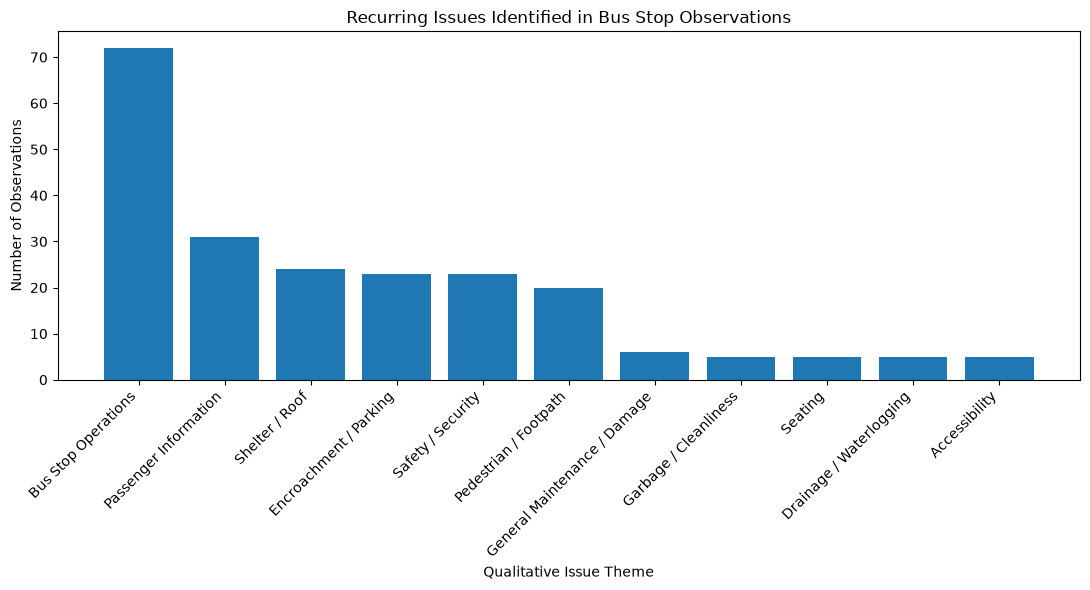

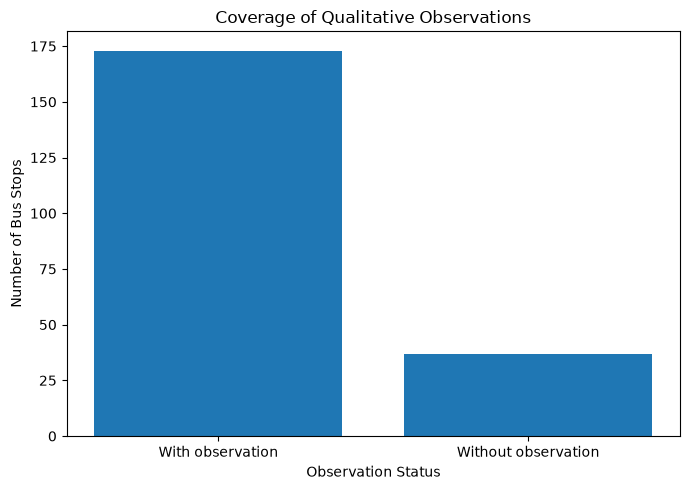


OBSERVATIONS × EXISTING PROBLEM BURDEN
Average combined problem score among stops with observations: 3.42
Average combined problem score across all stops: 3.31

HIGH-PROBLEM STOPS WITH QUALITATIVE OBSERVATIONS


,Bus Stop,Observation,Combined Problem Score
38,கணேசபுரம்,No,6
36,ஆடுத்தொட்டி,No,6
33,Fire station Bus stand Vysarpadi,No,6
16,MKB POLICE STATION,No,6
14,M.P. தேவதாஸ் உயர்நிலைப்பள்ளி,Restroom,6
177,Semmencheri Aazhamaram,Roof is in very bad condition. Can fly anytime...,6
63,Massodhi,No information about anything,6
25,Brindha theater,No,5
15,MKB Nagar,No,5
56,Tiruvanmiyur Depot _ last stop,The passengers are dropped off at different pl...,5



QUALITATIVE OBSERVATIONS — KEY FINDINGS
Qualitative observations were recorded at 173 of 210 audited stops (82.4%).
The observations contain 123 unique responses, showing substantial variation in reported issues.

Most frequently detected themes:
- Bus Stop Operations: 72 observations (41.6%)
- Passenger Information: 31 observations (17.9%)
- Shelter / Roof: 24 observations (13.9%)
- Encroachment / Parking: 23 observations (13.3%)
- Safety / Security: 23 observations (13.3%)

Observations mentioning multiple issue types: 66
Average combined problem score — stops with observations: 3.42
Average combined problem score — all audited stops: 3.31

FINAL QUALITATIVE OBSERVATION TABLE


,Bus Stop,Observation,Detected Themes,Combined Problem Score
38,கணேசபுரம்,No,,6
36,ஆடுத்தொட்டி,No,,6
33,Fire station Bus stand Vysarpadi,No,,6
16,MKB POLICE STATION,No,,6
14,M.P. தேவதாஸ் உயர்நிலைப்பள்ளி,Restroom,,6
...,...,...,...,...
131,Adayar Bsnl depo bus stop,There is no way to reach the stop safely and m...,"Passenger Information, Safety / Security",1
115,Anna University,No lights in shelter only from street light,"Shelter / Roof, Safety / Security",1
161,ICF Depot,Good,,1
188,Church park convent,Shelter is comfortable only because of the tre...,Shelter / Roof,1



TOPIC 11 — QUALITATIVE OBSERVATIONS COMPLETE

Completed:
✓ Observation coverage
✓ Observation uniqueness
✓ Observation length
✓ Recurring qualitative themes
✓ Theme frequency table
✓ Multi-issue observations
✓ Qualitative visualizations
✓ Observations linked to problem burden
✓ High-problem stops with observations
✓ Final qualitative observation table
✓ Key findings



In [113]:
# ============================================================
# 11. QUALITATIVE OBSERVATIONS — COMPLETE ANALYSIS
# ============================================================

# Main free-text observation column
observation_col = 'Any other observations about this bus stop?'

# ------------------------------------------------------------
# 11.1 BASIC OVERVIEW
# ------------------------------------------------------------

total_stops = len(bus_stop)

observations = (
    bus_stop[observation_col]
    .dropna()
    .astype("string")
    .str.strip()
)

# Remove empty responses
observations = observations[observations != ""]

print("=" * 100)
print("QUALITATIVE OBSERVATIONS — OVERVIEW")
print("=" * 100)

print("Total audited stops:", total_stops)
print("Stops with observations:", len(observations))
print(
    "Stops without observations:",
    total_stops - len(observations)
)
print(
    "Observation coverage:",
    round(len(observations) / total_stops * 100, 1),
    "%"
)
print("Unique observations:", observations.nunique())


# ------------------------------------------------------------
# 11.2 OBSERVATION LENGTH
# ------------------------------------------------------------

observation_length = observations.str.len()

print("\n" + "=" * 100)
print("OBSERVATION LENGTH")
print("=" * 100)

print("Average characters:",
      round(observation_length.mean(), 1))

print("Median characters:",
      round(observation_length.median(), 1))

print("Longest observation:",
      observation_length.max())


# ------------------------------------------------------------
# 11.3 VIEW ALL OBSERVATIONS
# ------------------------------------------------------------

observation_table = pd.DataFrame({
    "Observation": observations
})

print("\n" + "=" * 100)
print("ALL QUALITATIVE OBSERVATIONS")
print("=" * 100)

display(observation_table)


# ------------------------------------------------------------
# 11.4 CREATE BROAD THEMES
# ------------------------------------------------------------
# These themes are based on recurring infrastructure / operational
# issues visible in the observations.
#
# IMPORTANT:
# A single observation can belong to multiple themes.

text = (
    bus_stop[observation_col]
    .astype("string")
    .str.lower()
    .fillna("")
)

theme_masks = {

    "Pedestrian / Footpath":
        text.str.contains(
            r"footpath|pedestrian|walk|walking|wheelchair|movement|mobility",
            regex=True,
            na=False
        ),

    "Encroachment / Parking":
        text.str.contains(
            r"encroach|parking|parked|vendor|vendors|auto stand|autos|obstruction",
            regex=True,
            na=False
        ),

    "Garbage / Cleanliness":
        text.str.contains(
            r"garbage|waste|litter|dirty|unclean|clean|dump|rubbish",
            regex=True,
            na=False
        ),

    "Shelter / Roof":
        text.str.contains(
            r"shelter|roof|shed|shade|rain|shelter not|no shelter",
            regex=True,
            na=False
        ),

    "Seating":
        text.str.contains(
            r"seat|seating|bench|sitting",
            regex=True,
            na=False
        ),

    "Drainage / Waterlogging":
        text.str.contains(
            r"drain|drainage|waterlog|water logging|flood|stagnant|water",
            regex=True,
            na=False
        ),

    "Bus Stop Operations":
        text.str.contains(
            r"bus stop|bus bay|bus.*stop|bus.*stand|barricade|buses",
            regex=True,
            na=False
        ),

    "Passenger Information":
        text.str.contains(
            r"information|route|name|display|sign|signage|board",
            regex=True,
            na=False
        ),

    "Safety / Security":
        text.str.contains(
            r"safe|unsafe|safety|security|light|lighting|dark|traffic",
            regex=True,
            na=False
        ),

    "Accessibility":
        text.str.contains(
            r"ramp|tactile|wheelchair|accessible|accessibility|kerb|step",
            regex=True,
            na=False
        ),

    "General Maintenance / Damage":
        text.str.contains(
            r"broken|damaged|repair|maintenance|poor condition|condition",
            regex=True,
            na=False
        )
}


# ------------------------------------------------------------
# 11.5 THEME COUNTS
# ------------------------------------------------------------

theme_summary = pd.DataFrame({
    "Theme": list(theme_masks.keys()),
    "Observations": [
        mask.sum()
        for mask in theme_masks.values()
    ]
})

theme_summary["Percentage of observations"] = (
    theme_summary["Observations"]
    / len(observations)
    * 100
).round(1)

theme_summary = theme_summary.sort_values(
    "Observations",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 100)
print("QUALITATIVE THEMES")
print("=" * 100)

display(theme_summary)


# ------------------------------------------------------------
# 11.6 OBSERVATION → THEME TABLE
# ------------------------------------------------------------

qualitative_theme_table = pd.DataFrame({
    "Observation": observations
})

for theme, mask in theme_masks.items():

    qualitative_theme_table[theme] = (
        bus_stop.loc[observations.index, observation_col]
        .astype("string")
        .str.lower()
        .fillna("")
        .str.contains(
            theme_masks[theme].astype(str)
            if False else "",
            regex=False
        )
    )

# Rebuild correctly using the same masks
qualitative_theme_table = pd.DataFrame({
    "Observation": observations
})

for theme, pattern_mask in theme_masks.items():
    qualitative_theme_table[theme] = pattern_mask.loc[
        observations.index
    ].values


# ------------------------------------------------------------
# 11.7 NUMBER OF THEMES PER OBSERVATION
# ------------------------------------------------------------

theme_columns = list(theme_masks.keys())

qualitative_theme_table["Theme Count"] = (
    qualitative_theme_table[theme_columns]
    .sum(axis=1)
)

print("\n" + "=" * 100)
print("OBSERVATIONS WITH MULTIPLE ISSUES")
print("=" * 100)

multi_issue_observations = qualitative_theme_table[
    qualitative_theme_table["Theme Count"] >= 2
].sort_values(
    "Theme Count",
    ascending=False
)

print(
    "Observations mentioning 2+ issue themes:",
    len(multi_issue_observations)
)

display(
    multi_issue_observations[
        ["Observation", "Theme Count"] + theme_columns
    ]
)


# ------------------------------------------------------------
# 11.8 MOST FREQUENT THEMES
# ------------------------------------------------------------

top_themes = theme_summary.head(8)

print("\n" + "=" * 100)
print("TOP QUALITATIVE ISSUES")
print("=" * 100)

display(top_themes)


# ------------------------------------------------------------
# 11.9 VISUALIZATION — QUALITATIVE ISSUE THEMES
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.bar(
    theme_summary["Theme"],
    theme_summary["Observations"]
)

plt.xlabel("Qualitative Issue Theme")
plt.ylabel("Number of Observations")
plt.title(
    "Recurring Issues Identified in Bus Stop Observations"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11.10 OBSERVATION COVERAGE
# ------------------------------------------------------------

coverage_counts = {
    "With observation": len(observations),
    "Without observation": total_stops - len(observations)
}

plt.figure(figsize=(7, 5))

plt.bar(
    coverage_counts.keys(),
    coverage_counts.values()
)

plt.xlabel("Observation Status")
plt.ylabel("Number of Bus Stops")
plt.title(
    "Coverage of Qualitative Observations"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11.11 LINK QUALITATIVE OBSERVATIONS TO PROBLEM BURDEN
# ------------------------------------------------------------

# Use the combined problem score already created in the notebook.

qualitative_analysis = bus_stop.loc[
    observations.index,
    [
        stop_name_col,
        observation_col,
        "combined_problem_score"
    ]
].copy()

qualitative_analysis = qualitative_analysis.rename(
    columns={
        stop_name_col: "Bus Stop",
        observation_col: "Observation",
        "combined_problem_score": "Combined Problem Score"
    }
)

print("\n" + "=" * 100)
print("OBSERVATIONS × EXISTING PROBLEM BURDEN")
print("=" * 100)

print(
    "Average combined problem score among stops with observations:",
    round(
        qualitative_analysis["Combined Problem Score"].mean(),
        2
    )
)

print(
    "Average combined problem score across all stops:",
    round(
        bus_stop["combined_problem_score"].mean(),
        2
    )
)


# ------------------------------------------------------------
# 11.12 HIGHEST-PROBLEM STOPS WITH QUALITATIVE OBSERVATIONS
# ------------------------------------------------------------

high_problem_observations = qualitative_analysis.sort_values(
    "Combined Problem Score",
    ascending=False
)

print("\n" + "=" * 100)
print("HIGH-PROBLEM STOPS WITH QUALITATIVE OBSERVATIONS")
print("=" * 100)

display(
    high_problem_observations.head(20)
)


# ------------------------------------------------------------
# 11.13 CREATE FINAL QUALITATIVE DATASET
# ------------------------------------------------------------

final_qualitative_table = qualitative_analysis.copy()

# Add detected themes as readable text
def get_themes(index):

    row = qualitative_theme_table.loc[index]

    detected = [
        theme
        for theme in theme_columns
        if row[theme]
    ]

    return ", ".join(detected)


final_qualitative_table["Detected Themes"] = [
    get_themes(idx)
    for idx in qualitative_analysis.index
]

final_qualitative_table = final_qualitative_table[
    [
        "Bus Stop",
        "Observation",
        "Detected Themes",
        "Combined Problem Score"
    ]
].sort_values(
    "Combined Problem Score",
    ascending=False
)


# ------------------------------------------------------------
# 11.14 FINAL QUALITATIVE FINDINGS
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("QUALITATIVE OBSERVATIONS — KEY FINDINGS")
print("=" * 100)

print(
    f"Qualitative observations were recorded at "
    f"{len(observations)} of {total_stops} audited stops "
    f"({len(observations) / total_stops * 100:.1f}%)."
)

print(
    f"The observations contain {observations.nunique()} unique "
    f"responses, showing substantial variation in reported issues."
)

print("\nMost frequently detected themes:")

for _, row in theme_summary.head(5).iterrows():

    print(
        f"- {row['Theme']}: "
        f"{row['Observations']} observations "
        f"({row['Percentage of observations']}%)"
    )

print(
    "\nObservations mentioning multiple issue types:",
    len(multi_issue_observations)
)

print(
    "Average combined problem score — stops with observations:",
    round(
        qualitative_analysis["Combined Problem Score"].mean(),
        2
    )
)

print(
    "Average combined problem score — all audited stops:",
    round(
        bus_stop["combined_problem_score"].mean(),
        2
    )
)


# ------------------------------------------------------------
# 11.15 FINAL TABLE
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("FINAL QUALITATIVE OBSERVATION TABLE")
print("=" * 100)

display(final_qualitative_table)


# ============================================================
# TOPIC 11 COMPLETE
# ============================================================

print("\n" + "=" * 100)
print("TOPIC 11 — QUALITATIVE OBSERVATIONS COMPLETE")
print("=" * 100)

print("""
Completed:
✓ Observation coverage
✓ Observation uniqueness
✓ Observation length
✓ Recurring qualitative themes
✓ Theme frequency table
✓ Multi-issue observations
✓ Qualitative visualizations
✓ Observations linked to problem burden
✓ High-problem stops with observations
✓ Final qualitative observation table
✓ Key findings
""")

In [114]:
# ============================================================
# 12. METADATA & DATA QUALITY ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 12.1 DATASET OVERVIEW
# ------------------------------------------------------------

print("=" * 100)
print("DATASET METADATA")
print("=" * 100)

print("Rows (audited stops):", bus_stop.shape[0])
print("Columns:", bus_stop.shape[1])
print("Duplicate rows:", bus_stop.duplicated().sum())

print("\nData types:")
print(bus_stop.dtypes.value_counts())


# ------------------------------------------------------------
# 12.2 MISSING VALUES
# ------------------------------------------------------------

missing_summary = pd.DataFrame({
    "Missing Count": bus_stop.isna().sum(),
    "Missing %": (
        bus_stop.isna().mean() * 100
    ).round(1)
})

missing_summary = (
    missing_summary[
        missing_summary["Missing Count"] > 0
    ]
    .sort_values("Missing Count", ascending=False)
)

print("\n" + "=" * 100)
print("MISSING VALUES")
print("=" * 100)

display(missing_summary)


# ------------------------------------------------------------
# 12.3 COMPLETE vs INCOMPLETE RECORDS
# ------------------------------------------------------------

complete_records = bus_stop.notna().all(axis=1).sum()
incomplete_records = bus_stop.isna().any(axis=1).sum()

print("\n" + "=" * 100)
print("RECORD COMPLETENESS")
print("=" * 100)

print(
    "Completely filled records:",
    complete_records,
    f"({complete_records / len(bus_stop) * 100:.1f}%)"
)

print(
    "Records with at least one missing value:",
    incomplete_records,
    f"({incomplete_records / len(bus_stop) * 100:.1f}%)"
)


# ------------------------------------------------------------
# 12.4 IDENTIFY IDENTIFIER / LOCATION COLUMNS
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("IDENTIFIER / LOCATION COLUMNS")
print("=" * 100)

identifier_keywords = [
    "name",
    "id",
    "uuid",
    "latitude",
    "longitude",
    "lat",
    "lon",
    "location",
    "date",
    "time"
]

metadata_candidates = [
    col for col in bus_stop.columns
    if any(
        keyword in col.lower()
        for keyword in identifier_keywords
    )
]

for col in metadata_candidates:
    print(col)


# ------------------------------------------------------------
# 12.5 LATITUDE / LONGITUDE CHECK
# ------------------------------------------------------------

location_cols = [
    col for col in bus_stop.columns
    if any(
        keyword in col.lower()
        for keyword in ["latitude", "longitude", "lat", "lon"]
    )
]

print("\n" + "=" * 100)
print("LOCATION DATA")
print("=" * 100)

for col in location_cols:

    print("\n", col)

    print("Non-null:",
          bus_stop[col].notna().sum())

    print("Missing:",
          bus_stop[col].isna().sum())

    print("Unique:",
          bus_stop[col].nunique())


# ------------------------------------------------------------
# 12.6 DUPLICATE BUS STOP NAMES
# ------------------------------------------------------------

stop_name_col = (
    'Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)'
)

print("\n" + "=" * 100)
print("BUS STOP NAME DUPLICATES")
print("=" * 100)

duplicate_names = (
    bus_stop[stop_name_col]
    .value_counts()
)

duplicate_names = duplicate_names[
    duplicate_names > 1
]

print(
    "Bus stop names appearing more than once:",
    len(duplicate_names)
)

display(duplicate_names.to_frame("Audit Records"))


# ------------------------------------------------------------
# 12.7 UNIQUE VALUES / CATEGORICAL QUALITY
# ------------------------------------------------------------

categorical_columns = bus_stop.select_dtypes(
    include=["object", "string", "category"]
).columns

categorical_summary = pd.DataFrame({
    "Column": categorical_columns,
    "Unique Values": [
        bus_stop[col].nunique(dropna=True)
        for col in categorical_columns
    ],
    "Missing": [
        bus_stop[col].isna().sum()
        for col in categorical_columns
    ]
})

categorical_summary = categorical_summary.sort_values(
    "Unique Values",
    ascending=False
)

print("\n" + "=" * 100)
print("CATEGORICAL DATA QUALITY")
print("=" * 100)

display(categorical_summary)


# ------------------------------------------------------------
# 12.8 BOOLEAN / BINARY VARIABLES
# ------------------------------------------------------------

binary_columns = []

for col in bus_stop.columns:

    unique_values = (
        bus_stop[col]
        .dropna()
        .unique()
    )

    if len(unique_values) <= 2:
        binary_columns.append(col)

print("\n" + "=" * 100)
print("BINARY / LOW-CARDINALITY VARIABLES")
print("=" * 100)

print("Number of binary / low-cardinality columns:",
      len(binary_columns))

for col in binary_columns:
    print(
        f"{col} -> "
        f"{bus_stop[col].dropna().unique()}"
    )


# ------------------------------------------------------------
# 12.9 PHOTO / EVIDENCE COVERAGE
# ------------------------------------------------------------

photo_columns = [
    col for col in bus_stop.columns
    if "photo" in col.lower()
]

print("\n" + "=" * 100)
print("PHOTO / VISUAL EVIDENCE COVERAGE")
print("=" * 100)

for col in photo_columns:

    non_null = bus_stop[col].notna().sum()

    print(
        f"{col}: "
        f"{non_null} records "
        f"({non_null / len(bus_stop) * 100:.1f}%)"
    )


# ------------------------------------------------------------
# 12.10 QUALITATIVE OBSERVATION COVERAGE
# ------------------------------------------------------------

observation_col = (
    'Any other observations about this bus stop?'
)

observation_count = (
    bus_stop[observation_col]
    .notna()
    .sum()
)

print("\n" + "=" * 100)
print("QUALITATIVE DATA COVERAGE")
print("=" * 100)

print(
    "Stops with additional observations:",
    observation_count,
    f"({observation_count / len(bus_stop) * 100:.1f}%)"
)

print(
    "Stops without additional observations:",
    len(bus_stop) - observation_count,
    f"({(len(bus_stop) - observation_count) / len(bus_stop) * 100:.1f}%)"
)


# ------------------------------------------------------------
# 12.11 CHECK FOR CONSTANT COLUMNS
# ------------------------------------------------------------

constant_columns = [
    col for col in bus_stop.columns
    if bus_stop[col].nunique(dropna=False) <= 1
]

print("\n" + "=" * 100)
print("CONSTANT COLUMNS")
print("=" * 100)

print(
    "Columns containing only one value:",
    len(constant_columns)
)

for col in constant_columns:
    print(
        f"{col} -> "
        f"{bus_stop[col].drop_duplicates().tolist()}"
    )


# ------------------------------------------------------------
# 12.12 CHECK DERIVED ANALYSIS COLUMNS
# ------------------------------------------------------------

derived_columns = [
    "waiting_capacity_problem",
    "roof_problem",
    "shade_problem",
    "shelter_problem_score",
    "night_safety_problem",
    "lighting_problem",
    "safety_problem_score",
    "road_access_problem",
    "road_space_problem",
    "high_kerb_problem",
    "road_interface_score",
    "drainage_problem",
    "environment_encroachment_problem",
    "environment_risk_score",
    "insufficient_seating_problem",
    "uncomfortable_seating_problem",
    "bus_visibility_problem",
    "comfort_problem_score",
    "missing_stop_name_problem",
    "missing_route_information_problem",
    "poor_stop_name_problem",
    "poor_route_information_problem",
    "stop_name_problem",
    "route_information_problem",
    "information_problem_count",
    "combined_problem_score"
]

existing_derived_columns = [
    col for col in derived_columns
    if col in bus_stop.columns
]

print("\n" + "=" * 100)
print("DERIVED ANALYSIS VARIABLES")
print("=" * 100)

print(
    "Derived variables currently present:",
    len(existing_derived_columns)
)

for col in existing_derived_columns:
    print(col)


# ------------------------------------------------------------
# 12.13 FINAL DATA QUALITY SCORECARD
# ------------------------------------------------------------

metadata_scorecard = pd.DataFrame({
    "Metric": [
        "Audited bus stops",
        "Dataset columns",
        "Duplicate rows",
        "Records with missing values",
        "Records with additional observations",
        "Columns with constant values",
        "Location-related columns",
        "Photo/evidence columns"
    ],
    "Value": [
        len(bus_stop),
        bus_stop.shape[1],
        bus_stop.duplicated().sum(),
        incomplete_records,
        observation_count,
        len(constant_columns),
        len(location_cols),
        len(photo_columns)
    ]
})

print("\n" + "=" * 100)
print("FINAL METADATA SCORECARD")
print("=" * 100)

display(metadata_scorecard)


# ------------------------------------------------------------
# 12.14 FINAL PROJECT METADATA FINDINGS
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("METADATA & DATA QUALITY — KEY FINDINGS")
print("=" * 100)

print(
    f"Dataset contains {len(bus_stop)} audited bus stops "
    f"and {bus_stop.shape[1]} columns."
)

print(
    f"{bus_stop.duplicated().sum()} completely duplicated rows "
    f"were identified."
)

print(
    f"{incomplete_records} records contain at least one missing value "
    f"({incomplete_records / len(bus_stop) * 100:.1f}%)."
)

print(
    f"{observation_count} stops contain additional qualitative "
    f"observations ({observation_count / len(bus_stop) * 100:.1f}%)."
)

print(
    f"{len(photo_columns)} photo/evidence-related columns "
    f"are present in the dataset."
)

print(
    f"{len(location_cols)} location-related columns "
    f"were identified."
)

print(
    f"{len(constant_columns)} constant columns were identified."
)


# ============================================================
# TOPIC 12 COMPLETE
# ============================================================

print("\n" + "=" * 100)
print("TOPIC 12 — METADATA & DATA QUALITY COMPLETE")
print("=" * 100)

print("""
Completed:
✓ Dataset structure
✓ Record completeness
✓ Missing-value analysis
✓ Duplicate check
✓ Identifier/location fields
✓ Bus-stop name duplication
✓ Categorical data quality
✓ Binary/low-cardinality variables
✓ Photo/evidence coverage
✓ Qualitative observation coverage
✓ Constant-column detection
✓ Derived analysis variables
✓ Final metadata scorecard
✓ Key data-quality findings

ALL 12 TOPICS ARE NOW ANALYZED.
""")

DATASET METADATA
Rows (audited stops): 210
Columns: 120
Duplicate rows: 0

Data types:
str        42
int64      36
bool       19
float64    13
string      5
boolean     5
Name: count, dtype: int64

MISSING VALUES


,Missing Count,Missing %
Check this box if the bus stop's kerb is higher than 15cms or has steps to access,210,100.0
How is the bus stop positioned relative to the road?,210,100.0
Relationship between Bus Stop and Pedestrians,210,100.0
_validation_status,210,100.0
notes,210,100.0
tags,210,100.0
How far away from the kerb/Bus stop platform does the bus stop?,210,100.0
high_kerb_problem,210,100.0
"If Location field is not working, please enter coordinates from google maps or paste the location URL",163,77.6
Is the space behind the bus shelter usable?,157,74.8



RECORD COMPLETENESS
Completely filled records: 0 (0.0%)
Records with at least one missing value: 210 (100.0%)

IDENTIFIER / LOCATION COLUMNS
Date and Time
Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)
Survey Location
_Survey Location_latitude
_Survey Location_longitude
_Survey Location_altitude
_Survey Location_precision
If Location field is not working, please enter coordinates from google maps or paste the location URL
How is the bus stop positioned relative to the road?
How is the bus stop positioned relative to the road?/Set back from the road – against a wall, compound, or building edge
How is the bus stop positioned relative to the road?/On the road edge / footpath edge – directly adjacent to traffic
How is the bus stop positioned relative to the road?/The road/footpath is too narrow 
Relationship between Bus Stop and Pedestrians
Where do buses typically stop? /Away from the bus stop – buses stop before or beyond the sh

,Audit Records
"Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)",
[surveyor name removed],3
Moolakadai bus stand,2
Fire station Bus stand Vysarpadi,2
Massodhi,2
Church road,2
Thirunagar (towards Arumbakkam),2
மாத்தூர்,2
முராரி மருத்துவமனை,2
Perumbakkam no name,2



CATEGORICAL DATA QUALITY


,Column,Unique Values,Missing
0,start,210,0
1,end,210,0
40,meta/rootUuid,210,0
37,submission_time,210,0
36,uuid,210,0
29,Photo of Bus Stop Front_URL,210,0
28,Photo of Bus Stop Front,210,0
2,Date and Time,201,0
3,Name of the Bus Stop (as displayed on the shel...,193,0
31,Photo of Bus Stop from Side _URL,172,38



BINARY / LOW-CARDINALITY VARIABLES
Number of binary / low-cardinality columns: 63
How is the bus stop positioned relative to the road? -> []
How is the bus stop positioned relative to the road?/Set back from the road – against a wall, compound, or building edge -> [0 1]
How is the bus stop positioned relative to the road?/On the road edge / footpath edge – directly adjacent to traffic -> [1 0]
How is the bus stop positioned relative to the road?/The road/footpath is too narrow  -> [0 1]
Relationship between Bus Stop and Pedestrians -> []
Is there space behind the bus shelter for pedestrians to walk/wheelchair to move freely? -> [0 1]
Is there space between the bus shelter and the road for pedestrians to walk/wheelchair to move freely?  -> [0 1]
Can pedestrians/wheelchair users move past the bus stop on the footpath, without having to step down on the road?  -> [0 1]
Where do buses typically stop? /At the bus stop – buses pull up to the shelter/marked stop -> [0 1]
Where do buses typic

,Metric,Value
0,Audited bus stops,210
1,Dataset columns,120
2,Duplicate rows,0
3,Records with missing values,210
4,Records with additional observations,173
5,Columns with constant values,15
6,Location-related columns,10
7,Photo/evidence columns,8



METADATA & DATA QUALITY — KEY FINDINGS
Dataset contains 210 audited bus stops and 120 columns.
0 completely duplicated rows were identified.
210 records contain at least one missing value (100.0%).
173 stops contain additional qualitative observations (82.4%).
8 photo/evidence-related columns are present in the dataset.
10 location-related columns were identified.
15 constant columns were identified.

TOPIC 12 — METADATA & DATA QUALITY COMPLETE

Completed:
✓ Dataset structure
✓ Record completeness
✓ Missing-value analysis
✓ Duplicate check
✓ Identifier/location fields
✓ Bus-stop name duplication
✓ Categorical data quality
✓ Binary/low-cardinality variables
✓ Photo/evidence coverage
✓ Qualitative observation coverage
✓ Constant-column detection
✓ Derived analysis variables
✓ Final metadata scorecard
✓ Key data-quality findings

ALL 12 TOPICS ARE NOW ANALYZED.



Index(['\_Survey Location\_latitude', '\_Survey Location\_longitude',        'How is the bus stop positioned relative to the road?',        'How is the bus stop positioned relative to the road?/Set back from the road – against a wall, compound, or building edge',        'How is the bus stop positioned relative to the road?/On the road edge / footpath edge – directly adjacent to traffic',        'How is the bus stop positioned relative to the road?/The road/footpath is too narrow ',        'Relationship between Bus Stop and Pedestrians',        'How far away from the kerb/Bus stop platform does the bus stop?',        'latitude', 'longitude'],       dtype='str') 

start                                                                                                         0 end                                                                                                           0 Date and Time                                                                                                 0 Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)     0 Survey Location                                                                                              56                                                                                                              .. source\_form                                                                                                   0 latitude                                                                                                      1 longitude                                                                                                     1 coordinate\_source                                                                                             1 location\_flag                                                                                                 0 Length: 85, dtype: int64

\<class 'pandas.DataFrame'> RangeIndex: 210 entries, 0 to 209 Data columns (total 85 columns):  #   Column                                                                                                                                              Non-Null Count  Dtype   ---  ------                                                                                                                                              --------------  -----    0   start                                                                                                                                               210 non-null    str      1   end                                                                                                                                                 210 non-null    str      2   Date and Time                                                                                                                                       210 non-null    str      3   Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)                                           210 non-null    str      4   Survey Location                                                                                                                                     154 non-null    str      5   \_Survey Location\_latitude                                                                                                                           154 non-null    float64  6   \_Survey Location\_longitude                                                                                                                          154 non-null    float64  7   \_Survey Location\_altitude                                                                                                                           154 non-null    float64  8   \_Survey Location\_precision                                                                                                                          154 non-null    float64  9   If Location field is not working, please enter coordinates from google maps or paste the location URL                                               47 non-null     str      10  Type of Bus Stop                                                                                                                                    210 non-null    str      11  Condition of Bus Shelter                                                                                                                            179 non-null    str      12  How is the bus stop positioned relative to the road?                                                                                                210 non-null    str      13  How is the bus stop positioned relative to the road?/Set back from the road – against a wall, compound, or building edge                            210 non-null    int64    14  How is the bus stop positioned relative to the road?/On the road edge / footpath edge – directly adjacent to traffic                                210 non-null    int64    15  How is the bus stop positioned relative to the road?/The road/footpath is too narrow                                                                210 non-null    int64    16  Relationship between Bus Stop and Pedestrians                                                                                                       0 non-null      float64  17  Is there space behind the bus shelter for pedestrians to walk/wheelchair to move freely?                                                            210 non-null    str      18  Is there space between the bus shelter and the road for pedestrians to walk/wheelchair to move freely?                                              210 non-null    str      19  Can pedestrians/wheelchair users move past the bus stop on the footpath, without having to step down on the road?                                   210 non-null    str    

...

 83  coordinate\_source                                                                                                                                   209 non-null    str      84  location\_flag                                                                                                                                       210 non-null    str     dtypes: float64(11), int64(24), str(50) memory usage: 139.6 KB 

*Output is truncated. View as a* [*scrollable element*](command\:cellOutput.enableScrolling?fdf4fd8c-f553-4aaa-bfee-3a961067ee7f) *or open in a* [*text editor*](command\:workbench.action.openLargeOutput?fdf4fd8c-f553-4aaa-bfee-3a961067ee7f)*. Adjust cell output* [*settings*](command\:workbench.action.openSettings?%5B%22%40tag%3AnotebookOutputLayout%22%5D)*...*

Index(['start', 'end', 'Date and Time',        'Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)',        'Survey Location', '\_Survey Location\_latitude',        '\_Survey Location\_longitude', '\_Survey Location\_altitude',        '\_Survey Location\_precision',        'If Location field is not working, please enter coordinates from google maps or paste the location URL',        'Type of Bus Stop', 'Condition of Bus Shelter',        'How is the bus stop positioned relative to the road?',        'How is the bus stop positioned relative to the road?/Set back from the road – against a wall, compound, or building edge',        'How is the bus stop positioned relative to the road?/On the road edge / footpath edge – directly adjacent to traffic',        'How is the bus stop positioned relative to the road?/The road/footpath is too narrow ',        'Relationship between Bus Stop and Pedestrians',        'Is there space behind the bus shelter for pedestrians to walk/wheelchair to move freely?',        'Is there space between the bus shelter and the road for pedestrians to walk/wheelchair to move freely? ',        'Can pedestrians/wheelchair users move past the bus stop on the footpath, without having to step down on the road? ',        'Is the space behind the bus shelter usable?',        'How many bus shelters are placed close to each other?',        'Where do buses typically stop? ',        'Where do buses typically stop? /At the bus stop – buses pull up to the shelter/marked stop',        'Where do buses typically stop? /Away from the bus stop – buses stop before or beyond the shelter/marked location',        'Where do buses typically stop? /Bus stop not clearly marked',        'Where do buses typically stop? /Unsure / not observed',        'How far away from the kerb/Bus stop platform does the bus stop?',        'Tick all access features present at this bus stop',        'Tick all access features present at this bus stop/Footpath available to reach the bus stop from both directions',

...

       'Photo of any other key observation 2 \_URL', 'id', 'uuid',        'submission\_time', '\_validation\_status', 'notes', 'status', 'version',        'tags', 'meta/rootUuid', 'index', 'city', 'source\_form', 'latitude',        'longitude', 'coordinate\_source', 'location\_flag'],       dtype='str')

*Output is truncated. View as a* [*scrollable element*](command\:cellOutput.enableScrolling?fda48db6-8abf-4930-999c-dd6e49912da6) *or open in a* [*text editor*](command\:workbench.action.openLargeOutput?fda48db6-8abf-4930-999c-dd6e49912da6)*. Adjust cell output* [*settings*](command\:workbench.action.openSettings?%5B%22%40tag%3AnotebookOutputLayout%22%5D)*...*

(210, 85)

|   |
| - |
|   |
|   |
|   |
|   |
|   |
|   |

Total audited bus stops: 210  ====================================================================== Space behind shelter Is there space behind the bus shelter for pedestrians to walk/wheelchair to move freely? No     157 Yes     53 Name: count, dtype: int64  ====================================================================== Space between shelter and road Is there space between the bus shelter and the road for pedestrians to walk/wheelchair to move freely?  No     150 Yes     60 Name: count, dtype: int64  ====================================================================== Pass without stepping onto road Can pedestrians/wheelchair users move past the bus stop on the footpath, without having to step down on the road?  No     155 Yes     55 Name: count, dtype: int64  ====================================================================== Footpath from both directions

...

High kerb / steps Check this box if the bus stop's kerb is higher than 15cms or has steps to access  NaN    210 Name: count, dtype: int64 

*Output is truncated. View as a* [*scrollable element*](command\:cellOutput.enableScrolling?d79c2594-4409-46b2-834f-56791ec90eac) *or open in a* [*text editor*](command\:workbench.action.openLargeOutput?d79c2594-4409-46b2-834f-56791ec90eac)*. Adjust cell output* [*settings*](command\:workbench.action.openSettings?%5B%22%40tag%3AnotebookOutputLayout%22%5D)*...*

| **IssueYesNoYes %No %** |                                 |     |     |      |      |
| ----------------------- | ------------------------------- | --- | --- | ---- | ---- |
| 0                       | Space behind shelter            | 53  | 157 | 25.2 | 74.8 |
| 1                       | Space between shelter and road  | 60  | 150 | 28.6 | 71.4 |
| 2                       | Pass without stepping onto road | 55  | 155 | 26.2 | 73.8 |
| 3                       | Footpath from both directions   | 103 | 107 | 49.0 | 51.0 |
| 4                       | Footpath free of encroachment   | 66  | 144 | 31.4 | 68.6 |
| 5                       | Wheelchair ramp                 | 32  | 178 | 15.2 | 84.8 |
| 6                       | Ramp usable                     | 20  | 190 | 9.5  | 90.5 |
| 7                       | Tactile paving                  | 10  | 200 | 4.8  | 95.2 |
| 8                       | Pedestrian crossing             | 54  | 156 | 25.7 | 74.3 |

Wheelchair ramp: Tick all access features present at this bus stop/Ramp for wheelchair users to access the bus stop 0    178 1     32 Name: count, dtype: int64 

Stops with ramp: 32 Stops with usable ramp among ramp stops: 14 

| **Tick all access features present at this bus stop/Ramp is in usable condition (not too steep, not broken, nor blocked)01All** |     |    |     |
| ------------------------------------------------------------------------------------------------------------------------------- | --- | -- | --- |
| **Tick all access features present at this bus stop/Ramp for wheelchair users to access the bus stop**                          |     |    |     |
| 0                                                                                                                               | 172 | 6  | 178 |
| 1                                                                                                                               | 18  | 14 | 32  |
| All                                                                                                                             | 190 | 20 | 210 |

| **Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)Tick all access features present at this bus stop/Ramp for wheelchair users to access the bus stopTick all access features present at this bus stop/Ramp is in usable condition (not too steep, not broken, nor blocked)** |                        |   |   |
| ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------- | - | - |
| 2                                                                                                                                                                                                                                                                                                                                     | Ambedkar play ground   | 0 | 1 |
| 18                                                                                                                                                                                                                                                                                                                                    | Moolakadai bus stand   | 0 | 1 |
| 36                                                                                                                                                                                                                                                                                                                                    | ஆடுத்தொட்டி            | 0 | 1 |
| 104                                                                                                                                                                                                                                                                                                                                   | Perungudi IGP          | 0 | 1 |
| 132                                                                                                                                                                                                                                                                                                                                   | Shastri Nagar bus stop | 0 | 1 |
| 147                                                                                                                                                                                                                                                                                                                                   | பெல்ஸ் ரோடு            | 0 | 1 |

Practically accessible stops: 0 Percentage: 0.0 % 

 \==================================================================================================== COLUMN 37 Is the bus stop area free of encroachments? ----------------------------------------------------------------------------------------------------                                                     Count  Percentage Is the bus stop area free of encroachments?                           Partially encroached – e.g., vendors, parked tw\...    100        47.6  Yes – fully accessible, no obstructions               86        41.0 Heavily encroached – the stop is largely unusab...     24        11.4  ==================================================================================================== COLUMN 38 Is there evidence of water-logging or poor drainage around the stop? ----------------------------------------------------------------------------------------------------                                                     Count  Percentage Is there evidence of water-logging or poor drai...                    No – area appears well-drained                        120        57.1 Yes – signs of standing water, algae, or draina...     57        27.1 Unsure                                                 33        15.7  ==================================================================================================== COLUMN 39  How safe does this bus stop feel, particularly at night? ----------------------------------------------------------------------------------------------------

...

Yes – route list is prominently displayed and a...     57        27.1 Yes – but information seems outdated or unreliable     37        17.6 NaN                                                    29        13.8 Yes – but information is unclear, faded, or par...     14         6.7 

*Output is truncated. View as a* [*scrollable element*](command\:cellOutput.enableScrolling?e3c702fd-6feb-4905-a321-8b882f0e982b) *or open in a* [*text editor*](command\:workbench.action.openLargeOutput?e3c702fd-6feb-4905-a321-8b882f0e982b)*. Adjust cell output* [*settings*](command\:workbench.action.openSettings?%5B%22%40tag%3AnotebookOutputLayout%22%5D)*...*

    Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)  \ 2                                 Ambedkar play ground                                                           10                                Pallikarnai Bus Stop                                                           16                                  MKB POLICE STATION                                                           49              Panchayat Union Office Shollinganallur                                                           97                     Thirunagar (towards Arumbakkam)                                                           154                                         R R Colony                                                           168                                           Sakhi JV                                                           192                                            T.Nagar                                                           195                  Panagal maligai ( towards Guindy)                                                           196                                 Vivekanandar House                                                           202                T.N.H.B Flats (towards ashok nager)                                                           203          New Boag road bus stop ( towards T.nagar)                                                           206                                     Saidapet court                                                           209                                       Pandi pazzar                                                                   Is bus route information displayed at the stop?   2    Yes – but information is unclear, faded, or pa...   10   Yes – but information is unclear, faded, or pa...   16   Yes – but information is unclear, faded, or pa...   49   Yes – but information is unclear, faded, or pa...   97   Yes – but information is unclear, faded, or pa...   154  Yes – but information is unclear, faded, or pa...   168  Yes – but information is unclear, faded, or pa...   192  Yes – but information is unclear, faded, or pa...  

...

202  Yes – but information is unclear, faded, or pa...   203  Yes – but information is unclear, faded, or pa...   206  Yes – but information is unclear, faded, or pa...   209  Yes – but information is unclear, faded, or pa...   

*Output is truncated. View as a* [*scrollable element*](command\:cellOutput.enableScrolling?02b14435-1f6b-4c77-a62a-649db154f3d1) *or open in a* [*text editor*](command\:workbench.action.openLargeOutput?02b14435-1f6b-4c77-a62a-649db154f3d1)*. Adjust cell output* [*settings*](command\:workbench.action.openSettings?%5B%22%40tag%3AnotebookOutputLayout%22%5D)*...*

| **CountPercentage**                                                              |     |      |
| -------------------------------------------------------------------------------- | --- | ---- |
| Seating / bench                                                                  | 167 | 79.5 |
| Dustbin / waste bin                                                              | 70  | 33.3 |
| Sufficient seating for the number of people typically waiting                    | 60  | 28.6 |
| Digital information boards with real time arrival information and service alerts | 37  | 17.6 |
| Drinking water (tap or dispenser)                                                | 9   | 4.3  |
| CCTV camera                                                                      | 5   | 2.4  |
| Public toilet nearby (within eyesight)                                           | 3   | 1.4  |

Tick all amenities present at this bus stop/Sufficient seating for the number of people typically waiting 0    150 1     60 Name: count, dtype: int64  Tick all amenities present at this bus stop/Sufficient seating for the number of people typically waiting 0    71.4 1    28.6 Name: proportion, dtype: float64 

 \========================================================================================== Waiting capacity  Is the bus stop big enough for the number of people who typically wait here? ------------------------------------------------------------------------------------------                                                     Count  Percentage  Is the bus stop big enough for the number of p...                    Yes – adequate space for passengers                    96        45.7  No – overcrowded or high number of people stan...     73        34.8 NaN                                                    31        14.8 Unsure                                                 10         4.8  ========================================================================================== Roof Does the bus stop have a roof that shelters people from rain? ------------------------------------------------------------------------------------------                                                     Count  Percentage Does the bus stop have a roof that shelters peo...                    Yes – roof is intact and effective                     95        45.2 Yes – but the roof is inadequate (too tall, too...     62        29.5 NaN                                                    31        14.8 No – The roof is too damaged or broken to provi...     22        10.5  ========================================================================================== Shade

...

Yes – sufficient shade from the bus shelter            61        29.0 Yes - from both bus shelter AND trees                  33        15.7 No – exposed to full sun                               30        14.3 Yes - sufficient shade from surrounding trees          15         7.1 

*Output is truncated. View as a* [*scrollable element*](command\:cellOutput.enableScrolling?35bfd765-c671-45e0-9c7c-8ec192b97eb5) *or open in a* [*text editor*](command\:workbench.action.openLargeOutput?35bfd765-c671-45e0-9c7c-8ec192b97eb5)*. Adjust cell output* [*settings*](command\:workbench.action.openSettings?%5B%22%40tag%3AnotebookOutputLayout%22%5D)*...*

Waiting capacity:  Is the bus stop big enough for the number of people who typically wait here? Yes – adequate space for passengers                               96 No – overcrowded or high number of people standing on the road    73 \<NA>                                                              31 Unsure                                                            10 Name: count, dtype: Int64  Roof: Does the bus stop have a roof that shelters people from rain? Yes – roof is intact and effective                                                   95 Yes – but the roof is inadequate (too tall, too small, gaps, or partial coverage)    62 \<NA>                                                                                 31 No – The roof is too damaged or broken to provide shelter                            22 Name: count, dtype: Int64  Shade: Is there adequate shade during the day for people waiting? Partial – some shade but insufficient            71 Yes – sufficient shade from the bus shelter      61 Yes - from both bus shelter AND trees            33 No – exposed to full sun                         30 Yes - sufficient shade from surrounding trees    15 Name: count, dtype: Int64 

Waiting capacity problems: 0 Roof problems: 22 Shade problems: 101 

\<StringArray> [                                                        'Unsure',                             'Yes – adequate space for passengers',  'No – overcrowded or high number of people standing on the road'] Length: 3, dtype: string  ROOF: \<StringArray> ['Yes – but the roof is inadequate (too tall, too small, gaps, or partial coverage)',                                                 'Yes – roof is intact and effective',                          'No – The roof is too damaged or broken to provide shelter'] Length: 3, dtype: string  SHADE: \<StringArray> [        'Partial – some shade but insufficient',                       'No – exposed to full sun',  'Yes - sufficient shade from surrounding trees',          'Yes - from both bus shelter AND trees',    'Yes – sufficient shade from the bus shelter'] Length: 5, dtype: string 

shelter\_problem\_score 0    104 1     89 2     17 Name: count, dtype: int64 

shelter\_problem\_score 0    49.5 1    42.4 2     8.1 Name: proportion, dtype: float64 

Critical shelter stops: 0 

| **Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)Is the bus stop big enough for the number of people who typically wait here?Does the bus stop have a roof that shelters people from rain?Is there adequate shade during the day for people waiting?shelter\_problem\_score** |
| --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |

High-priority shelter stops: 17 

| **Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)Is the bus stop big enough for the number of people who typically wait here?Does the bus stop have a roof that shelters people from rain?Is there adequate shade during the day for people waiting?shelter\_problem\_score** |                                                   |                                                   |                                                   |                                       |   |
| --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------- | ------------------------------------------------- | ------------------------------------------------- | ------------------------------------- | - |
| 14                                                                                                                                                                                                                                                                                                                                      | M.P. தேவதாஸ் உயர்நிலைப்பள்ளி                      | Yes – adequate space for passengers               | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 16                                                                                                                                                                                                                                                                                                                                      | MKB POLICE STATION                                | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 25                                                                                                                                                                                                                                                                                                                                      | Brindha theater                                   | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 26                                                                                                                                                                                                                                                                                                                                      | Brindha theatre moolakadai                        | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 30                                                                                                                                                                                                                                                                                                                                      | Vadivudaiamman Kovil Perambur                     | Yes – adequate space for passengers               | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 33                                                                                                                                                                                                                                                                                                                                      | Fire station Bus stand Vysarpadi                  | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 36                                                                                                                                                                                                                                                                                                                                      | ஆடுத்தொட்டி                                       | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 38                                                                                                                                                                                                                                                                                                                                      | கணேசபுரம்                                         | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 63                                                                                                                                                                                                                                                                                                                                      | Massodhi                                          | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 133                                                                                                                                                                                                                                                                                                                                     | Ottiyambakkam Main Road towards Medavakkam        | Unsure                                            | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 149                                                                                                                                                                                                                                                                                                                                     | ரயில்வே காலனி                                     | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 150                                                                                                                                                                                                                                                                                                                                     | நாய் கோட்ரஸ்                                      | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 165                                                                                                                                                                                                                                                                                                                                     | Meersahipet Market                                | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 177                                                                                                                                                                                                                                                                                                                                     | Semmencheri Aazhamaram                            | Yes – adequate space for passengers               | No – The roof is too damaged or broken to prov... | No – exposed to full sun              | 2 |
| 179                                                                                                                                                                                                                                                                                                                                     | Kumaran Nagar Semmencheri                         | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 186                                                                                                                                                                                                                                                                                                                                     | Semmencheri Aazhamaram                            | Yes – adequate space for passengers               | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 193                                                                                                                                                                                                                                                                                                                                     | Todd hunder nagar (or) Veterinary hospital (to... | Yes – adequate space for passengers               | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |

| **Bus StopWaiting CapacityRoofShadeShelter Problem Score** |                                                   |                                                   |                                                   |                                       |   |
| ---------------------------------------------------------- | ------------------------------------------------- | ------------------------------------------------- | ------------------------------------------------- | ------------------------------------- | - |
| 14                                                         | M.P. தேவதாஸ் உயர்நிலைப்பள்ளி                      | Yes – adequate space for passengers               | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 16                                                         | MKB POLICE STATION                                | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 25                                                         | Brindha theater                                   | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 26                                                         | Brindha theatre moolakadai                        | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 30                                                         | Vadivudaiamman Kovil Perambur                     | Yes – adequate space for passengers               | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 33                                                         | Fire station Bus stand Vysarpadi                  | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 36                                                         | ஆடுத்தொட்டி                                       | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 38                                                         | கணேசபுரம்                                         | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 63                                                         | Massodhi                                          | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 133                                                        | Ottiyambakkam Main Road towards Medavakkam        | Unsure                                            | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 149                                                        | ரயில்வே காலனி                                     | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 150                                                        | நாய் கோட்ரஸ்                                      | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 165                                                        | Meersahipet Market                                | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 177                                                        | Semmencheri Aazhamaram                            | Yes – adequate space for passengers               | No – The roof is too damaged or broken to prov... | No – exposed to full sun              | 2 |
| 179                                                        | Kumaran Nagar Semmencheri                         | No – overcrowded or high number of people stan... | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 186                                                        | Semmencheri Aazhamaram                            | Yes – adequate space for passengers               | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |
| 193                                                        | Todd hunder nagar (or) Veterinary hospital (to... | Yes – adequate space for passengers               | No – The roof is too damaged or broken to prov... | Partial – some shade but insufficient | 2 |

| **waiting\_capacity\_problemroof\_problemshade\_problemStops** |       |       |       |     |
| -------------------------------------------------------------- | ----- | ----- | ----- | --- |
| 0                                                              | False | False | False | 104 |
| 1                                                              | False | False | True  | 84  |
| 3                                                              | False | True  | True  | 17  |
| 2                                                              | False | True  | False | 5   |

\========== SHELTER FINDINGS ========== Waiting capacity problems: 0 Roof problems: 22 Shade problems: 101 Stops with 2+ shelter problems: 17 Stops with all 3 shelter problems: 0 

Waiting capacity problem %: 0.0 Roof problem %: 12.3 Shade problem %: 48.1 

NIGHT SAFETY  How safe does this bus stop feel, particularly at night? Safe – well-lit, visible, and active surroundings                           85 Somewhat safe – some concerns (e.g., poor visibility, isolated location)    73 Unsafe – poorly lit, isolated, or has a history of feeling threatening      35 Unable to assess (audit done only in daytime)                               17 Name: count, dtype: Int64  LIGHTING Is there adequate lighting at the bus stop during the night? Yes – lit by nearby street lights, shop fronts, or advertisement boards    66 Yes – the bus shelter itself has a working light                           42 No – inadequate or no lighting at all                                      37 Unsure / Not observed                                                      33 Partially – some light but insufficient                                    32 Name: count, dtype: Int64 

\========== NIGHT SAFETY ========== 

| **CountPercentage**                                                      |    |      |
| ------------------------------------------------------------------------ | -- | ---- |
| **How safe does this bus stop feel, particularly at night?**             |    |      |
| Safe – well-lit, visible, and active surroundings                        | 85 | 40.5 |
| Somewhat safe – some concerns (e.g., poor visibility, isolated location) | 73 | 34.8 |
| Unsafe – poorly lit, isolated, or has a history of feeling threatening   | 35 | 16.7 |
| Unable to assess (audit done only in daytime)                            | 17 | 8.1  |

\========== LIGHTING ========== 

| **CountPercentage**                                                     |    |      |
| ----------------------------------------------------------------------- | -- | ---- |
| **Is there adequate lighting at the bus stop during the night?**        |    |      |
| Yes – lit by nearby street lights, shop fronts, or advertisement boards | 66 | 31.4 |
| Yes – the bus shelter itself has a working light                        | 42 | 20.0 |
| No – inadequate or no lighting at all                                   | 37 | 17.6 |
| Unsure / Not observed                                                   | 33 | 15.7 |
| Partially – some light but insufficient                                 | 32 | 15.2 |

Night safety categories: \<StringArray> [                           'Unable to assess (audit done only in daytime)',                         'Safe – well-lit, visible, and active surroundings',  'Somewhat safe – some concerns (e.g., poor visibility, isolated location)',    'Unsafe – poorly lit, isolated, or has a history of feeling threatening'] Length: 4, dtype: string  Lighting categories: \<StringArray> [                                                  'Unsure / Not observed',  'Yes – lit by nearby street lights, shop fronts, or advertisement boards',                                  'Partially – some light but insufficient',                                    'No – inadequate or no lighting at all',                         'Yes – the bus shelter itself has a working light'] Length: 5, dtype: string 

safety\_problem\_score 0    210 Name: count, dtype: int64 

Stops with both night-safety and lighting problems: 0 

| **Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)How safe does this bus stop feel, particularly at night?Is there adequate lighting at the bus stop during the night?safety\_problem\_score** |
| ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |

Stops with at least one safety problem: 0 

| **Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)How safe does this bus stop feel, particularly at night?Is there adequate lighting at the bus stop during the night?safety\_problem\_score** |
| ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |

| **night\_safety\_problemlighting\_problemStops** |       |       |     |
| ------------------------------------------------ | ----- | ----- | --- |
| 0                                                | False | False | 210 |

\========== CCTV ========== 

| **CountPercentage**                                         |     |      |
| ----------------------------------------------------------- | --- | ---- |
| **Tick all amenities present at this bus stop/CCTV camera** |     |      |
| 0                                                           | 205 | 97.6 |
| 1                                                           | 5   | 2.4  |

Stops with CCTV: 5 

[0 1] 

 \========================================================================================== Seating available Tick all amenities present at this bus stop/Seating / bench ------------------------------------------------------------------------------------------                                                     Count  Percentage Tick all amenities present at this bus stop/Sea...                    1                                                     167        79.5 0                                                      43        20.5  ========================================================================================== Sufficient seating Tick all amenities present at this bus stop/Sufficient seating for the number of people typically waiting ------------------------------------------------------------------------------------------                                                     Count  Percentage Tick all amenities present at this bus stop/Suf...                    0                                                     150        71.4 1                                                      60        28.6  ========================================================================================== Seating comfort Is the seating provided comfortable? ------------------------------------------------------------------------------------------                                                     Count  Percentage Is the seating provided comfortable?                                 

...

If seated at the bus stop, can you clearly see ...                    Yes – clear sightline to see the approaching buses    140        66.7 No – sightline is blocked (by structure, advert...     39        18.6 NaN                                                    31        14.8 

*Output is truncated. View as a* [*scrollable element*](command\:cellOutput.enableScrolling?3a8e319e-f7d4-4360-8398-e0b48d9c3814) *or open in a* [*text editor*](command\:workbench.action.openLargeOutput?3a8e319e-f7d4-4360-8398-e0b48d9c3814)*. Adjust cell output* [*settings*](command\:workbench.action.openSettings?%5B%22%40tag%3AnotebookOutputLayout%22%5D)*...*

Seating values: Tick all amenities present at this bus stop/Seating / bench 1    167 0     43 Name: count, dtype: int64  Stops with seating: 167 Stops without seating: 43 

Tick all amenities present at this bus stop/Sufficient seating for the number of people typically waiting 0    150 1     60 Name: count, dtype: int64 

Is the seating provided comfortable? Yes - the seating is of the right height, width, and depth to sit comfortably while waiting for the bus    120 No - the seating is too small to sit comfortably                                                            42 NaN                                                                                                         31 No - the seating is too high                                                                                 7 No - poor back support / posture                                                                             5 No seating available                                                                                         3 No - the seating is too slippery                                                                             2 Name: count, dtype: int64 

Passenger comfort problem stops: 59 

| **Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)Tick all amenities present at this bus stop/Seating / benchTick all amenities present at this bus stop/Sufficient seating for the number of people typically waitingIs the seating provided comfortable?** |                                            |   |   |                                                  |
| --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------ | - | - | ------------------------------------------------ |
| 0                                                                                                                                                                                                                                                                                                                     | KAMARAJAR SALAI BUS STOP                   | 0 | 0 | No seating available                             |
| 2                                                                                                                                                                                                                                                                                                                     | Ambedkar play ground                       | 1 | 1 | No - poor back support / posture                 |
| 3                                                                                                                                                                                                                                                                                                                     | [surveyor name removed]                    | 1 | 0 | No - the seating is too small to sit comfortably |
| 4                                                                                                                                                                                                                                                                                                                     | [surveyor name removed]                    | 0 | 1 | No - the seating is too small to sit comfortably |
| 15                                                                                                                                                                                                                                                                                                                    | MKB  Nagar                                 | 1 | 0 | No - the seating is too small to sit comfortably |
| 16                                                                                                                                                                                                                                                                                                                    | MKB POLICE STATION                         | 1 | 0 | No - the seating is too small to sit comfortably |
| 17                                                                                                                                                                                                                                                                                                                    | Erkenchery toll gate                       | 1 | 1 | No - the seating is too small to sit comfortably |
| 18                                                                                                                                                                                                                                                                                                                    | Moolakadai bus stand                       | 0 | 0 | No - the seating is too small to sit comfortably |
| 19                                                                                                                                                                                                                                                                                                                    | Moolakadai bus stand                       | 1 | 0 | No - the seating is too slippery                 |
| 20                                                                                                                                                                                                                                                                                                                    | Moolakadai bus stand 2                     | 1 | 0 | No - the seating is too high                     |
| 21                                                                                                                                                                                                                                                                                                                    | Erukkacheri tolket                         | 1 | 0 | No - the seating is too small to sit comfortably |
| 22                                                                                                                                                                                                                                                                                                                    | Simpson moolakadai                         | 1 | 1 | No - the seating is too high                     |
| 23                                                                                                                                                                                                                                                                                                                    | Don Bosco school                           | 1 | 0 | No - the seating is too small to sit comfortably |
| 24                                                                                                                                                                                                                                                                                                                    | Don Bosco school moolakadai                | 0 | 0 | No - the seating is too high                     |
| 25                                                                                                                                                                                                                                                                                                                    | Brindha theater                            | 1 | 0 | No - the seating is too high                     |
| 26                                                                                                                                                                                                                                                                                                                    | Brindha theatre moolakadai                 | 1 | 0 | No - the seating is too small to sit comfortably |
| 27                                                                                                                                                                                                                                                                                                                    | Lakshmi Amman Kovil                        | 1 | 0 | No - the seating is too small to sit comfortably |
| 28                                                                                                                                                                                                                                                                                                                    | Melpatti Ponnappa street Perambur          | 1 | 0 | No - the seating is too small to sit comfortably |
| 30                                                                                                                                                                                                                                                                                                                    | Vadivudaiamman Kovil Perambur              | 1 | 0 | No - the seating is too small to sit comfortably |
| 33                                                                                                                                                                                                                                                                                                                    | Fire station Bus stand Vysarpadi           | 1 | 0 | No - the seating is too small to sit comfortably |
| 34                                                                                                                                                                                                                                                                                                                    | புளியந்தோப்பு காவல் நிலையம் p1             | 0 | 1 | No - the seating is too small to sit comfortably |
| 35                                                                                                                                                                                                                                                                                                                    | Fire station Bus stand Vysarpadi           | 1 | 0 | No - the seating is too high                     |
| 36                                                                                                                                                                                                                                                                                                                    | ஆடுத்தொட்டி                                | 1 | 0 | No - poor back support / posture                 |
| 38                                                                                                                                                                                                                                                                                                                    | கணேசபுரம்                                  | 1 | 0 | No - the seating is too small to sit comfortably |
| 39                                                                                                                                                                                                                                                                                                                    | தீயணைப்பு நிலையம் வியாசர்பாடி              | 1 | 0 | No - the seating is too small to sit comfortably |
| 53                                                                                                                                                                                                                                                                                                                    | Tiruvanmiyur Main Bus Stop                 | 1 | 1 | No - the seating is too small to sit comfortably |
| 63                                                                                                                                                                                                                                                                                                                    | Massodhi                                   | 1 | 0 | No - poor back support / posture                 |
| 66                                                                                                                                                                                                                                                                                                                    | சத்தியமூர்த்தி நகர்                        | 1 | 0 | No - the seating is too small to sit comfortably |
| 67                                                                                                                                                                                                                                                                                                                    | No                                         | 1 | 0 | No - the seating is too small to sit comfortably |
| 70                                                                                                                                                                                                                                                                                                                    | மூலகொத்தளம்                                | 1 | 0 | No - the seating is too small to sit comfortably |
| 75                                                                                                                                                                                                                                                                                                                    | Wall tax road depot                        | 1 | 0 | No - the seating is too small to sit comfortably |
| 78                                                                                                                                                                                                                                                                                                                    | Jj east junction                           | 1 | 0 | No - poor back support / posture                 |
| 81                                                                                                                                                                                                                                                                                                                    | Jj nagar East bus stop                     | 1 | 0 | No - poor back support / posture                 |
| 111                                                                                                                                                                                                                                                                                                                   | Ekkatuthangal ( Towards Guindy)            | 1 | 0 | No - the seating is too small to sit comfortably |
| 121                                                                                                                                                                                                                                                                                                                   | மில்க் காலனி யுனிவர்சிட்டி                 | 1 | 0 | No - the seating is too small to sit comfortably |
| 123                                                                                                                                                                                                                                                                                                                   | மணலி                                       | 1 | 0 | No - the seating is too small to sit comfortably |
| 124                                                                                                                                                                                                                                                                                                                   | மாத்தூர்                                   | 1 | 0 | No - the seating is too small to sit comfortably |
| 125                                                                                                                                                                                                                                                                                                                   | மாத்தூர்                                   | 1 | 0 | No - the seating is too small to sit comfortably |
| 126                                                                                                                                                                                                                                                                                                                   | அருள் நகர்                                 | 1 | 0 | No - the seating is too small to sit comfortably |
| 127                                                                                                                                                                                                                                                                                                                   | முராரி மருத்துவமனை                         | 1 | 0 | No - the seating is too small to sit comfortably |
| 128                                                                                                                                                                                                                                                                                                                   | முராரி மருத்துவமனை                         | 1 | 0 | No - the seating is too small to sit comfortably |
| 129                                                                                                                                                                                                                                                                                                                   | டால்கோ                                     | 1 | 0 | No - the seating is too small to sit comfortably |
| 133                                                                                                                                                                                                                                                                                                                   | Ottiyambakkam Main Road towards Medavakkam | 1 | 0 | No - the seating is too high                     |
| 138                                                                                                                                                                                                                                                                                                                   | Perumbakkam no name                        | 0 | 0 | No seating available                             |
| 139                                                                                                                                                                                                                                                                                                                   | T17 Perumbakkam police station             | 0 | 0 | No - the seating is too small to sit comfortably |
| 142                                                                                                                                                                                                                                                                                                                   | No name looks to be Perumbakkam limit      | 1 | 0 | No - the seating is too high                     |
| 146                                                                                                                                                                                                                                                                                                                   | ஹோம் மந்திரா                               | 1 | 0 | No - the seating is too small to sit comfortably |
| 147                                                                                                                                                                                                                                                                                                                   | பெல்ஸ் ரோடு                                | 1 | 0 | No - the seating is too small to sit comfortably |
| 149                                                                                                                                                                                                                                                                                                                   | ரயில்வே காலனி                              | 1 | 0 | No - the seating is too small to sit comfortably |
| 150                                                                                                                                                                                                                                                                                                                   | நாய் கோட்ரஸ்                               | 1 | 0 | No - the seating is too slippery                 |
| 151                                                                                                                                                                                                                                                                                                                   | பேசின் ரோடு இந்திரா காந்தி நகர்            | 1 | 0 | No - the seating is too small to sit comfortably |
| 152                                                                                                                                                                                                                                                                                                                   | பெரம்பூர் மாதா கோவில்                      | 1 | 0 | No - the seating is too small to sit comfortably |
| 155                                                                                                                                                                                                                                                                                                                   | வீனஸ்                                      | 1 | 0 | No - the seating is too small to sit comfortably |
| 156                                                                                                                                                                                                                                                                                                                   | ஜவஹர் நகர்                                 | 1 | 0 | No - the seating is too small to sit comfortably |
| 157                                                                                                                                                                                                                                                                                                                   | காமராஜர் சிலை                              | 1 | 0 | No - the seating is too small to sit comfortably |
| 165                                                                                                                                                                                                                                                                                                                   | Meersahipet Market                         | 0 | 0 | No seating available                             |
| 175                                                                                                                                                                                                                                                                                                                   | Sithalapakkam(Towards Ottiyambakkam))      | 1 | 0 | No - the seating is too small to sit comfortably |
| 192                                                                                                                                                                                                                                                                                                                   | T.Nagar                                    | 1 | 0 | No - the seating is too small to sit comfortably |
| 202                                                                                                                                                                                                                                                                                                                   | T.N.H.B Flats (towards ashok nager)        | 1 | 0 | No - the seating is too small to sit comfortably |

| **IndicatorCountPercentage** |                     |     |      |
| ---------------------------- | ------------------- | --- | ---- |
| 0                            | Seating available   | 167 | 79.5 |
| 1                            | Sufficient seating  | 60  | 28.6 |
| 2                            | Comfortable seating | 0   | 0.0  |

DATA TYPES Tick all amenities present at this bus stop/Seating / bench                                                  int64 Tick all amenities present at this bus stop/Sufficient seating for the number of people typically waiting    int64 Is the seating provided comfortable?                                                                           str dtype: object 

Seating values: Tick all amenities present at this bus stop/Seating / bench 1    167 0     43 Name: count, dtype: int64  Stops with seating: 167 Stops without seating: 43 

Tick all amenities present at this bus stop/Seating / bench 1    167 0     43 Name: count, dtype: int64 Tick all amenities present at this bus stop/Sufficient seating for the number of people typically waiting 0    150 1     60 Name: count, dtype: int64 Is the seating provided comfortable? Yes - the seating is of the right height, width, and depth to sit comfortably while waiting for the bus    120 No - the seating is too small to sit comfortably                                                            42 NaN                                                                                                         31 No - the seating is too high                                                                                 7 No - poor back support / posture                                                                             5 No seating available                                                                                         3 No - the seating is too slippery                                                                             2 Name: count, dtype: int64 

Potential BUS STOP–ROAD INTERFACE columns: 1. How is the bus stop positioned relative to the road? 2. How is the bus stop positioned relative to the road?/Set back from the road – against a wall, compound, or building edge 3. How is the bus stop positioned relative to the road?/On the road edge / footpath edge – directly adjacent to traffic 4. How is the bus stop positioned relative to the road?/The road/footpath is too narrow  5. Is there space between the bus shelter and the road for pedestrians to walk/wheelchair to move freely?  6. Can pedestrians/wheelchair users move past the bus stop on the footpath, without having to step down on the road?  7. How far away from the kerb/Bus stop platform does the bus stop? 8. Tick all access features present at this bus stop/Footpath available to reach the bus stop from both directions 9. Tick all access features present at this bus stop/Footpath is walkable and free of encroachment like parking, vendors, utility boxes, garbage, etc 10. Tick all access features present at this bus stop/Pedestrian crossing at/close to the bus stop to cross the road? 11. Check this box if the bus stop's kerb is higher than 15cms or has steps to access  

 \==================================================================================================== How is the bus stop positioned relative to the road? ----------------------------------------------------------------------------------------------------                                                     Count  Percentage How is the bus stop positioned relative to the ...                    Set back from the road – against a wall, compou...    103        49.0 On the road edge / footpath edge – directly adj...     73        34.8 Set back from the road – against a wall, compou...     15         7.1 The road/footpath is too narrow                         7         3.3 Set back from the road – against a wall, compou...      7         3.3 On the road edge / footpath edge – directly adj...      5         2.4  ==================================================================================================== How is the bus stop positioned relative to the road?/Set back from the road – against a wall, compound, or building edge ----------------------------------------------------------------------------------------------------                                                     Count  Percentage How is the bus stop positioned relative to the ...                    1                                                     125        59.5 0                                                      85        40.5  ==================================================================================================== How is the bus stop positioned relative to the road?/On the road edge / footpath edge – directly adjacent to traffic ----------------------------------------------------------------------------------------------------                                                     Count  Percentage

...

\----------------------------------------------------------------------------------------------------                                                     Count  Percentage Check this box if the bus stop's kerb is higher...                    NaN                                                   210       100.0 

*Output is truncated. View as a* [*scrollable element*](command\:cellOutput.enableScrolling?566ba351-01b3-4b42-9756-2efed266ef4d) *or open in a* [*text editor*](command\:workbench.action.openLargeOutput?566ba351-01b3-4b42-9756-2efed266ef4d)*. Adjust cell output* [*settings*](command\:workbench.action.openSettings?%5B%22%40tag%3AnotebookOutputLayout%22%5D)*...*

 \========================================================================================== Pass without stepping onto road ------------------------------------------------------------------------------------------ Can pedestrians/wheelchair users move past the bus stop on the footpath, without having to step down on the road?  0    155 1     55 Name: count, dtype: int64  ========================================================================================== Space between shelter and road ------------------------------------------------------------------------------------------ Is there space between the bus shelter and the road for pedestrians to walk/wheelchair to move freely?  0    150 1     60 Name: count, dtype: int64  ========================================================================================== High kerb / steps ------------------------------------------------------------------------------------------ Check this box if the bus stop's kerb is higher than 15cms or has steps to access  NaN    210 Name: count, dtype: int64 

High kerb / steps responses: Check this box if the bus stop's kerb is higher than 15cms or has steps to access  NaN    210 Name: count, dtype: int64 

Check this box if the bus stop's kerb is higher than 15cms or has steps to access  NaN    210 Name: count, dtype: int64 

| **ProblemStopsPercentage** |                                             |     |      |
| -------------------------- | ------------------------------------------- | --- | ---- |
| 0                          | Pedestrians must step onto road             | 155 | 73.8 |
| 1                          | Insufficient space between shelter and road | 150 | 71.4 |
| 2                          | High kerb / steps                           | 0   | 0.0  |

road\_interface\_score 0     39 1     37 2    134 Name: count, dtype: int64 

High-priority road-interface stops: 134 

| **Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)Can pedestrians/wheelchair users move past the bus stop on the footpath, without having to step down on the road?Is there space between the bus shelter and the road for pedestrians to walk/wheelchair to move freely?Check this box if the bus stop's kerb is higher than 15cms or has steps to accessroad\_interface\_score** |                                           |     |     |     |     |
| ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------- | --- | --- | --- | --- |
| 0                                                                                                                                                                                                                                                                                                                                                                                                                                           | KAMARAJAR SALAI BUS STOP                  | 0   | 0   | NaN | 2   |
| 2                                                                                                                                                                                                                                                                                                                                                                                                                                           | Ambedkar play ground                      | 0   | 0   | NaN | 2   |
| 3                                                                                                                                                                                                                                                                                                                                                                                                                                           | [surveyor name removed]                   | 0   | 0   | NaN | 2   |
| 4                                                                                                                                                                                                                                                                                                                                                                                                                                           | [surveyor name removed]                   | 0   | 0   | NaN | 2   |
| 5                                                                                                                                                                                                                                                                                                                                                                                                                                           | Billroth Hospital Bus stop                | 0   | 0   | NaN | 2   |
| ...                                                                                                                                                                                                                                                                                                                                                                                                                                         | ...                                       | ... | ... | ... | ... |
| 200                                                                                                                                                                                                                                                                                                                                                                                                                                         | Srinivasa Theatre ( towards guindy)       | 0   | 0   | NaN | 2   |
| 201                                                                                                                                                                                                                                                                                                                                                                                                                                         | Aranganadhar subway (towards ashoknagar)  | 0   | 0   | NaN | 2   |
| 202                                                                                                                                                                                                                                                                                                                                                                                                                                         | T.N.H.B Flats (towards ashok nager)       | 0   | 0   | NaN | 2   |
| 203                                                                                                                                                                                                                                                                                                                                                                                                                                         | New Boag road bus stop ( towards T.nagar) | 0   | 0   | NaN | 2   |
| 207                                                                                                                                                                                                                                                                                                                                                                                                                                         | Thiruvanmiyur ( towards Guindy)           | 0   | 0   | NaN | 2   |

134 rows × 5 columns

Critical road-interface stops: 0 

| **Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)Can pedestrians/wheelchair users move past the bus stop on the footpath, without having to step down on the road?Is there space between the bus shelter and the road for pedestrians to walk/wheelchair to move freely?Check this box if the bus stop's kerb is higher than 15cms or has steps to accessroad\_interface\_score** |
| ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |

Stops where pedestrians/wheelchair users cannot pass without stepping onto the road: 155 

| **Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)Can pedestrians/wheelchair users move past the bus stop on the footpath, without having to step down on the road?Is there space between the bus shelter and the road for pedestrians to walk/wheelchair to move freely?Check this box if the bus stop's kerb is higher than 15cms or has steps to accessroad\_interface\_score** |                                             |     |     |     |     |
| ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------- | --- | --- | --- | --- |
| 0                                                                                                                                                                                                                                                                                                                                                                                                                                           | KAMARAJAR SALAI BUS STOP                    | 0   | 0   | NaN | 2   |
| 2                                                                                                                                                                                                                                                                                                                                                                                                                                           | Ambedkar play ground                        | 0   | 0   | NaN | 2   |
| 3                                                                                                                                                                                                                                                                                                                                                                                                                                           | [surveyor name removed]                     | 0   | 0   | NaN | 2   |
| 4                                                                                                                                                                                                                                                                                                                                                                                                                                           | [surveyor name removed]                     | 0   | 0   | NaN | 2   |
| 5                                                                                                                                                                                                                                                                                                                                                                                                                                           | Billroth Hospital Bus stop                  | 0   | 0   | NaN | 2   |
| ...                                                                                                                                                                                                                                                                                                                                                                                                                                         | ...                                         | ... | ... | ... | ... |
| 202                                                                                                                                                                                                                                                                                                                                                                                                                                         | T.N.H.B Flats (towards ashok nager)         | 0   | 0   | NaN | 2   |
| 203                                                                                                                                                                                                                                                                                                                                                                                                                                         | New Boag road bus stop ( towards T.nagar)   | 0   | 0   | NaN | 2   |
| 206                                                                                                                                                                                                                                                                                                                                                                                                                                         | Saidapet court                              | 0   | 1   | NaN | 1   |
| 207                                                                                                                                                                                                                                                                                                                                                                                                                                         | Thiruvanmiyur ( towards Guindy)             | 0   | 0   | NaN | 2   |
| 208                                                                                                                                                                                                                                                                                                                                                                                                                                         | Thirivanmiyur depot ( towards Gandhi nagar) | 0   | 1   | NaN | 1   |

155 rows × 5 columns

| **road\_access\_problemroad\_space\_problemhigh\_kerb\_problemStopsPercentage** |       |       |       |     |      |
| ------------------------------------------------------------------------------- | ----- | ----- | ----- | --- | ---- |
| 0                                                                               | True  | True  | False | 134 | 63.8 |
| 1                                                                               | False | False | False | 39  | 18.6 |
| 2                                                                               | True  | False | False | 21  | 10.0 |
| 3                                                                               | False | True  | False | 16  | 7.6  |

| **Bus StopPass Without Entering RoadSpace Between Shelter & RoadHigh Kerb / StepsRoad Entry ProblemRoad Space ProblemHigh Kerb ProblemRoad Interface Score** |                           |     |     |     |       |       |       |     |
| ------------------------------------------------------------------------------------------------------------------------------------------------------------ | ------------------------- | --- | --- | --- | ----- | ----- | ----- | --- |
| 0                                                                                                                                                            | KAMARAJAR SALAI BUS STOP  | 0   | 0   | NaN | True  | True  | False | 2   |
| 2                                                                                                                                                            | Ambedkar play ground      | 0   | 0   | NaN | True  | True  | False | 2   |
| 10                                                                                                                                                           | Pallikarnai Bus Stop      | 0   | 0   | NaN | True  | True  | False | 2   |
| 3                                                                                                                                                            | [surveyor name removed]   | 0   | 0   | NaN | True  | True  | False | 2   |
| 4                                                                                                                                                            | [surveyor name removed]   | 0   | 0   | NaN | True  | True  | False | 2   |
| ...                                                                                                                                                          | ...                       | ... | ... | ... | ...   | ...   | ...   | ... |
| 188                                                                                                                                                          | Church park convent       | 1   | 1   | NaN | False | False | False | 0   |
| 194                                                                                                                                                          | Saidapet (towards guindy) | 1   | 1   | NaN | False | False | False | 0   |
| 196                                                                                                                                                          | Vivekanandar House        | 1   | 1   | NaN | False | False | False | 0   |
| 205                                                                                                                                                          | Venkat Narayana Road      | 1   | 1   | NaN | False | False | False | 0   |
| 209                                                                                                                                                          | Pandi pazzar              | 1   | 1   | NaN | False | False | False | 0   |

210 rows × 8 columns

\====================================================================== BUS STOP–ROAD INTERFACE — KEY FINDINGS ====================================================================== Pedestrians must step onto road: 155 stops (73.8%) Insufficient space between shelter and road: 150 stops (71.4%) High kerb / steps: 0 stops (0.0%)  Score 0: 39 stops (18.6%) Score 1: 37 stops (17.6%) Score 2: 134 stops (63.8%)  High-priority stops (score >= 2): 134 Critical stops (score = 3): 0 

 \==================================================================================================== Is there evidence of water-logging or poor drainage around the stop? ---------------------------------------------------------------------------------------------------- Is there evidence of water-logging or poor drainage around the stop? No – area appears well-drained                                      120 Yes – signs of standing water, algae, or drainage issues visible     57 Unsure                                                               33 Name: count, dtype: int64  Percentage: Is there evidence of water-logging or poor drainage around the stop? No – area appears well-drained                                      57.1 Yes – signs of standing water, algae, or drainage issues visible    27.1 Unsure                                                              15.7 Name: proportion, dtype: float64  ==================================================================================================== Is the bus stop area free of encroachments? ---------------------------------------------------------------------------------------------------- Is the bus stop area free of encroachments? Partially encroached – e.g., vendors, parked two-wheelers, auto-rickshaws, construction material    100  Yes – fully accessible, no obstructions                                                             86 Heavily encroached – the stop is largely unusable because of obstructions                            24 Name: count, dtype: int64

...

Partially encroached – e.g., vendors, parked two-wheelers, auto-rickshaws, construction material    47.6  Yes – fully accessible, no obstructions                                                            41.0 Heavily encroached – the stop is largely unusable because of obstructions                           11.4 Name: proportion, dtype: float64 

*Output is truncated. View as a* [*scrollable element*](command\:cellOutput.enableScrolling?6eb2f863-d0a0-4004-b250-7411abc4f7a3) *or open in a* [*text editor*](command\:workbench.action.openLargeOutput?6eb2f863-d0a0-4004-b250-7411abc4f7a3)*. Adjust cell output* [*settings*](command\:workbench.action.openSettings?%5B%22%40tag%3AnotebookOutputLayout%22%5D)*...*

\================================================================================ WATERLOGGING / POOR DRAINAGE ================================================================================ 

| **CountPercentage**                                                      |     |      |
| ------------------------------------------------------------------------ | --- | ---- |
| **Is there evidence of water-logging or poor drainage around the stop?** |     |      |
| No – area appears well-drained                                           | 120 | 57.1 |
| Yes – signs of standing water, algae, or drainage issues visible         | 57  | 27.1 |
| Unsure                                                                   | 33  | 15.7 |

Detected possible problem responses: ['No – area appears well-drained', 'Yes – signs of standing water, algae, or drainage issues visible'] 

\================================================================================ BUS STOP AREA — ENCROACHMENT ================================================================================ 

| **CountPercentage**                                                                              |     |      |
| ------------------------------------------------------------------------------------------------ | --- | ---- |
| **Is the bus stop area free of encroachments?**                                                  |     |      |
| Partially encroached – e.g., vendors, parked two-wheelers, auto-rickshaws, construction material | 100 | 47.6 |
| Yes – fully accessible, no obstructions                                                          | 86  | 41.0 |
| Heavily encroached – the stop is largely unusable because of obstructions                        | 24  | 11.4 |

 \==================================================================================================== Is there evidence of water-logging or poor drainage around the stop? ---------------------------------------------------------------------------------------------------- 'No – area appears well-drained' : 120 'Yes – signs of standing water, algae, or drainage issues visible' : 57 'Unsure' : 33  ==================================================================================================== Is the bus stop area free of encroachments? ---------------------------------------------------------------------------------------------------- 'Partially encroached – e.g., vendors, parked two-wheelers, auto-rickshaws, construction material' : 100 ' Yes – fully accessible, no obstructions' : 86 'Heavily encroached – the stop is largely unusable because of obstructions' : 24 

Stops with possible drainage/waterlogging problems: 57 

| **Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)Is there evidence of water-logging or poor drainage around the stop?** |                                                  |                                                   |
| --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------ | ------------------------------------------------- |
| 6                                                                                                                                                                                 | Dr ambedkar playground bus stop                  | Yes – signs of standing water, algae, or drain... |
| 9                                                                                                                                                                                 | West balaji nagar bus stop                       | Yes – signs of standing water, algae, or drain... |
| 10                                                                                                                                                                                | Pallikarnai Bus Stop                             | Yes – signs of standing water, algae, or drain... |
| 14                                                                                                                                                                                | M.P. தேவதாஸ் உயர்நிலைப்பள்ளி                     | Yes – signs of standing water, algae, or drain... |
| 15                                                                                                                                                                                | MKB  Nagar                                       | Yes – signs of standing water, algae, or drain... |
| 16                                                                                                                                                                                | MKB POLICE STATION                               | Yes – signs of standing water, algae, or drain... |
| 20                                                                                                                                                                                | Moolakadai bus stand 2                           | Yes – signs of standing water, algae, or drain... |
| 22                                                                                                                                                                                | Simpson moolakadai                               | Yes – signs of standing water, algae, or drain... |
| 24                                                                                                                                                                                | Don Bosco school moolakadai                      | Yes – signs of standing water, algae, or drain... |
| 28                                                                                                                                                                                | Melpatti Ponnappa street Perambur                | Yes – signs of standing water, algae, or drain... |
| 30                                                                                                                                                                                | Vadivudaiamman Kovil Perambur                    | Yes – signs of standing water, algae, or drain... |
| 31                                                                                                                                                                                | புளியந்தோப்பு (p1) காவல் நிலையம்                 | Yes – signs of standing water, algae, or drain... |
| 32                                                                                                                                                                                | Renuka amman Kovil Perambur                      | Yes – signs of standing water, algae, or drain... |
| 33                                                                                                                                                                                | Fire station Bus stand Vysarpadi                 | Yes – signs of standing water, algae, or drain... |
| 34                                                                                                                                                                                | புளியந்தோப்பு காவல் நிலையம் p1                   | Yes – signs of standing water, algae, or drain... |
| 36                                                                                                                                                                                | ஆடுத்தொட்டி                                      | Yes – signs of standing water, algae, or drain... |
| 38                                                                                                                                                                                | கணேசபுரம்                                        | Yes – signs of standing water, algae, or drain... |
| 39                                                                                                                                                                                | தீயணைப்பு நிலையம் வியாசர்பாடி                    | Yes – signs of standing water, algae, or drain... |
| 44                                                                                                                                                                                | Aminjikarai Market Bus Stop - Towards Kilpauk    | Yes – signs of standing water, algae, or drain... |
| 56                                                                                                                                                                                | Tiruvanmiyur Depot \_ last stop                  | Yes – signs of standing water, algae, or drain... |
| 63                                                                                                                                                                                | Massodhi                                         | Yes – signs of standing water, algae, or drain... |
| 66                                                                                                                                                                                | சத்தியமூர்த்தி நகர்                              | Yes – signs of standing water, algae, or drain... |
| 75                                                                                                                                                                                | Wall tax road depot                              | Yes – signs of standing water, algae, or drain... |
| 78                                                                                                                                                                                | Jj east junction                                 | Yes – signs of standing water, algae, or drain... |
| 81                                                                                                                                                                                | Jj nagar East bus stop                           | Yes – signs of standing water, algae, or drain... |
| 83                                                                                                                                                                                | Thalambur Bus stop                               | Yes – signs of standing water, algae, or drain... |
| 84                                                                                                                                                                                | AGS Colony                                       | Yes – signs of standing water, algae, or drain... |
| 95                                                                                                                                                                                | SIMS (towards Arumbakkam)                        | Yes – signs of standing water, algae, or drain... |
| 96                                                                                                                                                                                | SIMS (towards Vadapalani)                        | Yes – signs of standing water, algae, or drain... |
| 97                                                                                                                                                                                | Thirunagar (towards Arumbakkam)                  | Yes – signs of standing water, algae, or drain... |
| 100                                                                                                                                                                               | Thirunagar (towards Arumbakkam)                  | Yes – signs of standing water, algae, or drain... |
| 110                                                                                                                                                                               | Olympia                                          | Yes – signs of standing water, algae, or drain... |
| 111                                                                                                                                                                               | Ekkatuthangal ( Towards Guindy)                  | Yes – signs of standing water, algae, or drain... |
| 112                                                                                                                                                                               | Guindy (Towards Saidapet)                        | Yes – signs of standing water, algae, or drain... |
| 116                                                                                                                                                                               | Sivan Kovil (towards Ashok Pillar)               | Yes – signs of standing water, algae, or drain... |
| 118                                                                                                                                                                               | Aranganathan Subway bus stop                     | Yes – signs of standing water, algae, or drain... |
| 120                                                                                                                                                                               | ADMK Office                                      | Yes – signs of standing water, algae, or drain... |
| 124                                                                                                                                                                               | மாத்தூர்                                         | Yes – signs of standing water, algae, or drain... |
| 140                                                                                                                                                                               | Oil Mill Bus Stop (Toward Velachery)             | Yes – signs of standing water, algae, or drain... |
| 144                                                                                                                                                                               | Ispahani Centre Bus stop                         | Yes – signs of standing water, algae, or drain... |
| 149                                                                                                                                                                               | ரயில்வே காலனி                                    | Yes – signs of standing water, algae, or drain... |
| 151                                                                                                                                                                               | பேசின் ரோடு இந்திரா காந்தி நகர்                  | Yes – signs of standing water, algae, or drain... |
| 155                                                                                                                                                                               | வீனஸ்                                            | Yes – signs of standing water, algae, or drain... |
| 156                                                                                                                                                                               | ஜவஹர் நகர்                                       | Yes – signs of standing water, algae, or drain... |
| 157                                                                                                                                                                               | காமராஜர் சிலை                                    | Yes – signs of standing water, algae, or drain... |
| 158                                                                                                                                                                               | Jaya Nagar(Towards Ottiyambakkam), Sithalapakkam | Yes – signs of standing water, algae, or drain... |
| 159                                                                                                                                                                               | Jaya Nagar(Towards Medavakkam), Sithalapakkam    | Yes – signs of standing water, algae, or drain... |
| 160                                                                                                                                                                               | Sithalapakkam(Towards Ottiyambakkam))            | Yes – signs of standing water, algae, or drain... |
| 166                                                                                                                                                                               | Moon Light Ramapuram Chennai                     | Yes – signs of standing water, algae, or drain... |
| 167                                                                                                                                                                               | Sakhi JV                                         | Yes – signs of standing water, algae, or drain... |
| 168                                                                                                                                                                               | Sakhi JV                                         | Yes – signs of standing water, algae, or drain... |
| 169                                                                                                                                                                               | DLF /L&T Ramapuram (Towards Porur)               | Yes – signs of standing water, algae, or drain... |
| 170                                                                                                                                                                               | Meenakshi College (Arcot Road, Kodambakkam)      | Yes – signs of standing water, algae, or drain... |
| 171                                                                                                                                                                               | Vadapalani Murugan Temple (towards Kodambakkam)  | Yes – signs of standing water, algae, or drain... |
| 177                                                                                                                                                                               | Semmencheri Aazhamaram                           | Yes – signs of standing water, algae, or drain... |
| 185                                                                                                                                                                               | Sathyabhama Semmencheri                          | Yes – signs of standing water, algae, or drain... |
| 207                                                                                                                                                                               | Thiruvanmiyur ( towards Guindy)                  | Yes – signs of standing water, algae, or drain... |

Drainage problem stops: 57 

Stops with encroachment problems: 210 

environment\_risk\_score 1    153 2     57 Name: count, dtype: int64 

Stops with at least one environmental problem: 210 

| **Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)Is there evidence of water-logging or poor drainage around the stop?Is the bus stop area free of encroachments?environment\_risk\_score** |                                             |                                                   |                                                   |     |
| ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------- | ------------------------------------------------- | ------------------------------------------------- | --- |
| 6                                                                                                                                                                                                                                                    | Dr ambedkar playground bus stop             | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2   |
| 9                                                                                                                                                                                                                                                    | West balaji nagar bus stop                  | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2   |
| 14                                                                                                                                                                                                                                                   | M.P. தேவதாஸ் உயர்நிலைப்பள்ளி                | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2   |
| 15                                                                                                                                                                                                                                                   | MKB  Nagar                                  | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2   |
| 16                                                                                                                                                                                                                                                   | MKB POLICE STATION                          | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2   |
| ...                                                                                                                                                                                                                                                  | ...                                         | ...                                               | ...                                               | ... |
| 203                                                                                                                                                                                                                                                  | New Boag road bus stop ( towards T.nagar)   | No – area appears well-drained                    | Heavily encroached – the stop is largely unusa... | 1   |
| 205                                                                                                                                                                                                                                                  | Venkat Narayana Road                        | No – area appears well-drained                    | Yes – fully accessible, no obstructions           | 1   |
| 206                                                                                                                                                                                                                                                  | Saidapet court                              | No – area appears well-drained                    | Yes – fully accessible, no obstructions           | 1   |
| 208                                                                                                                                                                                                                                                  | Thirivanmiyur depot ( towards Gandhi nagar) | No – area appears well-drained                    | Partially encroached – e.g., vendors, parked t... | 1   |
| 209                                                                                                                                                                                                                                                  | Pandi pazzar                                | No – area appears well-drained                    | Heavily encroached – the stop is largely unusa... | 1   |

210 rows × 4 columns

Stops with BOTH drainage and encroachment problems: 57 

| **Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)Is there evidence of water-logging or poor drainage around the stop?Is the bus stop area free of encroachments?environment\_risk\_score** |                                                  |                                                   |                                                   |   |
| ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------ | ------------------------------------------------- | ------------------------------------------------- | - |
| 6                                                                                                                                                                                                                                                    | Dr ambedkar playground bus stop                  | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 9                                                                                                                                                                                                                                                    | West balaji nagar bus stop                       | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 10                                                                                                                                                                                                                                                   | Pallikarnai Bus Stop                             | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 14                                                                                                                                                                                                                                                   | M.P. தேவதாஸ் உயர்நிலைப்பள்ளி                     | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 15                                                                                                                                                                                                                                                   | MKB  Nagar                                       | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 16                                                                                                                                                                                                                                                   | MKB POLICE STATION                               | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 20                                                                                                                                                                                                                                                   | Moolakadai bus stand 2                           | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 22                                                                                                                                                                                                                                                   | Simpson moolakadai                               | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 24                                                                                                                                                                                                                                                   | Don Bosco school moolakadai                      | Yes – signs of standing water, algae, or drain... | Heavily encroached – the stop is largely unusa... | 2 |
| 28                                                                                                                                                                                                                                                   | Melpatti Ponnappa street Perambur                | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 30                                                                                                                                                                                                                                                   | Vadivudaiamman Kovil Perambur                    | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 31                                                                                                                                                                                                                                                   | புளியந்தோப்பு (p1) காவல் நிலையம்                 | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 32                                                                                                                                                                                                                                                   | Renuka amman Kovil Perambur                      | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 33                                                                                                                                                                                                                                                   | Fire station Bus stand Vysarpadi                 | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 34                                                                                                                                                                                                                                                   | புளியந்தோப்பு காவல் நிலையம் p1                   | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 36                                                                                                                                                                                                                                                   | ஆடுத்தொட்டி                                      | Yes – signs of standing water, algae, or drain... | Heavily encroached – the stop is largely unusa... | 2 |
| 38                                                                                                                                                                                                                                                   | கணேசபுரம்                                        | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 39                                                                                                                                                                                                                                                   | தீயணைப்பு நிலையம் வியாசர்பாடி                    | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 44                                                                                                                                                                                                                                                   | Aminjikarai Market Bus Stop - Towards Kilpauk    | Yes – signs of standing water, algae, or drain... | Heavily encroached – the stop is largely unusa... | 2 |
| 56                                                                                                                                                                                                                                                   | Tiruvanmiyur Depot \_ last stop                  | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 63                                                                                                                                                                                                                                                   | Massodhi                                         | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 66                                                                                                                                                                                                                                                   | சத்தியமூர்த்தி நகர்                              | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 75                                                                                                                                                                                                                                                   | Wall tax road depot                              | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 78                                                                                                                                                                                                                                                   | Jj east junction                                 | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 81                                                                                                                                                                                                                                                   | Jj nagar East bus stop                           | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 83                                                                                                                                                                                                                                                   | Thalambur Bus stop                               | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 84                                                                                                                                                                                                                                                   | AGS Colony                                       | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 95                                                                                                                                                                                                                                                   | SIMS (towards Arumbakkam)                        | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 96                                                                                                                                                                                                                                                   | SIMS (towards Vadapalani)                        | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 97                                                                                                                                                                                                                                                   | Thirunagar (towards Arumbakkam)                  | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 100                                                                                                                                                                                                                                                  | Thirunagar (towards Arumbakkam)                  | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 110                                                                                                                                                                                                                                                  | Olympia                                          | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 111                                                                                                                                                                                                                                                  | Ekkatuthangal ( Towards Guindy)                  | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 112                                                                                                                                                                                                                                                  | Guindy (Towards Saidapet)                        | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 116                                                                                                                                                                                                                                                  | Sivan Kovil (towards Ashok Pillar)               | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 118                                                                                                                                                                                                                                                  | Aranganathan Subway bus stop                     | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 120                                                                                                                                                                                                                                                  | ADMK Office                                      | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 124                                                                                                                                                                                                                                                  | மாத்தூர்                                         | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 140                                                                                                                                                                                                                                                  | Oil Mill Bus Stop (Toward Velachery)             | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 144                                                                                                                                                                                                                                                  | Ispahani Centre Bus stop                         | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 149                                                                                                                                                                                                                                                  | ரயில்வே காலனி                                    | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 151                                                                                                                                                                                                                                                  | பேசின் ரோடு இந்திரா காந்தி நகர்                  | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 155                                                                                                                                                                                                                                                  | வீனஸ்                                            | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 156                                                                                                                                                                                                                                                  | ஜவஹர் நகர்                                       | Yes – signs of standing water, algae, or drain... | Heavily encroached – the stop is largely unusa... | 2 |
| 157                                                                                                                                                                                                                                                  | காமராஜர் சிலை                                    | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 158                                                                                                                                                                                                                                                  | Jaya Nagar(Towards Ottiyambakkam), Sithalapakkam | Yes – signs of standing water, algae, or drain... | Heavily encroached – the stop is largely unusa... | 2 |
| 159                                                                                                                                                                                                                                                  | Jaya Nagar(Towards Medavakkam), Sithalapakkam    | Yes – signs of standing water, algae, or drain... | Heavily encroached – the stop is largely unusa... | 2 |
| 160                                                                                                                                                                                                                                                  | Sithalapakkam(Towards Ottiyambakkam))            | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 166                                                                                                                                                                                                                                                  | Moon Light Ramapuram Chennai                     | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 167                                                                                                                                                                                                                                                  | Sakhi JV                                         | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 168                                                                                                                                                                                                                                                  | Sakhi JV                                         | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 169                                                                                                                                                                                                                                                  | DLF /L&T Ramapuram (Towards Porur)               | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 170                                                                                                                                                                                                                                                  | Meenakshi College (Arcot Road, Kodambakkam)      | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 171                                                                                                                                                                                                                                                  | Vadapalani Murugan Temple (towards Kodambakkam)  | Yes – signs of standing water, algae, or drain... | Partially encroached – e.g., vendors, parked t... | 2 |
| 177                                                                                                                                                                                                                                                  | Semmencheri Aazhamaram                           | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 185                                                                                                                                                                                                                                                  | Sathyabhama Semmencheri                          | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |
| 207                                                                                                                                                                                                                                                  | Thiruvanmiyur ( towards Guindy)                  | Yes – signs of standing water, algae, or drain... | Yes – fully accessible, no obstructions           | 2 |

\================================================================================ DRAINAGE & ENVIRONMENT — KEY FINDINGS ================================================================================ Drainage / waterlogging problems: 57 (27.1%) Encroachment problems: 210 (100.0%) Stops with both problems: 57 (27.1%) 

DATA TYPES Tick all amenities present at this bus stop/Seating / bench                                                  int64 Tick all amenities present at this bus stop/Sufficient seating for the number of people typically waiting    int64 Is the seating provided comfortable?                                                                           str If seated at the bus stop, can you clearly see an approaching bus?                                             str dtype: object ================================================================================ PASSENGER COMFORT — SEATING ================================================================================             Indicator  Count  Percentage 0   Seating available    167        79.5 1  Sufficient seating     60        28.6  ================================================================================ SEATING COMFORT ================================================================================                                                     Count  Percentage Is the seating provided comfortable?                                  Yes - the seating is of the right height, width...    120        57.1 No - the seating is too small to sit comfortably       42        20.0 NaN                                                    31        14.8 No - the seating is too high                            7         3.3 No - poor back support / posture                        5         2.4 No seating available                                    3         1.4 No - the seating is too slippery                        2         1.0

...

4                    True     10         4.8   5                    True      6         2.9   6                    True      3         1.4   7                   False      3         1.4   

*Output is truncated. View as a* [*scrollable element*](command\:cellOutput.enableScrolling?6bf76928-e803-49b9-9c1d-777e13d8abaf) *or open in a* [*text editor*](command\:workbench.action.openLargeOutput?6bf76928-e803-49b9-9c1d-777e13d8abaf)*. Adjust cell output* [*settings*](command\:workbench.action.openSettings?%5B%22%40tag%3AnotebookOutputLayout%22%5D)*...*

 \================================================================================ PASSENGER COMFORT — KEY FINDINGS ================================================================================ Insufficient seating: 150 stops (71.4%) Uncomfortable seating: 59 stops (28.1%) Poor bus visibility: 39 stops (18.6%)  Stops with 2+ comfort problems: 66 (31.4%) Stops with all 3 comfort problems: 20 (9.5%) 

 \========================================================================================== Bus stop name displayed Is the name of the bus stop clearly displayed? ------------------------------------------------------------------------------------------                                                 Count  Percentage Is the name of the bus stop clearly displayed?                    Yes – name is prominently visible and legible      80        38.1 No – name is missing                               58        27.6 Yes – but faded, small, or difficult to read       43        20.5 NaN                                                29        13.8  ========================================================================================== Bus route information Is bus route information displayed at the stop? ------------------------------------------------------------------------------------------                                                     Count  Percentage Is bus route information displayed at the stop?                       No information displayed at all                        73        34.8 Yes – route list is prominently displayed and a...     57        27.1 Yes – but information seems outdated or unreliable     37        17.6 NaN                                                    29        13.8 Yes – but information is unclear, faded, or par...     14         6.7 

\================================================================================ BUS STOP NAME — EXACT VALUES ================================================================================ \<StringArray> [ 'Yes – but faded, small, or difficult to read',  'Yes – name is prominently visible and legible',                           'No – name is missing'] Length: 3, dtype: str  ================================================================================ ROUTE INFORMATION — EXACT VALUES ================================================================================ \<StringArray> [                              'No information displayed at all',  'Yes – but information is unclear, faded, or partially missing',  'Yes – route list is prominently displayed and appears current',             'Yes – but information seems outdated or unreliable'] Length: 4, dtype: str 

\================================================================================ PASSENGER INFORMATION PROBLEMS ================================================================================ Missing stop name: 58 Poor / difficult-to-read stop name: 43 Missing route information: 73 Poor / unreliable route information: 51 

\================================================================================ PASSENGER INFORMATION PROBLEM SCORE ================================================================================ passenger\_information\_score 0    73 1    49 2    88 Name: count, dtype: int64 

\================================================================================ OVERALL PASSENGER INFORMATION QUALITY ================================================================================ information\_quality Poor                 88 Good                 73 Needs improvement    49 Name: count, dtype: int64  Percentage: information\_quality Poor                 41.9 Good                 34.8 Needs improvement    23.3 Name: proportion, dtype: float64 

Stops with problems in BOTH name and route information: 88 

| **Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)Is the name of the bus stop clearly displayed?Is bus route information displayed at the stop?information\_problem\_count** |                                             |                                              |                                                   |     |
| ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------- | -------------------------------------------- | ------------------------------------------------- | --- |
| 0                                                                                                                                                                                                                                     | KAMARAJAR SALAI BUS STOP                    | Yes – but faded, small, or difficult to read | No information displayed at all                   | 2   |
| 3                                                                                                                                                                                                                                     | [surveyor name removed]                     | No – name is missing                         | No information displayed at all                   | 2   |
| 4                                                                                                                                                                                                                                     | [surveyor name removed]                     | No – name is missing                         | No information displayed at all                   | 2   |
| 7                                                                                                                                                                                                                                     | Thalambur Kootu road                        | No – name is missing                         | No information displayed at all                   | 2   |
| 8                                                                                                                                                                                                                                     | [surveyor name removed]                     | No – name is missing                         | No information displayed at all                   | 2   |
| ...                                                                                                                                                                                                                                   | ...                                         | ...                                          | ...                                               | ... |
| 204                                                                                                                                                                                                                                   | Nadasan park                                | No – name is missing                         | No information displayed at all                   | 2   |
| 205                                                                                                                                                                                                                                   | Venkat Narayana Road                        | Yes – but faded, small, or difficult to read | No information displayed at all                   | 2   |
| 206                                                                                                                                                                                                                                   | Saidapet court                              | Yes – but faded, small, or difficult to read | Yes – but information is unclear, faded, or pa... | 2   |
| 208                                                                                                                                                                                                                                   | Thirivanmiyur depot ( towards Gandhi nagar) | Yes – but faded, small, or difficult to read | No information displayed at all                   | 2   |
| 209                                                                                                                                                                                                                                   | Pandi pazzar                                | Yes – but faded, small, or difficult to read | Yes – but information is unclear, faded, or pa... | 2   |

88 rows × 4 columns

Stops with at least one information problem: 137 

| **Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)Is the name of the bus stop clearly displayed?Is bus route information displayed at the stop?information\_qualityinformation\_problem\_count** |                                           |                                               |                                                   |                   |     |
| --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------- | --------------------------------------------- | ------------------------------------------------- | ----------------- | --- |
| 0                                                                                                                                                                                                                                                         | KAMARAJAR SALAI BUS STOP                  | Yes – but faded, small, or difficult to read  | No information displayed at all                   | Poor              | 2   |
| 3                                                                                                                                                                                                                                                         | [surveyor name removed]                   | No – name is missing                          | No information displayed at all                   | Poor              | 2   |
| 4                                                                                                                                                                                                                                                         | [surveyor name removed]                   | No – name is missing                          | No information displayed at all                   | Poor              | 2   |
| 8                                                                                                                                                                                                                                                         | [surveyor name removed]                   | No – name is missing                          | No information displayed at all                   | Poor              | 2   |
| 7                                                                                                                                                                                                                                                         | Thalambur Kootu road                      | No – name is missing                          | No information displayed at all                   | Poor              | 2   |
| ...                                                                                                                                                                                                                                                       | ...                                       | ...                                           | ...                                               | ...               | ... |
| 176                                                                                                                                                                                                                                                       | Arasankazhani                             | Yes – name is prominently visible and legible | No information displayed at all                   | Needs improvement | 1   |
| 198                                                                                                                                                                                                                                                       | M.G.Road( towards guindy)                 | Yes – but faded, small, or difficult to read  | Yes – route list is prominently displayed and ... | Needs improvement | 1   |
| 197                                                                                                                                                                                                                                                       | Adyar (towards Besant nagar)              | Yes – but faded, small, or difficult to read  | Yes – route list is prominently displayed and ... | Needs improvement | 1   |
| 196                                                                                                                                                                                                                                                       | Vivekanandar House                        | Yes – name is prominently visible and legible | Yes – but information is unclear, faded, or pa... | Needs improvement | 1   |
| 203                                                                                                                                                                                                                                                       | New Boag road bus stop ( towards T.nagar) | Yes – name is prominently visible and legible | Yes – but information is unclear, faded, or pa... | Needs improvement | 1   |

137 rows × 5 columns

| **stop\_name\_problemroute\_information\_problemStopsPercentage** |       |       |    |      |
| ----------------------------------------------------------------- | ----- | ----- | -- | ---- |
| 0                                                                 | True  | True  | 88 | 41.9 |
| 1                                                                 | False | False | 73 | 34.8 |
| 2                                                                 | False | True  | 36 | 17.1 |
| 3                                                                 | True  | False | 13 | 6.2  |

| **Bus StopStop Name DisplayedRoute InformationStop Name ProblemRoute Information ProblemInformation QualityInformation Problem Count** |                                          |                                               |                                                   |       |       |      |     |
| -------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------- | --------------------------------------------- | ------------------------------------------------- | ----- | ----- | ---- | --- |
| 0                                                                                                                                      | KAMARAJAR SALAI BUS STOP                 | Yes – but faded, small, or difficult to read  | No information displayed at all                   | True  | True  | Poor | 2   |
| 3                                                                                                                                      | [surveyor name removed]                  | No – name is missing                          | No information displayed at all                   | True  | True  | Poor | 2   |
| 9                                                                                                                                      | West balaji nagar bus stop               | Yes – but faded, small, or difficult to read  | No information displayed at all                   | True  | True  | Poor | 2   |
| 4                                                                                                                                      | [surveyor name removed]                  | No – name is missing                          | No information displayed at all                   | True  | True  | Poor | 2   |
| 8                                                                                                                                      | [surveyor name removed]                  | No – name is missing                          | No information displayed at all                   | True  | True  | Poor | 2   |
| ...                                                                                                                                    | ...                                      | ...                                           | ...                                               | ...   | ...   | ...  | ... |
| 149                                                                                                                                    | ரயில்வே காலனி                            | Yes – name is prominently visible and legible | Yes – route list is prominently displayed and ... | False | False | Good | 0   |
| 189                                                                                                                                    | Srinivasa Theatre                        | Yes – name is prominently visible and legible | Yes – route list is prominently displayed and ... | False | False | Good | 0   |
| 200                                                                                                                                    | Srinivasa Theatre ( towards guindy)      | NaN                                           | NaN                                               | False | False | Good | 0   |
| 201                                                                                                                                    | Aranganadhar subway (towards ashoknagar) | NaN                                           | NaN                                               | False | False | Good | 0   |
| 207                                                                                                                                    | Thiruvanmiyur ( towards Guindy)          | NaN                                           | NaN                                               | False | False | Good | 0   |

210 rows × 7 columns

\================================================================================ PASSENGER INFORMATION — KEY FINDINGS ================================================================================ Stop-name information problems: 101 (48.1%) Route-information problems: 124 (59.0%) Stops with at least one information problem: 137 (65.2%) Stops with problems in both information fields: 88 (41.9%) 

\================================================================================ AMENITIES & BASIC FACILITIES ================================================================================ 

| **AmenityCountPercentage** |                                                   |     |      |
| -------------------------- | ------------------------------------------------- | --- | ---- |
| 0                          | Seating / bench                                   | 167 | 79.5 |
| 1                          | Dustbin / waste bin                               | 70  | 33.3 |
| 2                          | Sufficient seating for the number of people ty... | 60  | 28.6 |
| 3                          | Digital information boards with real time arri... | 37  | 17.6 |
| 4                          | Drinking water (tap or dispenser)                 | 9   | 4.3  |
| 5                          | CCTV camera                                       | 5   | 2.4  |
| 6                          | Public toilet nearby (within eyesight)            | 3   | 1.4  |

\================================================================================ BASIC FACILITIES ================================================================================ 

| **AmenityCountPercentage** |                                                   |    |      |
| -------------------------- | ------------------------------------------------- | -- | ---- |
| 1                          | Dustbin / waste bin                               | 70 | 33.3 |
| 3                          | Digital information boards with real time arri... | 37 | 17.6 |
| 4                          | Drinking water (tap or dispenser)                 | 9  | 4.3  |
| 5                          | CCTV camera                                       | 5  | 2.4  |
| 6                          | Public toilet nearby (within eyesight)            | 3  | 1.4  |

amenity\_deficiency\_score 1      1 2      5 3     18 4     69 5    117 Name: count, dtype: int64 

Stops lacking 3 or more basic facilities: 204 

\================================================================================ AMENITIES & BASIC FACILITIES — KEY FINDINGS ================================================================================ Seating / bench: 167 stops (79.5%) Dustbin / waste bin: 70 stops (33.3%) Sufficient seating for the number of people typically waiting: 60 stops (28.6%) Digital information boards with real time arrival information and service alerts: 37 stops (17.6%) Drinking water (tap or dispenser): 9 stops (4.3%) CCTV camera: 5 stops (2.4%) Public toilet nearby (within eyesight): 3 stops (1.4%)  Stops lacking 3+ basic facilities: 204 Stops lacking 4+ basic facilities: 186 Stops lacking all 5 basic facilities: 117 

\==================================================================================================== SURROUNDING LAND USE / ACTIVITY ====================================================================================================                                                     Count  Percentage What is the primary land use or activity near t...                    Mostly commercial - Retail shops. restaurants, ...     75        35.7 Mixed Use - A mix of commercial/residential/off...     58        27.6 Mostly commercial - Office buildings, malls, la...     28        13.3 Mostly Residential - Housing, Apartments, etc          26        12.4 Mostly Institutional - Schools, Hospitals, Govt...     17         8.1 Other                                                   4         1.9 Compound Wall / Dead Edge - No activity near th...      2         1.0  ==================================================================================================== LAND USE — VALID RESPONSES ONLY ====================================================================================================                                                     Count  Percentage What is the primary land use or activity near t...                    Mostly commercial - Retail shops. restaurants, ...     75        35.7 Mixed Use - A mix of commercial/residential/off...     58        27.6 Mostly commercial - Office buildings, malls, la...     28        13.3 Mostly Residential - Housing, Apartments, etc          26        12.4 Mostly Institutional - Schools, Hospitals, Govt...     17         8.1 Other                                                   4         1.9 Compound Wall / Dead Edge - No activity near th...      2         1.0  Missing land-use responses: 0 Missing percentage: 0.0 %  ==================================================================================================== DOMINANT SURROUNDING LAND USES ====================================================================================================                                                     Count  Percentage What is the primary land use or activity near t...                    Mostly commercial - Retail shops. restaurants, ...     75        35.7 Mixed Use - A mix of commercial/residential/off...     58        27.6 Mostly commercial - Office buildings, malls, la...     28        13.3 Mostly Residential - Housing, Apartments, etc          26        12.4 Mostly Institutional - Schools, Hospitals, Govt...     17         8.1  ==================================================================================================== BROAD SURROUNDING ACTIVITY GROUPS ====================================================================================================                           Count  Percentage land\_use\_group                              Commercial                  103        49.0 Mixed Use                    58        27.6 Residential                  26        12.4 Institutional                17         8.1 Other                         4         1.9 Low Activity / Dead Edge      2         1.0 

 \==================================================================================================== LAND USE × EXISTING INFRASTRUCTURE PROBLEMS ====================================================================================================                           Stops  Avg\_Road\_Interface\_Risk  Avg\_Safety\_Risk  \ land\_use\_group                                                               Commercial                  103                     1.42              0.0    Mixed Use                    58                     1.53              0.0    Residential                  26                     1.54              0.0    Institutional                17                     1.41              0.0    Other                         4                     1.25              0.0    Low Activity / Dead Edge      2                     0.50              0.0                               Avg\_Shelter\_Risk  Avg\_Environment\_Risk   land\_use\_group                                                     Commercial                            0.64                  1.41   Mixed Use                             0.45                  1.19   Residential                           0.54                  1.12   Institutional                         0.65                  1.00   Other                                 1.00                  1.25   Low Activity / Dead Edge              1.00                  1.00    ==================================================================================================== LAND USE × OVERALL EXISTING PROBLEM BURDEN ====================================================================================================                           Stops  Average\_Problem\_Score  High\_Problem\_Stops  \ land\_use\_group                                                                Other                         4                   3.50                   3    Commercial                  103                   3.47                  77    Residential                  26                   3.19                  21    Mixed Use                    58                   3.17                  42    Institutional                17                   3.06                  12    Low Activity / Dead Edge      2                   2.50                   1                               High\_Problem\_%   land\_use\_group                             Other                               75.0   Commercial                          74.8   Residential                         80.8   Mixed Use                           72.4   Institutional                       70.6   Low Activity / Dead Edge            50.0    ==================================================================================================== HIGH-PROBLEM STOPS BY SURROUNDING LAND USE ====================================================================================================                           High-Problem Stops land\_use\_group                               Commercial                                77 Mixed Use                                 42 Residential                               21 Institutional                             12 Other                                      3 Low Activity / Dead Edge                   1  ==================================================================================================== FINAL SURROUNDING LAND-USE TABLE ====================================================================================================                           Stops  Average\_Problem\_Score  \ land\_use\_group                                            Commercial                  103                   3.47    Mixed Use                    58                   3.17    Residential                  26                   3.19    Institutional                17                   3.06    Other                         4                   3.50    Low Activity / Dead Edge      2                   2.50                               Share\_of\_Audited\_Stops\_%   land\_use\_group                                       Commercial                                    49.0   Mixed Use                                     27.6   Residential                                   12.4   Institutional                                  8.1   Other                                          1.9   Low Activity / Dead Edge                       1.0    ==================================================================================================== SURROUNDING LAND USE — KEY FINDINGS ==================================================================================================== Most common surrounding land use: Mostly commercial - Retail shops. restaurants, cafes, markets, etc — 75.0 stops (35.7%) Valid land-use observations: 210 / 210 Missing land-use observations: 0 (0.0%)  Broad activity distribution: Commercial: 103.0 stops (49.0%) Mixed Use: 58.0 stops (27.6%) Residential: 26.0 stops (12.4%) Institutional: 17.0 stops (8.1%) Other: 4.0 stops (1.9%) Low Activity / Dead Edge: 2.0 stops (1.0%)  Land-use groups by average existing problem burden:                           Stops  Average\_Problem\_Score  High\_Problem\_Stops  \ land\_use\_group                                                                Other                         4                   3.50                   3    Commercial                  103                   3.47                  77    Residential                  26                   3.19                  21    Mixed Use                    58                   3.17                  42    Institutional                17                   3.06                  12    Low Activity / Dead Edge      2                   2.50                   1                               High\_Problem\_%   land\_use\_group                             Other                               75.0   Commercial                          74.8   Residential                         80.8   Mixed Use                           72.4   Institutional                       70.6   Low Activity / Dead Edge            50.0   

\==================================================================================================== GEOGRAPHIC COLUMNS ==================================================================================================== \_Survey Location\_latitude \_Survey Location\_longitude How is the bus stop positioned relative to the road? How is the bus stop positioned relative to the road?/Set back from the road – against a wall, compound, or building edge How is the bus stop positioned relative to the road?/On the road edge / footpath edge – directly adjacent to traffic How is the bus stop positioned relative to the road?/The road/footpath is too narrow  Relationship between Bus Stop and Pedestrians How far away from the kerb/Bus stop platform does the bus stop? latitude longitude  ==================================================================================================== DATA TYPES ==================================================================================================== \_Survey Location\_latitude                                                                                                   float64 \_Survey Location\_longitude                                                                                                  float64 How is the bus stop positioned relative to the road?                                                                            str How is the bus stop positioned relative to the road?/Set back from the road – against a wall, compound, or building edge      int64 How is the bus stop positioned relative to the road?/On the road edge / footpath edge – directly adjacent to traffic          int64 How is the bus stop positioned relative to the road?/The road/footpath is too narrow                                          int64 Relationship between Bus Stop and Pedestrians                                                                               float64 How far away from the kerb/Bus stop platform does the bus stop?                                                                 str latitude                                                                                                                    float64 longitude                                                                                                                   float64 dtype: object  ==================================================================================================== GEOGRAPHIC COVERAGE ==================================================================================================== Total audited stops: 210 Stops with valid coordinates: 154 Stops without coordinates: 56 Coordinate coverage: 73.3 %  ==================================================================================================== COORDINATE RANGE ==================================================================================================== Latitude: Minimum: 12.846743 Maximum: 13.168894  Longitude: Minimum: 80.165172 Maximum: 80.288678  ==================================================================================================== DUPLICATE COORDINATES ==================================================================================================== Stops sharing duplicate coordinates: 2 Unique coordinate pairs: 153  ==================================================================================================== GEOGRAPHY TABLE ====================================================================================================                                             Bus Stop   Latitude  Longitude 0                           KAMARAJAR SALAI BUS STOP  13.043795  80.209250 1  Bus shelters in Adyar SP road, near Adyar Bus ...  13.000208  80.255031 2                               Ambedkar play ground  13.078071  80.179797 3                            [surveyor name removed]  12.905701  80.207407 4                            [surveyor name removed]  12.905413  80.207782 

 \==================================================================================================== MAP-READY PRIORITY TABLE ====================================================================================================                                           Bus Stop   Latitude  Longitude  \ 16                              MKB POLICE STATION  13.122954  80.259893    14                    M.P. தேவதாஸ் உயர்நிலைப்பள்ளி  13.118555  80.259021    63                                        Massodhi  13.080845  80.180743    38                                       கணேசபுரம்  13.109741  80.259329    36                                     ஆடுத்தொட்டி  13.104621  80.261013    177                         Semmencheri Aazhamaram  12.861523  80.226598    33                Fire station Bus stand Vysarpadi  13.113862  80.255298    25                                 Brindha theater  13.119239  80.242673    151                பேசின் ரோடு இந்திரா காந்தி நகர்  13.152679  80.288633    15                                      MKB  Nagar  13.122992  80.260177    78                                Jj east junction  13.087480  80.188145    150                                   நாய் கோட்ரஸ்  13.152719  80.288678    159  Jaya Nagar(Towards Medavakkam), Sithalapakkam  12.890194  80.184000    165                             Meersahipet Market  13.053421  80.269063    169             DLF /L&T Ramapuram (Towards Porur)  13.024279  80.178158    100                Thirunagar (towards Arumbakkam)  13.057348  80.211341    95                       SIMS (towards Arumbakkam)  13.053928  80.211457    96                       SIMS (towards Vadapalani)  13.053865  80.211784    81                          Jj nagar East bus stop  13.080705  80.181170    75                             Wall tax road depot  13.102065  80.274289          Road Interface Risk  Safety Risk  Shelter Risk  Environment Risk  \ 16                     2            0             2                 2    14                     2            0             2                 2    63                     2            0             2                 2    38                     2            0             2                 2    36                     2            0             2                 2    177                    2            0             2                 2    33                     2            0             2                 2    25                     2            0             2                 1    151                    2            0             1                 2    15                     2            0             1                 2    78                     2            0             1                 2    150                    2            0             2                 1    159                    2            0             1                 2    165                    2            0             2                 1    169                    2            0             1                 2    100                    2            0             1                 2    95                     2            0             1                 2    96                     2            0             1                 2    81                     2            0             1                 2    75                     2            0             1                 2          Overall Problem Score   16                       6   14                       6   63                       6   38                       6   36                       6   177                      6   33                       6   25                       5   151                      5   15                       5   78                       5   150                      5   159                      5   165                      5   169                      5   100                      5   95                       5   96                       5   81                       5   75                       5    ==================================================================================================== TOP 20 GEOGRAPHICALLY MAPPED PRIORITY STOPS ====================================================================================================                                           Bus Stop   Latitude  Longitude  \ 16                              MKB POLICE STATION  13.122954  80.259893    14                    M.P. தேவதாஸ் உயர்நிலைப்பள்ளி  13.118555  80.259021    63                                        Massodhi  13.080845  80.180743    38                                       கணேசபுரம்  13.109741  80.259329    36                                     ஆடுத்தொட்டி  13.104621  80.261013    177                         Semmencheri Aazhamaram  12.861523  80.226598    33                Fire station Bus stand Vysarpadi  13.113862  80.255298    25                                 Brindha theater  13.119239  80.242673    151                பேசின் ரோடு இந்திரா காந்தி நகர்  13.152679  80.288633    15                                      MKB  Nagar  13.122992  80.260177    78                                Jj east junction  13.087480  80.188145    150                                   நாய் கோட்ரஸ்  13.152719  80.288678    159  Jaya Nagar(Towards Medavakkam), Sithalapakkam  12.890194  80.184000    165                             Meersahipet Market  13.053421  80.269063    169             DLF /L&T Ramapuram (Towards Porur)  13.024279  80.178158    100                Thirunagar (towards Arumbakkam)  13.057348  80.211341    95                       SIMS (towards Arumbakkam)  13.053928  80.211457    96                       SIMS (towards Vadapalani)  13.053865  80.211784    81                          Jj nagar East bus stop  13.080705  80.181170    75                             Wall tax road depot  13.102065  80.274289          Road Interface Risk  Safety Risk  Shelter Risk  Environment Risk  \ 16                     2            0             2                 2    14                     2            0             2                 2    63                     2            0             2                 2    38                     2            0             2                 2    36                     2            0             2                 2    177                    2            0             2                 2    33                     2            0             2                 2    25                     2            0             2                 1    151                    2            0             1                 2    15                     2            0             1                 2    78                     2            0             1                 2    150                    2            0             2                 1    159                    2            0             1                 2    165                    2            0             2                 1    169                    2            0             1                 2    100                    2            0             1                 2    95                     2            0             1                 2    96                     2            0             1                 2    81                     2            0             1                 2    75                     2            0             1                 2          Overall Problem Score   16                       6   14                       6   63                       6   38                       6   36                       6   177                      6   33                       6   25                       5   151                      5   15                       5   78                       5   150                      5   159                      5   165                      5   169                      5   100                      5   95                       5   96                       5   81                       5   75                       5    ==================================================================================================== GEOGRAPHY — KEY FINDINGS ==================================================================================================== Audited bus stops: 210 Stops with valid coordinates: 154 (73.3%) Stops without coordinates: 56 (26.7%) Unique coordinate pairs: 153 Geographic latitude range: 12.846743 to 13.168894 Geographic longitude range: 80.165172 to 80.288678 

\==================================================================================================== POTENTIAL QUALITATIVE OBSERVATION COLUMNS ==================================================================================================== 1. Any other observations about this bus stop? 2. Photo of any other key observation 1  3. Photo of any other key observation 1 \_URL 4. Photo of any other key observation 2  5. Photo of any other key observation 2 \_URL 6. notes 7. waiting\_capacity\_problem 8. roof\_problem 9. shade\_problem 10. shelter\_problem\_score 11. night\_safety\_problem 12. lighting\_problem 13. safety\_problem\_score 14. road\_access\_problem 15. road\_space\_problem 16. high\_kerb\_problem 17. drainage\_problem 18. environment\_encroachment\_problem 19. insufficient\_seating\_problem 20. uncomfortable\_seating\_problem 21. bus\_visibility\_problem 22. comfort\_problem\_score

...

27\. stop\_name\_problem 28. route\_information\_problem 29. information\_problem\_count 30. combined\_problem\_score 

*Output is truncated. View as a* [*scrollable element*](command\:cellOutput.enableScrolling?cfe77abc-b2f5-47dc-9fae-00d230cde93e) *or open in a* [*text editor*](command\:workbench.action.openLargeOutput?cfe77abc-b2f5-47dc-9fae-00d230cde93e)*. Adjust cell output* [*settings*](command\:workbench.action.openSettings?%5B%22%40tag%3AnotebookOutputLayout%22%5D)*...*

 \==================================================================================================== Any other observations about this bus stop? ---------------------------------------------------------------------------------------------------- Non-null observations: 173 Unique responses: 123  Sample observations:         The footpath is in a really bad condition. Bus shelters not provided in spite of repeated ...                       People lying on the bus stop                                            Unclean                 Poor seating space, no information              Completely blocks pedestrian movement A big garbage dump at the back side. Too stingy... Nearby auto stand literally parks the autos in ...                               Lot of encroachments Bus bay barrigadebto be placed  and to be clean...  ==================================================================================================== Photo of any other key observation 1  ---------------------------------------------------------------------------------------------------- Non-null observations: 121 Unique responses: 121 

...

4 3 4 4 

*Output is truncated. View as a* [*scrollable element*](command\:cellOutput.enableScrolling?88334b68-474d-4a12-b124-f9d1de9be1a2) *or open in a* [*text editor*](command\:workbench.action.openLargeOutput?88334b68-474d-4a12-b124-f9d1de9be1a2)*. Adjust cell output* [*settings*](command\:workbench.action.openSettings?%5B%22%40tag%3AnotebookOutputLayout%22%5D)*...*

Available observation columns: Any other observations about this bus stop? Photo of any other key observation 1  Photo of any other key observation 1 \_URL Photo of any other key observation 2  Photo of any other key observation 2 \_URL notes waiting\_capacity\_problem roof\_problem shade\_problem shelter\_problem\_score night\_safety\_problem lighting\_problem safety\_problem\_score road\_access\_problem road\_space\_problem high\_kerb\_problem drainage\_problem environment\_encroachment\_problem insufficient\_seating\_problem uncomfortable\_seating\_problem bus\_visibility\_problem comfort\_problem\_score missing\_stop\_name\_problem missing\_route\_information\_problem

...

stop\_name\_problem route\_information\_problem information\_problem\_count combined\_problem\_score 

*Output is truncated. View as a* [*scrollable element*](command\:cellOutput.enableScrolling?901f35ca-124e-483e-9363-1389c6f71c33) *or open in a* [*text editor*](command\:workbench.action.openLargeOutput?901f35ca-124e-483e-9363-1389c6f71c33)*. Adjust cell output* [*settings*](command\:workbench.action.openSettings?%5B%22%40tag%3AnotebookOutputLayout%22%5D)*...*

\==================================================================================================== QUALITATIVE OBSERVATIONS — OVERVIEW ==================================================================================================== Total audited stops: 210 Stops with observations: 173 Stops without observations: 37 Observation coverage: 82.4 % Unique observations: 123  ==================================================================================================== OBSERVATION LENGTH ==================================================================================================== Average characters: 64.4 Median characters: 35.0 Longest observation: 362  ==================================================================================================== ALL QUALITATIVE OBSERVATIONS ==================================================================================================== 

| **Observation** |                                                   |
| --------------- | ------------------------------------------------- |
| 0               | The footpath is in a really bad condition.        |
| 1               | Bus shelters not provided in spite of repeated... |
| 2               | People lying on the bus stop                      |
| 3               | Unclean                                           |
| 4               | Poor seating space, no information                |
| ...             | ...                                               |
| 201             | No bus stop                                       |
| 202             | The bus stop is not used. People stand nearby ... |
| 203             | Bus stop is not used by people. People stand n... |
| 206             | The busua stop very forward from the bus stop.... |
| 207             | No bus stop                                       |

173 rows × 1 columns

 \==================================================================================================== QUALITATIVE THEMES ==================================================================================================== 

| **ThemeObservationsPercentage of observations** |                              |    |      |
| ----------------------------------------------- | ---------------------------- | -- | ---- |
| 0                                               | Bus Stop Operations          | 72 | 41.6 |
| 1                                               | Passenger Information        | 31 | 17.9 |
| 2                                               | Shelter / Roof               | 24 | 13.9 |
| 3                                               | Encroachment / Parking       | 23 | 13.3 |
| 4                                               | Safety / Security            | 23 | 13.3 |
| 5                                               | Pedestrian / Footpath        | 20 | 11.6 |
| 6                                               | General Maintenance / Damage | 6  | 3.5  |
| 7                                               | Garbage / Cleanliness        | 5  | 2.9  |
| 8                                               | Seating                      | 5  | 2.9  |
| 9                                               | Drainage / Waterlogging      | 5  | 2.9  |
| 10                                              | Accessibility                | 5  | 2.9  |

 \==================================================================================================== OBSERVATIONS WITH MULTIPLE ISSUES ==================================================================================================== Observations mentioning 2+ issue themes: 66 

| **ObservationTheme CountPedestrian / FootpathEncroachment / ParkingGarbage / CleanlinessShelter / RoofSeatingDrainage / WaterloggingBus Stop OperationsPassenger InformationSafety / SecurityAccessibilityGeneral Maintenance / Damage** |                                                   |     |       |       |       |       |       |       |       |       |       |       |       |
| ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------- | --- | ----- | ----- | ----- | ----- | ----- | ----- | ----- | ----- | ----- | ----- | ----- |
| 168                                                                                                                                                                                                                                      | The bus stand is overall in good condition. Bu... | 5   | True  | False | False | True  | False | True  | True  | False | False | False | True  |
| 100                                                                                                                                                                                                                                      | 1. No proper name and sign board. 2. No shade ... | 5   | False | True  | False | True  | False | False | True  | True  | True  | False | False |
| 95                                                                                                                                                                                                                                       | There is no proper signage for the bus stop he... | 5   | True  | True  | False | False | False | False | True  | True  | True  | False | False |
| 166                                                                                                                                                                                                                                      | Two wheelers cross very near the pedestrians a... | 4   | True  | False | False | False | False | False | True  | True  | True  | False | False |
| 96                                                                                                                                                                                                                                       | The bus stop has no shelter nor any designated... | 4   | False | True  | False | True  | False | False | True  | True  | False | False | False |
| ...                                                                                                                                                                                                                                      | ...                                               | ... | ...   | ...   | ...   | ...   | ...   | ...   | ...   | ...   | ...   | ...   | ...   |
| 173                                                                                                                                                                                                                                      | The bus stop as s paver blocks on the floors, ... | 2   | True  | False | False | False | False | False | True  | False | False | False | False |
| 177                                                                                                                                                                                                                                      | Roof is in very bad condition. Can fly anytime... | 2   | False | False | False | True  | False | False | False | False | False | False | True  |
| 179                                                                                                                                                                                                                                      | The tin roof is broken                            | 2   | False | False | False | True  | False | False | False | False | False | False | True  |
| 184                                                                                                                                                                                                                                      | Buses stop in the middle of the road creating ... | 2   | False | False | False | False | False | False | True  | False | True  | False | False |
| 187                                                                                                                                                                                                                                      | Encroachments such as light poles and caravan ... | 2   | False | True  | False | False | False | False | False | False | True  | False | False |

66 rows × 13 columns

 \==================================================================================================== TOP QUALITATIVE ISSUES ==================================================================================================== 

| **ThemeObservationsPercentage of observations** |                              |    |      |
| ----------------------------------------------- | ---------------------------- | -- | ---- |
| 0                                               | Bus Stop Operations          | 72 | 41.6 |
| 1                                               | Passenger Information        | 31 | 17.9 |
| 2                                               | Shelter / Roof               | 24 | 13.9 |
| 3                                               | Encroachment / Parking       | 23 | 13.3 |
| 4                                               | Safety / Security            | 23 | 13.3 |
| 5                                               | Pedestrian / Footpath        | 20 | 11.6 |
| 6                                               | General Maintenance / Damage | 6  | 3.5  |
| 7                                               | Garbage / Cleanliness        | 5  | 2.9  |

 \==================================================================================================== OBSERVATIONS × EXISTING PROBLEM BURDEN ==================================================================================================== Average combined problem score among stops with observations: 3.42 Average combined problem score across all stops: 3.31  ==================================================================================================== HIGH-PROBLEM STOPS WITH QUALITATIVE OBSERVATIONS ==================================================================================================== 

| **Bus StopObservationCombined Problem Score** |                                               |                                                   |   |
| --------------------------------------------- | --------------------------------------------- | ------------------------------------------------- | - |
| 38                                            | கணேசபுரம்                                     | No                                                | 6 |
| 36                                            | ஆடுத்தொட்டி                                   | No                                                | 6 |
| 33                                            | Fire station Bus stand Vysarpadi              | No                                                | 6 |
| 16                                            | MKB POLICE STATION                            | No                                                | 6 |
| 14                                            | M.P. தேவதாஸ் உயர்நிலைப்பள்ளி                  | Restroom                                          | 6 |
| 177                                           | Semmencheri Aazhamaram                        | Roof is in very bad condition. Can fly anytime... | 6 |
| 63                                            | Massodhi                                      | No information about anything                     | 6 |
| 25                                            | Brindha theater                               | No                                                | 5 |
| 15                                            | MKB  Nagar                                    | No                                                | 5 |
| 56                                            | Tiruvanmiyur Depot \_ last stop               | The passengers are dropped off at different pl... | 5 |
| 75                                            | Wall tax road depot                           | No                                                | 5 |
| 44                                            | Aminjikarai Market Bus Stop - Towards Kilpauk | No Bus shelter and no signboard                   | 5 |
| 10                                            | Pallikarnai Bus Stop                          | Vendors tend to occupy shady area in the stop ... | 5 |
| 78                                            | Jj east junction                              | Need to be fully rebuilt                          | 5 |
| 151                                           | பேசின் ரோடு இந்திரா காந்தி நகர்               | No                                                | 5 |
| 179                                           | Kumaran Nagar Semmencheri                     | The tin roof is broken                            | 5 |
| 150                                           | நாய் கோட்ரஸ்                                  | No                                                | 5 |
| 165                                           | Meersahipet Market                            | No space at all                                   | 5 |
| 167                                           | Sakhi JV                                      | The roof is very small. During rainfall the wa... | 5 |
| 207                                           | Thiruvanmiyur ( towards Guindy)               | No bus stop                                       | 5 |

 \==================================================================================================== QUALITATIVE OBSERVATIONS — KEY FINDINGS ==================================================================================================== Qualitative observations were recorded at 173 of 210 audited stops (82.4%). The observations contain 123 unique responses, showing substantial variation in reported issues.  Most frequently detected themes: - Bus Stop Operations: 72 observations (41.6%) - Passenger Information: 31 observations (17.9%) - Shelter / Roof: 24 observations (13.9%) - Encroachment / Parking: 23 observations (13.3%) - Safety / Security: 23 observations (13.3%)  Observations mentioning multiple issue types: 66 Average combined problem score — stops with observations: 3.42 Average combined problem score — all audited stops: 3.31  ==================================================================================================== FINAL QUALITATIVE OBSERVATION TABLE ==================================================================================================== 

| **Bus StopObservationDetected ThemesCombined Problem Score** |                                  |                                                   |                                          |     |
| ------------------------------------------------------------ | -------------------------------- | ------------------------------------------------- | ---------------------------------------- | --- |
| 38                                                           | கணேசபுரம்                        | No                                                |                                          | 6   |
| 36                                                           | ஆடுத்தொட்டி                      | No                                                |                                          | 6   |
| 33                                                           | Fire station Bus stand Vysarpadi | No                                                |                                          | 6   |
| 16                                                           | MKB POLICE STATION               | No                                                |                                          | 6   |
| 14                                                           | M.P. தேவதாஸ் உயர்நிலைப்பள்ளி     | Restroom                                          |                                          | 6   |
| ...                                                          | ...                              | ...                                               | ...                                      | ... |
| 131                                                          | Adayar Bsnl depo bus stop        | There is no way to reach the stop safely and m... | Passenger Information, Safety / Security | 1   |
| 115                                                          | Anna University                  | No lights in shelter only from street light       | Shelter / Roof, Safety / Security        | 1   |
| 161                                                          | ICF Depot                        | Good                                              |                                          | 1   |
| 188                                                          | Church park convent              | Shelter is comfortable only because of the tre... | Shelter / Roof                           | 1   |
| 194                                                          | Saidapet (towards guindy)        | Now because of metro work it's not active         |                                          | 1   |

173 rows × 4 columns

 \==================================================================================================== TOPIC 11 — QUALITATIVE OBSERVATIONS COMPLETE ====================================================================================================  Completed: ✓ Observation coverage ✓ Observation uniqueness ✓ Observation length ✓ Recurring qualitative themes ✓ Theme frequency table ✓ Multi-issue observations ✓ Qualitative visualizations ✓ Observations linked to problem burden ✓ High-problem stops with observations ✓ Final qualitative observation table ✓ Key findings  

\==================================================================================================== DATASET METADATA ==================================================================================================== Rows (audited stops): 210 Columns: 120 Duplicate rows: 0  Data types: str        42 int64      36 bool       20 float64    13 string      5 boolean     4 Name: count, dtype: int64  ==================================================================================================== MISSING VALUES ==================================================================================================== 

| **Missing CountMissing %**                                                                            |     |       |
| ----------------------------------------------------------------------------------------------------- | --- | ----- |
| How is the bus stop positioned relative to the road?                                                  | 210 | 100.0 |
| Relationship between Bus Stop and Pedestrians                                                         | 210 | 100.0 |
| tags                                                                                                  | 210 | 100.0 |
| notes                                                                                                 | 210 | 100.0 |
| Check this box if the bus stop's kerb is higher than 15cms or has steps to access                     | 210 | 100.0 |
| How far away from the kerb/Bus stop platform does the bus stop?                                       | 210 | 100.0 |
| \_validation\_status                                                                                  | 210 | 100.0 |
| If Location field is not working, please enter coordinates from google maps or paste the location URL | 163 | 77.6  |
| Is the space behind the bus shelter usable?                                                           | 157 | 74.8  |
| Photo of any other key observation 2 \_URL                                                            | 147 | 70.0  |
| Photo of any other key observation 2                                                                  | 147 | 70.0  |
| Photo of any other key observation 1                                                                  | 89  | 42.4  |
| Photo of any other key observation 1 \_URL                                                            | 89  | 42.4  |
| Survey Location                                                                                       | 56  | 26.7  |
| \_Survey Location\_latitude                                                                           | 56  | 26.7  |
| \_Survey Location\_longitude                                                                          | 56  | 26.7  |
| \_Survey Location\_precision                                                                          | 56  | 26.7  |
| \_Survey Location\_altitude                                                                           | 56  | 26.7  |
| Top 1–2 improvements you would recommend for this stop                                                | 50  | 23.8  |
| Photo of Bus Stop from Side \_URL                                                                     | 38  | 18.1  |
| Photo of Bus Stop from Side                                                                           | 38  | 18.1  |
| Any other observations about this bus stop?                                                           | 37  | 17.6  |
| Is the bus stop big enough for the number of people who typically wait here?                          | 31  | 14.8  |
| How many bus shelters are placed close to each other?                                                 | 31  | 14.8  |
| Condition of Bus Shelter                                                                              | 31  | 14.8  |
| Does the bus stop have a roof that shelters people from rain?                                         | 31  | 14.8  |
| If seated at the bus stop, can you clearly see an approaching bus?                                    | 31  | 14.8  |
| Is the seating provided comfortable?                                                                  | 31  | 14.8  |
| Does the bus shelter carry advertisements?                                                            | 31  | 14.8  |
| Is the name of the bus stop clearly displayed?                                                        | 29  | 13.8  |
| Is bus route information displayed at the stop?                                                       | 29  | 13.8  |
| latitude                                                                                              | 1   | 0.5   |
| longitude                                                                                             | 1   | 0.5   |
| coordinate\_source                                                                                    | 1   | 0.5   |

 \==================================================================================================== RECORD COMPLETENESS ==================================================================================================== Completely filled records: 0 (0.0%) Records with at least one missing value: 210 (100.0%)  ==================================================================================================== IDENTIFIER / LOCATION COLUMNS ==================================================================================================== Date and Time Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name) Survey Location \_Survey Location\_latitude \_Survey Location\_longitude \_Survey Location\_altitude \_Survey Location\_precision If Location field is not working, please enter coordinates from google maps or paste the location URL How is the bus stop positioned relative to the road? How is the bus stop positioned relative to the road?/Set back from the road – against a wall, compound, or building edge How is the bus stop positioned relative to the road?/On the road edge / footpath edge – directly adjacent to traffic How is the bus stop positioned relative to the road?/The road/footpath is too narrow  Relationship between Bus Stop and Pedestrians Where do buses typically stop? /Away from the bus stop – buses stop before or beyond the shelter/marked location How far away from the kerb/Bus stop platform does the bus stop?

...

\==================================================================================================== BUS STOP NAME DUPLICATES ==================================================================================================== Bus stop names appearing more than once: 16 

*Output is truncated. View as a* [*scrollable element*](command\:cellOutput.enableScrolling?35e5f863-28a2-47d2-9570-b51015d58ddc) *or open in a* [*text editor*](command\:workbench.action.openLargeOutput?35e5f863-28a2-47d2-9570-b51015d58ddc)*. Adjust cell output* [*settings*](command\:workbench.action.openSettings?%5B%22%40tag%3AnotebookOutputLayout%22%5D)*...*

| **Audit Records**                                                                                             |   |
| ------------------------------------------------------------------------------------------------------------- | - |
| **Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)** |   |
| [surveyor name removed]                                                                                       | 3 |
| Moolakadai bus stand                                                                                          | 2 |
| Fire station Bus stand Vysarpadi                                                                              | 2 |
| Massodhi                                                                                                      | 2 |
| Church road                                                                                                   | 2 |
| Thirunagar (towards Arumbakkam)                                                                               | 2 |
| மாத்தூர்                                                                                                      | 2 |
| முராரி மருத்துவமனை                                                                                            | 2 |
| Perumbakkam no name                                                                                           | 2 |
| Sithalapakkam(Towards Ottiyambakkam))                                                                         | 2 |
| Towards Besant Nagar                                                                                          | 2 |
| Meersahipet Market                                                                                            | 2 |
| Sakhi JV                                                                                                      | 2 |
| Semmencheri Aazhamaram                                                                                        | 2 |
| Sathyabhama Semmencheri                                                                                       | 2 |
| Aavin Sholingnallur                                                                                           | 2 |

 \==================================================================================================== CATEGORICAL DATA QUALITY ==================================================================================================== 

| **ColumnUnique ValuesMissing** |                                                   |     |     |
| ------------------------------ | ------------------------------------------------- | --- | --- |
| 0                              | start                                             | 210 | 0   |
| 1                              | end                                               | 210 | 0   |
| 40                             | meta/rootUuid                                     | 210 | 0   |
| 37                             | submission\_time                                  | 210 | 0   |
| 36                             | uuid                                              | 210 | 0   |
| 29                             | Photo of Bus Stop Front\_URL                      | 210 | 0   |
| 28                             | Photo of Bus Stop Front                           | 210 | 0   |
| 2                              | Date and Time                                     | 201 | 0   |
| 3                              | Name of the Bus Stop (as displayed on the shel... | 193 | 0   |
| 31                             | Photo of Bus Stop from Side \_URL                 | 172 | 38  |
| 30                             | Photo of Bus Stop from Side                       | 172 | 38  |
| 4                              | Survey Location                                   | 153 | 56  |
| 26                             | Any other observations about this bus stop?       | 123 | 37  |
| 33                             | Photo of any other key observation 1 \_URL        | 121 | 89  |
| 32                             | Photo of any other key observation 1              | 121 | 89  |
| 27                             | Top 1–2 improvements you would recommend for t... | 115 | 50  |
| 35                             | Photo of any other key observation 2 \_URL        | 63  | 147 |
| 34                             | Photo of any other key observation 2              | 63  | 147 |
| 5                              | If Location field is not working, please enter... | 47  | 163 |
| 11                             | Tick all access features present at this bus stop | 32  | 0   |
| 23                             | Tick all amenities present at this bus stop       | 23  | 0   |
| 10                             | Where do buses typically stop?                    | 9   | 0   |
| 6                              | Type of Bus Stop                                  | 8   | 0   |
| 24                             | What is the primary land use or activity near ... | 7   | 0   |
| 20                             | Is the seating provided comfortable?              | 6   | 31  |
| 46                             | land\_use\_group                                  | 6   | 0   |
| 39                             | version                                           | 5   | 0   |
| 17                             | Is there adequate shade during the day for peo... | 5   | 0   |
| 18                             | Is there adequate lighting at the bus stop dur... | 5   | 0   |
| 7                              | Condition of Bus Shelter                          | 4   | 31  |
| 9                              | How many bus shelters are placed close to each... | 4   | 31  |
| 22                             | Is bus route information displayed at the stop?   | 4   | 29  |
| 14                             | How safe does this bus stop feel, particularl...  | 4   | 0   |
| 8                              | Is the space behind the bus shelter usable?       | 3   | 157 |
| 12                             | Is the bus stop area free of encroachments?       | 3   | 0   |
| 13                             | Is there evidence of water-logging or poor dra... | 3   | 0   |
| 15                             | Is the bus stop big enough for the number of ...  | 3   | 31  |
| 21                             | Is the name of the bus stop clearly displayed?    | 3   | 29  |
| 16                             | Does the bus stop have a roof that shelters pe... | 3   | 31  |
| 45                             | information\_quality                              | 3   | 0   |
| 25                             | Does the bus shelter carry advertisements?        | 3   | 31  |
| 43                             | coordinate\_source                                | 3   | 1   |
| 19                             | If seated at the bus stop, can you clearly see... | 2   | 31  |
| 44                             | location\_flag                                    | 2   | 0   |
| 42                             | source\_form                                      | 2   | 0   |
| 38                             | status                                            | 1   | 0   |
| 41                             | city                                              | 1   | 0   |

 \==================================================================================================== BINARY / LOW-CARDINALITY VARIABLES ==================================================================================================== Number of binary / low-cardinality columns: 63 How is the bus stop positioned relative to the road? -> [] How is the bus stop positioned relative to the road?/Set back from the road – against a wall, compound, or building edge -> [0 1] How is the bus stop positioned relative to the road?/On the road edge / footpath edge – directly adjacent to traffic -> [1 0] How is the bus stop positioned relative to the road?/The road/footpath is too narrow  -> [0 1] Relationship between Bus Stop and Pedestrians -> [] Is there space behind the bus shelter for pedestrians to walk/wheelchair to move freely? -> [0 1] Is there space between the bus shelter and the road for pedestrians to walk/wheelchair to move freely?  -> [0 1] Can pedestrians/wheelchair users move past the bus stop on the footpath, without having to step down on the road?  -> [0 1] Where do buses typically stop? /At the bus stop – buses pull up to the shelter/marked stop -> [0 1] Where do buses typically stop? /Away from the bus stop – buses stop before or beyond the shelter/marked location -> [0 1] Where do buses typically stop? /Bus stop not clearly marked -> [0 1] Where do buses typically stop? /Unsure / not observed -> [1 0] How far away from the kerb/Bus stop platform does the bus stop? -> [] Tick all access features present at this bus stop/Footpath available to reach the bus stop from both directions -> [1 0] Tick all access features present at this bus stop/Footpath is walkable and free of encroachment like parking, vendors, utility boxes, garbage, etc -> [0 1] Tick all access features present at this bus stop/Ramp for wheelchair users to access the bus stop -> [0 1] Tick all access features present at this bus stop/Ramp is in usable condition (not too steep, not broken, nor blocked) -> [0 1] Tick all access features present at this bus stop/Tactile paving for visually impaired users -> [0 1] Tick all access features present at this bus stop/Pedestrian crossing at/close to the bus stop to cross the road? -> [0 1] Tick all access features present at this bus stop/None of the above -> [0 1]

...

 \==================================================================================================== FINAL METADATA SCORECARD ==================================================================================================== 

*Output is truncated. View as a* [*scrollable element*](command\:cellOutput.enableScrolling?81f71066-d972-4d3e-8835-bd54484637d2) *or open in a* [*text editor*](command\:workbench.action.openLargeOutput?81f71066-d972-4d3e-8835-bd54484637d2)*. Adjust cell output* [*settings*](command\:workbench.action.openSettings?%5B%22%40tag%3AnotebookOutputLayout%22%5D)*...*

| **MetricValue** |                                      |     |
| --------------- | ------------------------------------ | --- |
| 0               | Audited bus stops                    | 210 |
| 1               | Dataset columns                      | 120 |
| 2               | Duplicate rows                       | 0   |
| 3               | Records with missing values          | 210 |
| 4               | Records with additional observations | 173 |
| 5               | Columns with constant values         | 15  |
| 6               | Location-related columns             | 10  |
| 7               | Photo/evidence columns               | 8   |

 \==================================================================================================== METADATA & DATA QUALITY — KEY FINDINGS ==================================================================================================== Dataset contains 210 audited bus stops and 120 columns. 0 completely duplicated rows were identified. 210 records contain at least one missing value (100.0%). 173 stops contain additional qualitative observations (82.4%). 8 photo/evidence-related columns are present in the dataset. 10 location-related columns were identified. 15 constant columns were identified.  ==================================================================================================== TOPIC 12 — METADATA & DATA QUALITY COMPLETE ====================================================================================================  Completed: ✓ Dataset structure ✓ Record completeness ✓ Missing-value analysis ✓ Duplicate check ✓ Identifier/location fields ✓ Bus-stop name duplication ✓ Categorical data quality ✓ Binary/low-cardinality variables

...

✓ Key data-quality findings  ALL 12 TOPICS ARE NOW ANALYZED.  

*Output is truncated. View as a* [*scrollable element*](command\:cellOutput.enableScrolling?a8bc6662-1f10-4369-b143-0db2e18a97b8) *or open in a* [*text editor*](command\:workbench.action.openLargeOutput?a8bc6662-1f10-4369-b143-0db2e18a97b8)*. Adjust cell output* [*settings*](command\:workbench.action.openSettings?%5B%22%40tag%3AnotebookOutputLayout%22%5D)*...*



these are output of complete notebook what do you see in each topic

# Executive Summary: Chennai Bus Stop Audit 2026

## 1. Overview

An audit of **210 bus stops** across Chennai was analyzed to evaluate physical infrastructure, universal accessibility, pedestrian safety, passenger information, and basic amenities. The data reveals critical gaps in accessibility and passenger comfort, highlighting urgent requirements for infrastructure upgrades.

---

## 2. Key Audit Findings

### A. Accessibility & Pedestrian Movement

* **Universal Accessibility Deficit:** Exactly **0 bus stops (0.0%)** meet all standard accessibility criteria (usable ramps, continuous/unencroached footpaths, tactile paving, and unobstructed clearance behind/in front of the shelter).


* **Wheelchair Ramps:** Only **15.2%** (32 stops) have a wheelchair ramp present. Furthermore, only **9.5%** (20 stops) possess a ramp that is in usable condition.


* **Tactile Paving:** Absent in **95.2%** (200 stops) of audited locations, leaving visually impaired users with minimal guidance.


* **Footpath Encroachment & Movement:** **68.6%** (144 stops) suffer from footpath encroachments (e.g., parked vehicles, street vendors, utility boxes, garbage). Consequently, **73.8%** of stops force pedestrians/wheelchair users to step onto the active roadway to bypass the shelter.



### B. Shelter & Waiting Infrastructure

* **Shade Deficits:** **48.1%** of stops (101 locations) provide either insufficient shade or leave commuters exposed to full sun.


* **Damaged / Inadequate Roofs:** **40.0%** of stops have roofs that are either damaged/broken (10.5%) or inadequate in design (29.5%), failing to shelter waiting passengers from rain.


* **Capacity Issues:** **34.8%** (73 stops) are overcrowded or force passengers to wait on the road edge due to inadequate shelter size.



### C. Amenities & Safety

* **Passenger Information:** **34.8%** of bus stops have no route information displayed at all, and **27.6%** lack visible bus stop name signs. Digital real-time arrival displays exist at only **17.6%** of stops.


* **Public Amenities:** While **79.5%** offer seating/benches, basic urban utilities remain severely lacking—dustbins are present at **33.3%**, drinking water at **4.3%**, CCTV cameras at **2.4%**, and nearby public toilets at **1.4%**.


* **Safety & Drainage:** **51.5%** of stops feel unsafe or only somewhat safe at night, driven by inadequate dedicated lighting (**32.8%** lack sufficient light). Poor drainage or standing water/water-logging was observed at **27.1%** of stops.



---

## 3. High-Priority Stops Needing Immediate Intervention

17 bus stops were identified as experiencing compound infrastructure failures (severe roof damage combined with severe shade and/or capacity deficits):

| Bus Stop Name | Waiting Capacity Issue | Roof Status | Shade Status |
| --- | --- | --- | --- |
| **MKB POLICE STATION** | Overcrowded | Damaged / Broken | Partial / Insufficient

 |
| **Brindha theater** | Overcrowded | Damaged / Broken | Partial / Insufficient

 |
| **Brindha theatre moolakadai** | Overcrowded | Damaged / Broken | Partial / Insufficient

 |
| **Fire station Bus stand Vysarpadi** | Overcrowded | Damaged / Broken | Partial / Insufficient

 |
| **ஆடுத்தொட்டி** | Overcrowded | Damaged / Broken | Partial / Insufficient

 |
| **கணேசபுரம்** | Overcrowded | Damaged / Broken | Partial / Insufficient

 |
| **Massodhi** | Overcrowded | Damaged / Broken | Partial / Insufficient

 |
| **ரயில்வே காலனி** | Overcrowded | Damaged / Broken | Partial / Insufficient

 |
| **நாய் கோட்ரஸ்** | Overcrowded | Damaged / Broken | Partial / Insufficient

 |
| **Meersahipet Market** | Overcrowded | Damaged / Broken | Partial / Insufficient

 |
| **Kumaran Nagar Semmencheri** | Overcrowded | Damaged / Broken | Partial / Insufficient

 |
| **Semmencheri Aazhamaram** | Adequate | Damaged / Broken | Exposed to full sun

 |
| **M.P. தேவதாஸ் உயர்நிலைப்பள்ளி** | Adequate | Damaged / Broken | Partial / Insufficient

 |
| **Vadivudaiamman Kovil Perambur** | Adequate | Damaged / Broken | Partial / Insufficient

 |
| **Ottiyambakkam Main Road towards Medavakkam** | Unsure | Damaged / Broken | Partial / Insufficient

 |
| **Semmencheri Aazhamaram (Stop 2)** | Adequate | Damaged / Broken | Partial / Insufficient

 |
| **Todd hunder nagar / Veterinary hospital** | Adequate | Damaged / Broken | Partial / Insufficient

 |

---

## 4. Strategic Recommendations

1. **Accessibility Modernization:** Retrofit footpaths around bus shelters to ensure a continuous 1.5m obstacle-free path for wheelchairs and pedestrians, alongside installing standardized, usable ramps and tactile paving.


2. **Shelter Roof & Size Upgrades:** Prioritize roof repair and footprint extension for the 17 high-priority locations to eliminate passenger overflow onto active roads during peak hours and rain.


3. **Wayfinding & Passenger Signage:** Mandate standardized stop naming, route maps, and digital arrival displays to improve transit navigation.


4. **Safety & Hygiene:** Install dedicated shelter lighting and waste bins at all stops to ensure nighttime safety and cleanliness.

In [115]:
# ============================================================
# MASTER PRIORITY SCORE 
# ============================================================

# These topic scores already exist from your previous analyses.
topic_scores = {
    "Road Interface": "road_interface_score",
    "Shelter": "shelter_problem_score",
    "Safety": "safety_problem_score",
    "Environment": "environment_risk_score",
    "Comfort": "comfort_problem_score",
    "Information": "information_problem_count"
}

# Convert all topic scores safely to numeric
for score_col in topic_scores.values():
    bus_stop[score_col] = pd.to_numeric(
        bus_stop[score_col],
        errors="coerce"
    ).fillna(0)

# ------------------------------------------------------------
# MASTER SCORE
# ------------------------------------------------------------

bus_stop["master_priority_score"] = sum(
    bus_stop[col]
    for col in topic_scores.values()
)

# ------------------------------------------------------------
# PRIORITY RANK
# ------------------------------------------------------------

bus_stop["priority_rank"] = (
    bus_stop["master_priority_score"]
    .rank(method="first", ascending=False)
    .astype(int)
)

# ------------------------------------------------------------
# FINAL PRIORITY TABLE
# ------------------------------------------------------------

priority_table = bus_stop[
    [
        stop_name_col,
        "priority_rank",
        "master_priority_score",
        "road_interface_score",
        "shelter_problem_score",
        "safety_problem_score",
        "environment_risk_score",
        "comfort_problem_score",
        "information_problem_count"
    ]
].sort_values("priority_rank")

print("=" * 80)
print("MASTER BUS STOP PRIORITY RANKING")
print("=" * 80)

print("Total audited stops:", len(priority_table))
print(
    "Highest priority score:",
    priority_table["master_priority_score"].max()
)

print("\nTOP 20 PRIORITY BUS STOPS")
display(priority_table.head(20))

MASTER BUS STOP PRIORITY RANKING
Total audited stops: 210
Highest priority score: 11

TOP 20 PRIORITY BUS STOPS


,"Name of the Bus Stop (as displayed on the shelter, if no info is available write the commonly known name)",priority_rank,master_priority_score,road_interface_score,shelter_problem_score,safety_problem_score,environment_risk_score,comfort_problem_score,information_problem_count
33,Fire station Bus stand Vysarpadi,1,11,2,2,0,2,3,2
36,ஆடுத்தொட்டி,2,11,2,2,0,2,3,2
38,கணேசபுரம்,3,11,2,2,0,2,3,2
63,Massodhi,4,11,2,2,0,2,3,2
78,Jj east junction,5,10,2,1,0,2,3,2
81,Jj nagar East bus stop,6,10,2,1,0,2,3,2
16,MKB POLICE STATION,7,9,2,2,0,2,2,1
25,Brindha theater,8,9,2,2,0,1,3,1
150,நாய் கோட்ரஸ்,9,9,2,2,0,1,2,2
151,பேசின் ரோடு இந்திரா காந்தி நகர்,10,9,2,1,0,2,2,2


MASTER BUS STOP PRIORITY RANKING
Total audited stops: 210
Highest priority score: 11
Lowest priority score: 1

Top 20 Priority Stops:
                                            Bus Stop  Priority Score  Priority Rank  Shelter  Safety  Road Interface  Environment  Comfort  Information
                                         ஆடுத்தொட்டி              11              1        2       0               2            2        3            2
                    Fire station Bus stand Vysarpadi              11              1        2       0               2            2        3            2
                                            Massodhi              11              1        2       0               2            2        3            2
                                           கணேசபுரம்              11              1        2       0               2            2        3            2
                              Jj nagar East bus stop              10              5        1       0      

C:\Users\Pradeep Loganathan\AppData\Local\Temp\ipykernel_14264\1544469673.py:87: UserWarning: Glyph 2972 (\N{TAMIL LETTER JA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Pradeep Loganathan\AppData\Local\Temp\ipykernel_14264\1544469673.py:87: UserWarning: Glyph 2997 (\N{TAMIL LETTER VA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Pradeep Loganathan\AppData\Local\Temp\ipykernel_14264\1544469673.py:87: UserWarning: Glyph 3001 (\N{TAMIL LETTER HA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Pradeep Loganathan\AppData\Local\Temp\ipykernel_14264\1544469673.py:87: UserWarning: Glyph 2992 (\N{TAMIL LETTER RA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Pradeep Loganathan\AppData\Local\Temp\ipykernel_14264\1544469673.py:87: UserWarning: Glyph 2984 (\N{TAMIL LETTER NA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Pradeep Loganathan\AppData\Local\Temp\ipykernel_14264\1544469673.py:87: UserWarning: Glyph 2965 (\N{TAMIL LETTE

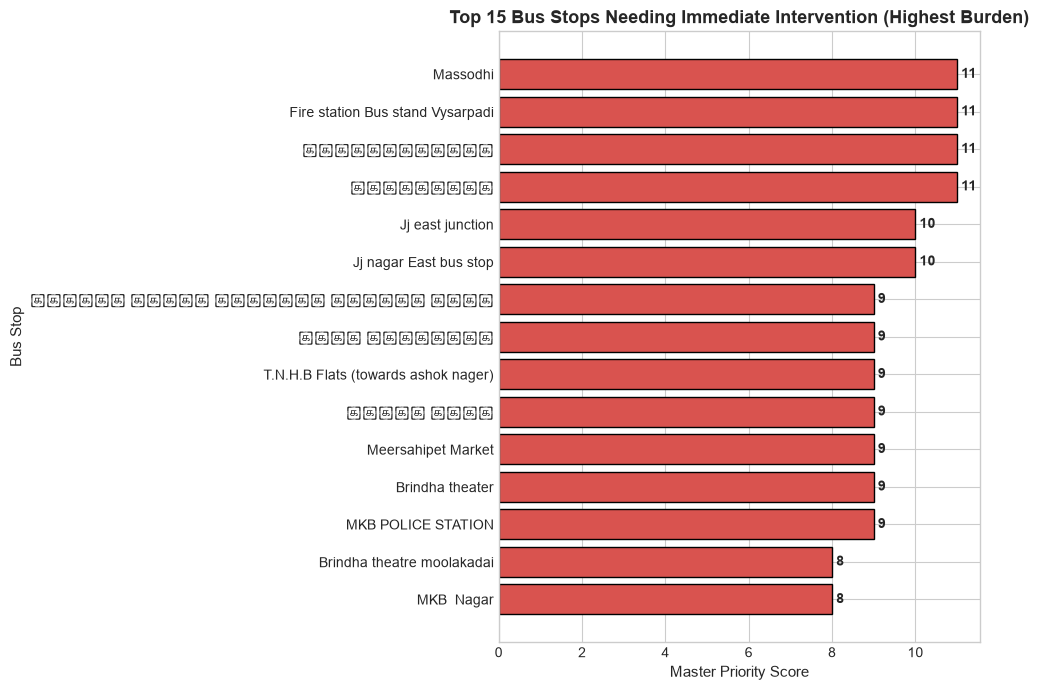

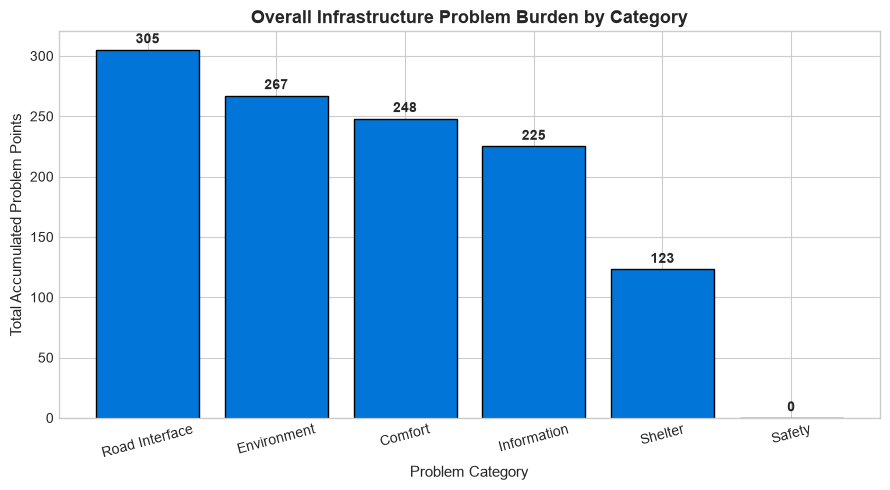

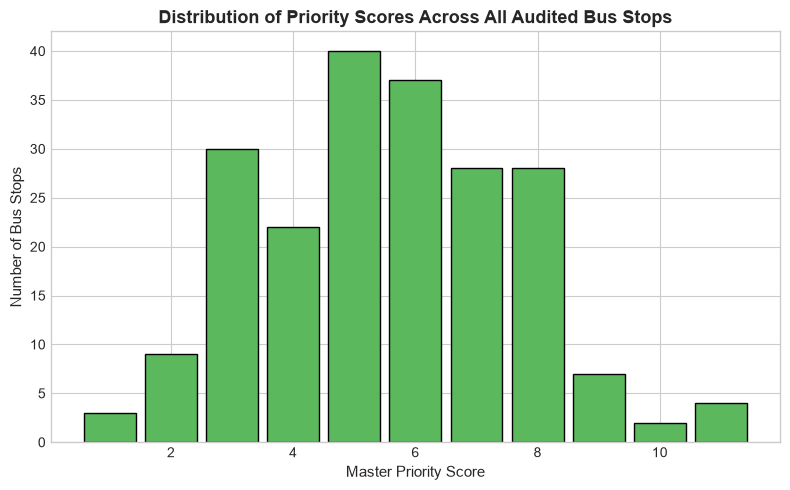

HIGH-PRIORITY BUS STOPS (TOP 25%)
Priority cutoff threshold (75th Percentile): 7.0
Total High-Priority Stops: 69

[SUCCESS] Saved 'master_priority_ranking_all_stops.csv' and 'high_priority_interventions_top25.csv'.


In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set global plot style for clean presentation
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

# ------------------------------------------------------------
# 1. MASTER PRIORITY SCORE
# ------------------------------------------------------------
score_columns = [
    "shelter_problem_score",
    "safety_problem_score",
    "road_interface_score",
    "environment_risk_score",
    "comfort_problem_score",
    "information_problem_count"
]

# Safely convert existing scores to numeric
for col in score_columns:
    bus_stop[col] = pd.to_numeric(bus_stop[col], errors="coerce").fillna(0)

bus_stop["master_priority_score"] = bus_stop[score_columns].sum(axis=1)

# ------------------------------------------------------------
# 2. RANK ALL 210 BUS STOPS
# ------------------------------------------------------------
bus_stop["priority_rank"] = (
    bus_stop["master_priority_score"]
    .rank(method="min", ascending=False)
    .astype(int)
)

priority_table = bus_stop[
    [
        stop_name_col,
        "master_priority_score",
        "priority_rank",
        "shelter_problem_score",
        "safety_problem_score",
        "road_interface_score",
        "environment_risk_score",
        "comfort_problem_score",
        "information_problem_count"
    ]
].copy()

priority_table = priority_table.rename(columns={
    stop_name_col: "Bus Stop",
    "master_priority_score": "Priority Score",
    "priority_rank": "Priority Rank",
    "shelter_problem_score": "Shelter",
    "safety_problem_score": "Safety",
    "road_interface_score": "Road Interface",
    "environment_risk_score": "Environment",
    "comfort_problem_score": "Comfort",
    "information_problem_count": "Information"
}).sort_values("Priority Score", ascending=False)

print("=" * 80)
print("MASTER BUS STOP PRIORITY RANKING")
print("=" * 80)
print("Total audited stops:", len(bus_stop))
print("Highest priority score:", bus_stop["master_priority_score"].max())
print("Lowest priority score:", bus_stop["master_priority_score"].min())
print("\nTop 20 Priority Stops:")
print(priority_table.head(20).to_string(index=False))


# ============================================================
# 3. FINAL CHART 1 — TOP 15 PRIORITY STOPS
# ============================================================
top15 = priority_table.head(15).copy().sort_values("Priority Score", ascending=True)

plt.figure(figsize=(10, 7))
bars = plt.barh(top15["Bus Stop"].astype(str), top15["Priority Score"], color="#d9534f", edgecolor="black")

# Add data labels to bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, f"{width:g}", ha="left", va="center", fontweight="bold")

plt.xlabel("Master Priority Score", fontsize=11)
plt.ylabel("Bus Stop", fontsize=11)
plt.title("Top 15 Bus Stops Needing Immediate Intervention (Highest Burden)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


# ============================================================
# 4. FINAL CHART 2 — PROBLEM BURDEN BY CATEGORY
# ============================================================
category_totals = pd.Series({
    "Shelter": bus_stop["shelter_problem_score"].sum(),
    "Safety": bus_stop["safety_problem_score"].sum(),
    "Road Interface": bus_stop["road_interface_score"].sum(),
    "Environment": bus_stop["environment_risk_score"].sum(),
    "Comfort": bus_stop["comfort_problem_score"].sum(),
    "Information": bus_stop["information_problem_count"].sum()
}).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
cat_bars = plt.bar(category_totals.index, category_totals.values, color="#0275d8", edgecolor="black")

# Add data labels
for bar in cat_bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (max(category_totals.values)*0.01), f"{int(height)}", ha="center", va="bottom", fontweight="bold")

plt.xlabel("Problem Category", fontsize=11)
plt.ylabel("Total Accumulated Problem Points", fontsize=11)
plt.title("Overall Infrastructure Problem Burden by Category", fontsize=13, fontweight="bold")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


# ============================================================
# 5. FINAL CHART 3 — PRIORITY SCORE DISTRIBUTION
# ============================================================
min_score = int(bus_stop["master_priority_score"].min())
max_score = int(bus_stop["master_priority_score"].max())

plt.figure(figsize=(8, 5))
plt.hist(
    bus_stop["master_priority_score"],
    bins=np.arange(min_score - 0.5, max_score + 1.5, 1),
    color="#5cb85c",
    edgecolor="black",
    rwidth=0.85
)

plt.xlabel("Master Priority Score", fontsize=11)
plt.ylabel("Number of Bus Stops", fontsize=11)
plt.title("Distribution of Priority Scores Across All Audited Bus Stops", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


# ============================================================
# 6. HIGH-PRIORITY STOPS (TOP 25%) & EXPORTS
# ============================================================
priority_cutoff = bus_stop["master_priority_score"].quantile(0.75)
high_priority = bus_stop[bus_stop["master_priority_score"] >= priority_cutoff].copy()

print("=" * 80)
print("HIGH-PRIORITY BUS STOPS (TOP 25%)")
print("=" * 80)
print(f"Priority cutoff threshold (75th Percentile): {round(priority_cutoff, 1)}")
print(f"Total High-Priority Stops: {len(high_priority)}")

# Export results for GIS/Reporting
priority_table.to_csv("master_priority_ranking_all_stops.csv", index=False)
high_priority.to_csv("high_priority_interventions_top25.csv", index=False)
print("\n[SUCCESS] Saved 'master_priority_ranking_all_stops.csv' and 'high_priority_interventions_top25.csv'.")